In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import numpy as np

In [2]:
from IPython.display import display, clear_output

In [3]:
import glob

In [4]:
from skbio.stats.composition import clr

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
import statsmodels.formula.api as smf

In [7]:
from collections import Counter

In [8]:
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import multipletests
import warnings

warnings.filterwarnings("ignore")  # MixedLM emits convergence warnings; inspect manually if needed

# Outline

Linear regressions to demonstrate relationships between taxon abundances / pathways and chemical factors

## Load chemistry data

In [9]:
md = pd.read_csv('/data/mhoffert/fiererlab/beer/project_data_and_tutorials/data/2022_10_12_WildBeer_metadata.tsv', sep='\t')
sf1_plotdf = md.copy(deep=True)

In [10]:
sf1_plotdf['Alcohol (% v/v)'] = sf1_plotdf['Alcohol (% v/v)'].replace('---', np.nan)
chem_plotdf = sf1_plotdf.set_index('Sample ID')[['pH', 'Density', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose', 'Alcohol (% v/v)']].stack().reset_index().rename(columns={'level_1':'measurement', 0:'value'})
chem_plotdf['timepoint (weeks)'] = chem_plotdf['Sample ID'].apply(lambda x: '0' if 'C' in x else x.split('-')[-1])
chem_plotdf['hops'] = chem_plotdf['Sample ID'].apply(lambda x: x[0])
chem_plotdf['exposure'] = chem_plotdf['Sample ID'].apply(lambda x: x[1] if not 'C' in x else 'C')
chem_plotdf['value'] = chem_plotdf['value'].astype(float)

In [11]:
chem_plotdf['treatment'] = chem_plotdf.apply(lambda row: f'{row["hops"]}{row["exposure"]}', axis=1)
chem_plotdf['replicate'] = chem_plotdf['Sample ID'].apply(lambda x: x.split('-')[0][-1])

In [12]:
chem_plotdf.head()

,Sample ID,measurement,value,timepoint (weeks),hops,exposure,treatment,replicate
0,HC1,pH,5.29,0,H,C,HC,1
1,HC1,Density,10.00,0,H,C,HC,1
2,HC1,Glucose,5.00,0,H,C,HC,1
3,HC1,Sucrose,6.50,0,H,C,HC,1
4,HC1,Maltose,49.70,0,H,C,HC,1


In [13]:
md.columns

Index(['Unnamed: 0', 'Sample Description', 'Sample Name', 'Sample ID',
       'timepoint', 'Filter replicate', 'pH', 'Density', 'Scent notes',
       'Notes', 'Hops', 'Location', 'treatment', 'Fructose', 'Glucose',
       'Sucrose', 'Maltose', 'Maltotriose', 'Method', 'Density Temperature',
       'Alcohol (% v/v)', 'Alcohol (% w/w)', 'Specific Gravity',
       'Ea (app. extract) (% w/w)', 'Er (real extract) (% w/w)',
       'p (original extract) (% w/w)', 'Concentration Sugar',
       'RDF (real deg. of ferm.)', 'ADF (% w/w)', 'Calories (kcal/12oz)'],
      dtype='object')

## Scale chemistry data

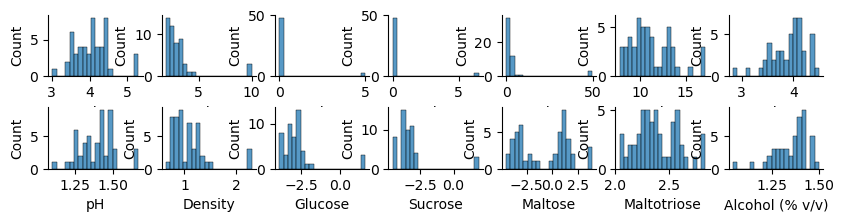

In [14]:
fig = plt.figure(figsize=(10, 2))
for i, m in enumerate(chem_plotdf['measurement'].unique()):
    subset = chem_plotdf[chem_plotdf.measurement.eq(m)]
    ax = fig.add_subplot(2, len(chem_plotdf['measurement'].unique()), i+1)
    sns.histplot(subset['value'], bins=20)
    sns.despine()
    ax = fig.add_subplot(2, len(chem_plotdf['measurement'].unique()), 
                         len(chem_plotdf['measurement'].unique())+i+1)
    sns.histplot(subset['value'].apply(np.log), bins=20)
    ax.set_xlabel(m)
    sns.despine()
fig.subplots_adjust(hspace=0.5)

In [15]:
chem_plotdf.head()

,Sample ID,measurement,value,timepoint (weeks),hops,exposure,treatment,replicate
0,HC1,pH,5.29,0,H,C,HC,1
1,HC1,Density,10.00,0,H,C,HC,1
2,HC1,Glucose,5.00,0,H,C,HC,1
3,HC1,Sucrose,6.50,0,H,C,HC,1
4,HC1,Maltose,49.70,0,H,C,HC,1


In [16]:
chem_wide = chem_plotdf.set_index(['Sample ID', 'measurement'])['value'].unstack().fillna(0)
chem_wide.head()

measurement,Alcohol (% v/v),Density,Glucose,Maltose,Maltotriose,Sucrose,pH
Sample ID,,,,,,,
HC1,0.00,10.0,5.000000,49.700000,17.200000,6.500000,5.29
HI1-1,3.60,3.4,0.062266,4.247591,11.095327,0.021214,4.48
HI1-3,4.18,2.2,0.050806,0.150945,8.695511,0.030649,3.75
HI2-1,3.66,3.4,0.072644,3.371268,13.398131,0.031821,4.45
HI2-3,4.14,2.3,0.030484,0.021564,10.783995,0.030649,4.11


In [17]:
# scale chemical measurements
scaler = StandardScaler()
chem_wide_scaled = pd.DataFrame(data=scaler.fit_transform(chem_wide),
                                index=chem_wide.index,
                                columns=chem_wide.columns)
chem_wide_scaled.head(2)

measurement,Alcohol (% v/v),Density,Glucose,Maltose,Maltotriose,Sucrose,pH
Sample ID,,,,,,,
HC1,-3.276420,3.778085,3.998972,3.945555,2.545360,3.999850,2.691181
HI1-1,0.000714,0.098388,-0.242032,-0.007895,-0.039263,-0.255405,0.909567


In [18]:
# add additional experiment columns back
chem_wide_scaled['timepoint'] = chem_wide_scaled.index.to_series().apply(lambda x: '0' if 'C' in x else x.split('-')[-1])
chem_wide_scaled['hops'] = chem_wide_scaled.index.to_series().apply(lambda x: 1 if x[0] == 'H' else 0)
exposure_map = {'C':0, 'I':1, 'O':2}
chem_wide_scaled['exposure'] = chem_wide_scaled.index.to_series().apply(lambda x: exposure_map[x[1]])
chem_wide_scaled['treatment'] = chem_wide_scaled.index.to_series().apply(lambda x: x[:2])
chem_wide_scaled['replicate'] = chem_wide_scaled.index.to_series().apply(lambda x: x.split('-')[0][-1])
chem_wide_scaled.head(2)

measurement,Alcohol (% v/v),Density,Glucose,Maltose,Maltotriose,Sucrose,pH,timepoint,hops,exposure,treatment,replicate
Sample ID,,,,,,,,,,,,
HC1,-3.276420,3.778085,3.998972,3.945555,2.545360,3.999850,2.691181,0,1,0,HC,1
HI1-1,0.000714,0.098388,-0.242032,-0.007895,-0.039263,-0.255405,0.909567,1,1,1,HI,1


## Load and process RPKM data

In [19]:
# load pre-computed MAG coverage table
table = pd.read_csv('/data/mhoffert/fiererlab/beer/data/20230605_MAG_coverage_table.tsv', sep='\t', index_col=0)
table = table.drop(['CommStd_S36',
           'ExtB1_S43',
           'NTC_S54'], axis=0)

# set control RPKMs to 1 in controls for purposes of regression
table[table.index.str.contains('C')] = 0

In [20]:
# filter prevalence of species at 1 RPKM
filtered_taxa =  table.columns[(table > 1).sum() > 10]

clr_table = pd.DataFrame(clr(table.loc[:, filtered_taxa] + 1e-1),
                         index=table.index,
                         columns=filtered_taxa)

In [21]:
# clean up MG names
clr_table = clr_table.rename(index=dict((i, i.split('_')[0]) for i in clr_table.index))

In [22]:
clr_table.head()

,S_cerevisiae,g__Enterobacter,s__Lacticaseibacillus paracasei,s__Lentilactobacillus parabuchneri,s__Pantoea agglomerans,s__Pseudescherichia vulneris,s__Schleiferilactobacillus harbinensis
sample_name,,,,,,,
HC1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HI1-1,3.001449,4.788092,-3.095869,-3.154814,-0.740365,1.924735,-2.723227
HI1-3,0.740326,2.243432,1.246980,-1.455691,-3.656622,-0.877324,1.758899
HI2-1,2.978401,4.434235,-2.406576,-3.292985,-0.930043,1.688273,-2.471305
HI2-3,0.856918,2.297469,1.229723,-1.421853,-3.056716,-0.531997,0.626456


## Additional data

In [23]:
# color_map = dict(zip(order, ['green',  'skyblue', 'blue', 'darkblue', 'red', 'gray', 'lightcoral', 'dodgerblue']))
species_color_map = {
     'S_cerevisiae': 'gray',
     'g__Enterobacter': 'lightcoral',
     's__Pseudescherichia vulneris': 'firebrick',
     's__Pantoea agglomerans':'red',
 's__Schleiferilactobacillus harbinensis': 'skyblue',
 's__Lacticaseibacillus paracasei':'dodgerblue',
    's__Lentilactobacillus parabuchneri': 'blue',
 's__Levilactobacillus brevis': 'darkblue',
 


's__Gluconobacter_A japonicus': 'green',}

In [24]:
# # get MAG name mapping
mag_gtdbtk = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gtdbtk.bac120.summary.tsv', sep='\t')
mag2species = mag_gtdbtk.set_index('user_genome')['classification'].apply(lambda x: x.split(';')[-1])
mag2species.loc['UO5-1_MAG_02'] = 'g__Enterobacter'

## Load pathway data

In [28]:
pathway_files = glob.glob('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gapseq_test/*Pathways.tbl')

In [29]:
all_pathway_data = pd.concat([pd.read_csv(p, sep='\t', skiprows=3).assign(mag_id=p.split('/')[-1].split('_protein')[0]) for p in pathway_files])

In [30]:
pway_id2name = all_pathway_data.groupby('ID').first()['Name']
pway_name2id = all_pathway_data.groupby('Name').first()['ID']

In [31]:
with open('./../data/functional_analysis/pathway_ids.txt', 'w') as handle:
    handle.write('\n'.join(list(all_pathway_data[all_pathway_data.Completeness > 75]['Name'].unique())))

In [32]:
reaction_files = glob.glob('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gapseq_test/*Reactions.tbl')

In [33]:
all_reaction_data = pd.concat([pd.read_csv(p, sep='\t', skiprows=3).assign(mag_id=p.split('/')[-1].split('_protein')[0]) for p in reaction_files])

all_reaction_data['gene_id'] = all_reaction_data['stitle'].fillna('None').apply(lambda x: x.split(' # ')[0])

all_reaction_data.head(2)

,rxn,name,ec,bihit,qseqid,pident,evalue,bitscore,qcovs,stitle,...,send,pathway,status,pathway.status,dbhit,complex,exception,complex.status,mag_id,gene_id
0,DHLAXANAU-RXN,"1,2-dichloroethane dehalogenase",3.8.1.5,NaN,UniRef90_Q98C03,25.623,1.950000e-08,50.4,88.0,NODE_29_length_135917_cov_288.110885_86 # 9208...,...,270.0,|12DICHLORETHDEG-PWY|,bad_blast,NaN,rxn03596 rxn03668 rxn03669 rxn03670 rxn03671 r...,NaN,0,NaN,HI4-3_MAG_04,NODE_29_length_135917_cov_288.110885_86
1,MOXXANAU-RXN,2-chloroethanol dehydrogenase,1.1.2.7,NaN,UniRef90_P12293,31.350,9.290000e-76,253.0,94.0,NODE_11_length_292332_cov_345.902770_93 # 9190...,...,630.0,|12DICHLORETHDEG-PWY|,good_blast,NaN,rxn00847 rxn01796 rxn12745 rxn14207 rxn15989 r...,Subunit 1,0,NaN,HI4-3_MAG_04,NODE_11_length_292332_cov_345.902770_93


# Pathway comparison

In [34]:
# jesus christ
pathway_groups = {
 
    "central_carbon_sugar_catabolism": [
        "glycolysis I (from glucose 6-phosphate)",
        "glycolysis II (from fructose 6-phosphate)",
        "glycolysis III (from glucose)",
        "glycolysis IV",
        "gluconeogenesis I",
        "pentose phosphate pathway (oxidative branch) I",
        "Entner-Doudoroff shunt",
        "Bifidobacterium shunt",
        "TCA cycle I (prokaryotic)",
        "TCA cycle VII (acetate-producers)",
        "sucrose degradation II (sucrose synthase)",
        "sucrose degradation III (sucrose invertase)",
        "sucrose degradation IV (sucrose phosphorylase)",
        "D-mannose degradation II",
        "D-galactose degradation I (Leloir pathway)",
        "melibiose degradation",
        "lactose degradation III",
        "trehalose degradation I (low osmolarity)",
        "trehalose degradation II (cytosolic)",
        "trehalose degradation VI (periplasmic)",
        "glycogen degradation I",
        
        "D-gluconate degradation",

    ],
 
    "fermentation_end_products": [
                "heterolactic fermentation",
        "pyruvate fermentation to (S)-lactate",
        "pyruvate fermentation to acetate II",
        "pyruvate fermentation to acetate VIII",
        "acetate and ATP formation from acetyl-CoA I",
        "mixed acid fermentation",
        "pyruvate fermentation to (S)-acetoin",
        "pyruvate fermentation to (R)-acetoin II",
        "(S,S)-butanediol biosynthesis",
        "meso-butanediol biosynthesis I",
        "pyruvate fermentation to ethanol I",
        "pyruvate fermentation to ethanol II",
        "acetate conversion to acetyl-CoA",
        "ethanol degradation I",
        "ethanol degradation II",
                "ethanol degradation III",
        "ethanol degradation IV",
    ],
 
    "acid_resistance_amine_systems": [
        "arginine dependent acid resistance",
        "L-arginine degradation II (AST pathway)",
        "L-arginine degradation III (arginine decarboxylase/agmatinase pathway)",
        "putrescine biosynthesis I",
        "cadaverine biosynthesis",
    ],
 
    "osmotic_oxidative_stress_protection": [
        "glycine betaine biosynthesis I (Gram-negative bacteria)",
        "glycine betaine biosynthesis II (Gram-positive bacteria)",
        "trehalose biosynthesis I",
        "trehalose biosynthesis II",
        "superoxide radicals degradation",
        "NADH repair (prokaryotes)",
    ],
 
    "cell_envelope_taxonomic_markers": [
        "cellulose biosynthesis",
        "lipid IVA biosynthesis (E. coli)",
        "(Kdo)2-lipid A biosynthesis I (E. coli)",
        "Kdo transfer to lipid IVA I (E. coli)",
        "peptidoglycan cross-bridge biosynthesis II (E. faecium)",
        "UDP-N-acetylmuramoyl-pentapeptide biosynthesis I (meso-diaminopimelate containing)",
        "UDP-N-acetylmuramoyl-pentapeptide biosynthesis II (lysine-containing)",
    ],
}

In [35]:
pathway_names_map = {
    "glycolysis I (from glucose 6-phosphate)": "Glycolysis I (G6P)",
    "glycolysis II (from fructose 6-phosphate)": "Glycolysis II (F6P)",
    "glycolysis III (from glucose)": "Glycolysis III (Glucose)",
    "glycolysis IV": "Glycolysis IV",
    "pentose phosphate pathway (oxidative branch) I": "PPP I (Oxidative)",
    "Entner-Doudoroff shunt": "Entner–Doudoroff Shunt",
    "Bifidobacterium shunt": "Bifidobacterium Shunt",
    "TCA cycle I (prokaryotic)": "TCA Cycle I (Prokaryotic)",
    "TCA cycle VII (acetate-producers)": "TCA Cycle VII (Acetate)",
    "sucrose degradation II (sucrose synthase)": "Sucrose Deg. II (Synthase)",
    "sucrose degradation III (sucrose invertase)": "Sucrose Deg. III (Invertase)",
    "sucrose degradation IV (sucrose phosphorylase)": "Sucrose Deg. IV (Phosphorylase)",
    "D-mannose degradation II": "D-Mannose Deg. II",
    "D-galactose degradation I (Leloir pathway)": "D-Galactose Deg. I (Leloir)",
    "melibiose degradation": "Melibiose Deg.",
    "lactose degradation III": "Lactose Deg. III",
    "trehalose degradation I (low osmolarity)": "Trehalose Deg. I (Low Osm.)",
    "trehalose degradation II (cytosolic)": "Trehalose Deg. II (Cytosolic)",
    "trehalose degradation VI (periplasmic)": "Trehalose Deg. VI (Periplasmic)",
    "glycogen degradation I": "Glycogen Deg. I",
    "gluconeogenesis I": "Gluconeogenesis I",
    "D-gluconate degradation": "D-Gluconate Deg.",
    "pyruvate fermentation to (S)-lactate": "Pyr. Ferm. to (S)-Lactate",
    "heterolactic fermentation": "Heterolactic Ferm.",
    "pyruvate fermentation to acetate II": "Pyr. Ferm. to Acetate II",
    "pyruvate fermentation to acetate VIII": "Pyr. Ferm. to Acetate VIII",
    "acetate and ATP formation from acetyl-CoA I": "Acetate/ATP Synth. from Acetyl-CoA I",
    "mixed acid fermentation": "Mixed Acid Ferm.",
    "pyruvate fermentation to (S)-acetoin": "Pyr. Ferm. to (S)-Acetoin",
    "pyruvate fermentation to (R)-acetoin II": "Pyr. Ferm. to (R)-Acetoin II",
    "(S,S)-butanediol biosynthesis": "(S,S)-Butanediol Synth.",
    "meso-butanediol biosynthesis I": "meso-Butanediol Synth. I",
    "pyruvate fermentation to ethanol I": "Pyr. Ferm. to Ethanol I",
    "pyruvate fermentation to ethanol II": "Pyr. Ferm. to Ethanol II",
    "acetate conversion to acetyl-CoA": "Acetate to Acetyl-CoA",
    "ethanol degradation I": "Ethanol Deg. I",
    "ethanol degradation II": "Ethanol Deg. II",
    "ethanol degradation III": "Ethanol Deg. III",
    "ethanol degradation IV": "Ethanol Deg. IV",
    "arginine dependent acid resistance": "Arg-Dependent Acid Resistance",
    "L-arginine degradation II (AST pathway)": "L-Arginine Deg. II (AST)",
    "L-arginine degradation III (arginine decarboxylase/agmatinase pathway)": "L-Arginine Deg. III (ADC/Agmatinase)",
    "putrescine biosynthesis I": "Putrescine Synth. I",
    "cadaverine biosynthesis": "Cadaverine Synth.",
    "glycine betaine biosynthesis I (Gram-negative bacteria)": "Glycine Betaine Synth. I (Gram⁻)",
    "glycine betaine biosynthesis II (Gram-positive bacteria)": "Glycine Betaine Synth. II (Gram⁺)",
    "trehalose biosynthesis I": "Trehalose Synth. I",
    "trehalose biosynthesis II": "Trehalose Synth. II",
    "superoxide radicals degradation": "Superoxide Radical Deg.",
    "NADH repair (prokaryotes)": "NADH Repair (Prokaryotes)",
    "cellulose biosynthesis": "Cellulose Synth.",
    "lipid IVA biosynthesis (E. coli)": "Lipid IVA Synth. (E. coli)",
    "(Kdo)2-lipid A biosynthesis I (E. coli)": "(Kdo)₂-Lipid A Synth. I (E. coli)",
    "Kdo transfer to lipid IVA I (E. coli)": "Kdo Transfer to Lipid IVA I (E. coli)",
    "peptidoglycan cross-bridge biosynthesis II (E. faecium)": "Peptidoglycan Cross-Bridge Synth. II (E. faecium)",
    "UDP-N-acetylmuramoyl-pentapeptide biosynthesis I (meso-diaminopimelate containing)": "UDP-MurNAc-Pentapeptide Synth. I (m-DAP)",
    "UDP-N-acetylmuramoyl-pentapeptide biosynthesis II (lysine-containing)": "UDP-MurNAc-Pentapeptide Synth. II (Lysine)",
}

Key:

Synth.: Biosynthesis
Deg.: Degradation
Ferm.: Fermentation
PPP: Pentose Phosphate Pathway
TCA: Tricarboxylic Acid Cycle
G6P / F6P: Glucose 6-phosphate / Fructose 6-phosphate
UDP-MurNAc: UDP-N-acetylmuramoyl
m-DAP: meso-diaminopimelate

In [36]:
pway_heatmap = all_pathway_data.groupby(['ID', 'mag_id']).mean()['Completeness'].unstack().rename(index=pway_id2name, columns=mag2species).T.drop(['indole-3-acetate inactivation VIII', 'methylsalicylate degradation'], axis=1)

central_carbon_sugar_catabolism
fermentation_end_products
acid_resistance_amine_systems
osmotic_oxidative_stress_protection
cell_envelope_taxonomic_markers


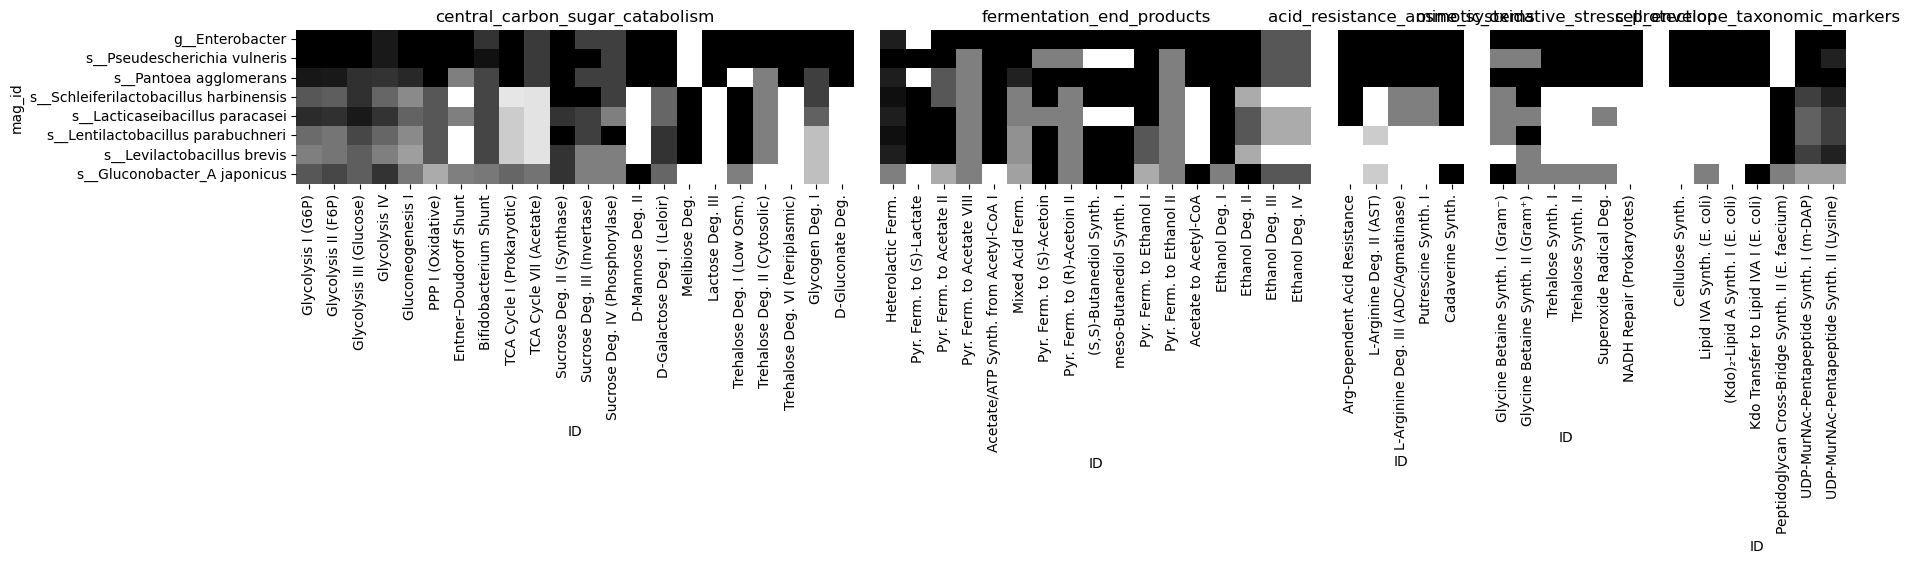

In [37]:
fig = plt.figure(figsize=(20, 2))
gs = fig.add_gridspec(1, 5, width_ratios=[int(len(g)) for k, g in pathway_groups.items()])
i = 0
axes = []
for group in list(pathway_groups.keys()):
    if i == 0:
        ax = fig.add_subplot(gs[i])
        axes.append(ax)
    else:
        ax = fig.add_subplot(gs[i])
        axes.append(ax)
    print(group)
    
    # plotdf, _, _ = clustermap_reorder(pway_heatmap.reindex(columns=list(set(pathway_groups[group]))).dropna())
    plotdf = pway_heatmap.reindex(columns=pathway_groups[group])
    
    
#     for species_group, cmap in zip(['E', 'L', 'A'], ['Reds', 'Blues', 'Greens']):
#         # make a heatmap dataframe with species in group masked
#         colorby_group_df = plotdf.reindex(index=list(species_color_map.keys())).dropna().mask(~colorby_group_df.index.to_series().map(species2group).eq(species_group))
#         sns.heatmap(colorby_group_df, cmap=cmap, cbar=False, ax=ax)

    sns.heatmap(plotdf.reindex(index=species_color_map.keys()).dropna(), cmap='gray_r', xticklabels=True, ax=ax, cbar=False)
    
    yticklabels = list(species_color_map.keys())
    xticklabels = ax.set_xticklabels([pathway_names_map[c] for c in plotdf.columns])
    if i > 0:
        ax.tick_params(labelleft=False, left=False)
        ax.set_ylabel('')
    ax.set_title(group)
    i += 1
    
fig.subplots_adjust(wspace=0.09)
plt.savefig('./../data/figures/metabolism_heatmap.svg', bbox_inches='tight')
plt.show()

In [136]:
pway_heatmap.loc[:, 'D-galactose degradation I (Leloir pathway)']

mag_id
s__Gluconobacter_A japonicus               60.0
s__Lacticaseibacillus paracasei            60.0
s__Schleiferilactobacillus harbinensis     60.0
s__Pantoea agglomerans                    100.0
s__Levilactobacillus brevis                80.0
s__Pseudescherichia vulneris              100.0
g__Enterobacter                           100.0
s__Lentilactobacillus parabuchneri         80.0
Name: D-galactose degradation I (Leloir pathway), dtype: float64

<Axes: xlabel='ID', ylabel='mag_id'>

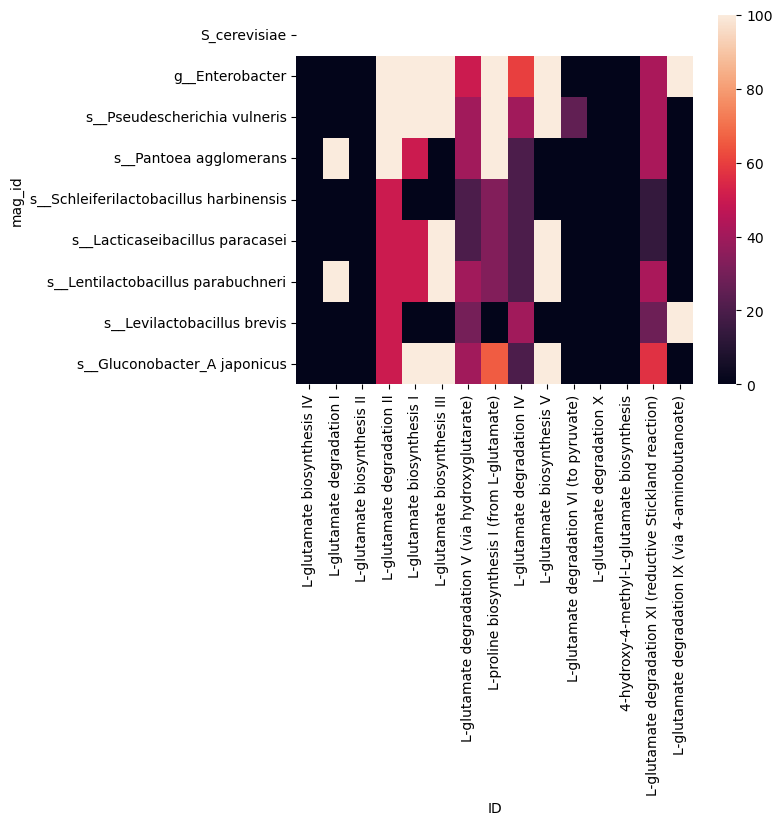

In [143]:
sns.heatmap(pway_heatmap.loc[:, pway_heatmap.columns.str.contains('L-glutamate')].reindex(index=list(species_color_map.keys())))

In [147]:
ATPases = pd.read_csv('/data/mhoffert/fiererlab/beer/data/functional_analysis/SearchResultsF1F0 .tsv', sep='\t')['Accession'].unique()

In [158]:
pway_heatmap.to_csv('/data/mhoffert/fiererlab/beer/data/functional_analysis/pathway_heatmap.tsv', sep='\t')

In [ ]:
interpro_data

In [153]:
temp = interpro_data[interpro_data['interpro_accession'].isin(ATPases)].groupby(['genome', 'interpro_accession']).count()['protein_accession'].unstack()

<Axes: xlabel='interpro_accession', ylabel='genome'>

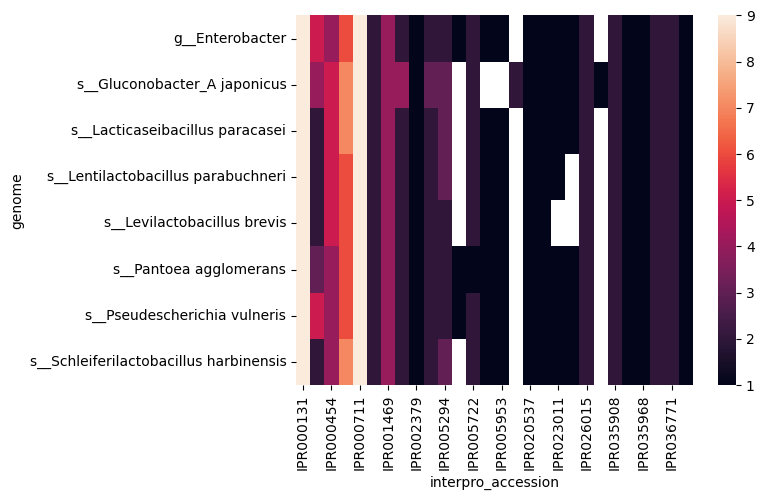

In [154]:
sns.heatmap(temp)

In [161]:
mag_gtdbtk['classification'].values

array(['d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Acetobacterales;f__Acetobacteraceae;g__Gluconobacter_A;s__Gluconobacter_A japonicus',
       'd__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lacticaseibacillus;s__Lacticaseibacillus paracasei',
       'd__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Schleiferilactobacillus;s__Schleiferilactobacillus harbinensis',
       'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Pantoea;s__Pantoea agglomerans',
       'd__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Levilactobacillus;s__Levilactobacillus brevis',
       'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Pseudescherichia;s__Pseudescherichia vulneris',
       'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Enterobacter;s__',
     

In [1736]:
species2group = { 'g__Enterobacter': 'E',
 's__Pantoea agglomerans': 'E',
 's__Pseudescherichia vulneris': 'E',
 's__Schleiferilactobacillus harbinensis': 'L',
 's__Lacticaseibacillus paracasei': 'L',
 's__Lentilactobacillus parabuchneri': 'L',
 's__Levilactobacillus brevis': 'L',
 's__Gluconobacter_A japonicus': 'A'}

In [157]:
(orthogroup_counts.sum(1) == 1).sum()

3585

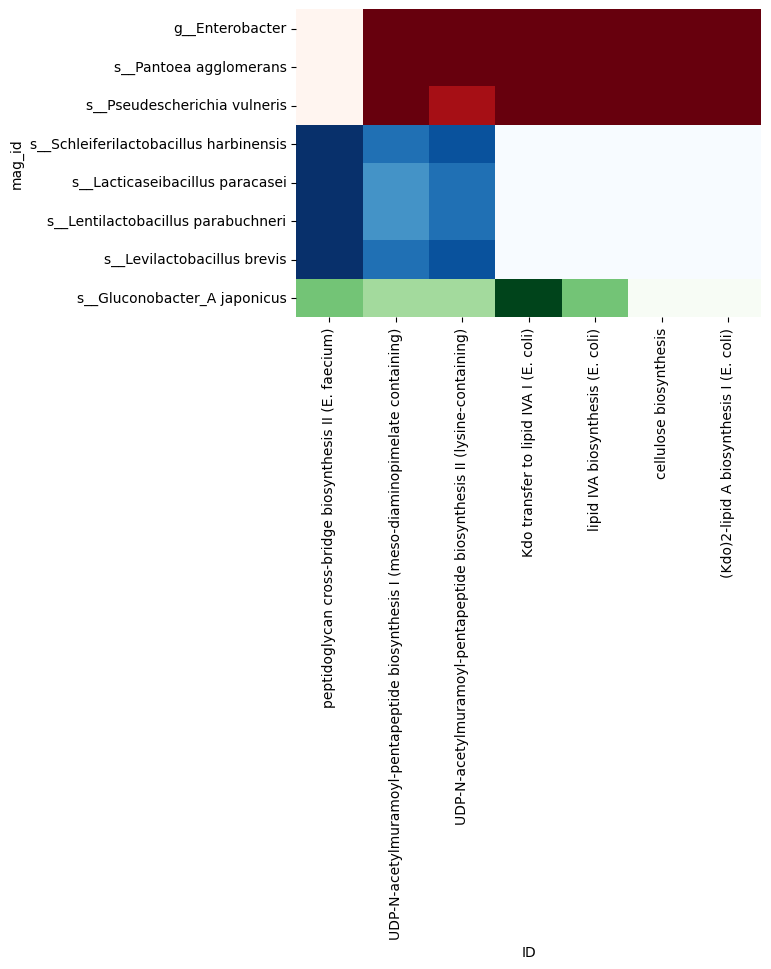

In [1747]:
fig, ax = plt.subplots(figsize=(6,4))



<Axes: xlabel='ID', ylabel='mag_id'>

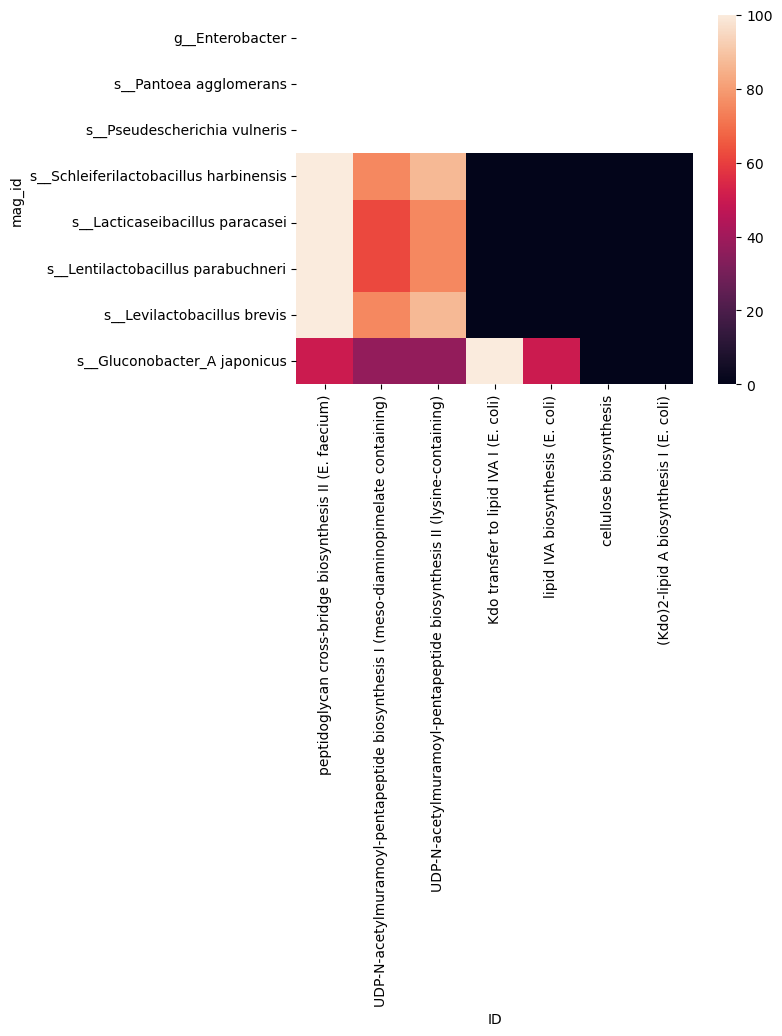

In [1691]:
plotdf.reindex(index=species_color_map.keys())

ID,peptidoglycan cross-bridge biosynthesis II (E. faecium),UDP-N-acetylmuramoyl-pentapeptide biosynthesis I (meso-diaminopimelate containing),UDP-N-acetylmuramoyl-pentapeptide biosynthesis II (lysine-containing),Kdo transfer to lipid IVA I (E. coli),lipid IVA biosynthesis (E. coli),cellulose biosynthesis,(Kdo)2-lipid A biosynthesis I (E. coli)
mag_id,,,,,,,
S_cerevisiae,NaN,NaN,NaN,NaN,NaN,NaN,NaN
g__Enterobacter,0.0,100.0,100.0,100.0,100.0,100.0,100.0
s__Pantoea agglomerans,0.0,100.0,100.0,100.0,100.0,100.0,100.0
s__Pseudescherichia vulneris,0.0,100.0,87.0,100.0,100.0,100.0,100.0
s__Schleiferilactobacillus harbinensis,100.0,75.0,87.0,0.0,0.0,0.0,0.0
s__Lacticaseibacillus paracasei,100.0,62.0,75.0,0.0,0.0,0.0,0.0
s__Lentilactobacillus parabuchneri,100.0,62.0,75.0,0.0,0.0,0.0,0.0
s__Levilactobacillus brevis,100.0,75.0,87.0,0.0,0.0,0.0,0.0
s__Gluconobacter_A japonicus,50.0,37.0,37.0,100.0,50.0,0.0,0.0


In [1519]:
plotdf

ID,pyruvate fermentation to (S)-lactate,pyruvate fermentation to (S)-acetoin,"(S,S)-butanediol biosynthesis",meso-butanediol biosynthesis I,pyruvate fermentation to acetate II,pyruvate fermentation to ethanol I,acetate and ATP formation from acetyl-CoA I,ethanol degradation I,acetate conversion to acetyl-CoA,TCA cycle I (prokaryotic),TCA cycle VII (acetate-producers),ethanol degradation II,mixed acid fermentation,pyruvate fermentation to (R)-acetoin II,pyruvate fermentation to acetate VIII,pyruvate fermentation to ethanol II
mag_id,,,,,,,,,,,,,,,,
s__Gluconobacter_A japonicus,0.0,100.0,100.0,100.0,33.0,33.0,0.0,50.0,100.0,60.0,55.0,100.0,37.0,50.0,50.0,50.0
s__Pantoea agglomerans,0.0,100.0,100.0,100.0,66.0,100.0,100.0,100.0,100.0,100.0,77.0,100.0,87.0,100.0,50.0,50.0
g__Enterobacter,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,77.0,100.0,100.0,100.0,100.0,100.0
s__Schleiferilactobacillus harbinensis,100.0,100.0,100.0,100.0,66.0,100.0,100.0,100.0,0.0,10.0,11.0,33.0,50.0,50.0,50.0,50.0
s__Levilactobacillus brevis,100.0,100.0,100.0,100.0,100.0,66.0,100.0,100.0,0.0,20.0,11.0,33.0,43.0,50.0,50.0,50.0
s__Lentilactobacillus parabuchneri,100.0,100.0,100.0,100.0,100.0,66.0,100.0,100.0,0.0,20.0,11.0,66.0,43.0,50.0,50.0,50.0
s__Lacticaseibacillus paracasei,100.0,50.0,0.0,0.0,100.0,100.0,100.0,100.0,0.0,20.0,11.0,66.0,50.0,50.0,50.0,50.0
s__Pseudescherichia vulneris,100.0,50.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,77.0,100.0,100.0,50.0,50.0,50.0


In [1513]:
pway_heatmap.loc[:, pway_heatmap.columns.str.contains('TCA')]

ID,TCA cycle IV (2-oxoglutarate decarboxylase),reductive TCA cycle I,incomplete reductive TCA cycle,reductive TCA cycle II,TCA cycle II (plants and fungi),partial TCA cycle (obligate autotrophs),TCA cycle V (2-oxoglutarate synthase),TCA cycle VII (acetate-producers),TCA cycle III (animals),TCA cycle VI (Helicobacter),TCA cycle I (prokaryotic)
mag_id,,,,,,,,,,,
s__Gluconobacter_A japonicus,66.0,25.0,14.0,33.0,66.0,62.0,44.0,55.0,70.0,44.0,60.0
s__Lacticaseibacillus paracasei,33.0,8.0,28.0,16.0,33.0,12.0,11.0,11.0,40.0,11.0,20.0
s__Schleiferilactobacillus harbinensis,33.0,8.0,14.0,16.0,22.0,12.0,11.0,11.0,30.0,11.0,10.0
s__Pantoea agglomerans,100.0,66.0,42.0,58.0,100.0,100.0,88.0,77.0,100.0,55.0,100.0
s__Levilactobacillus brevis,33.0,8.0,14.0,16.0,33.0,12.0,11.0,11.0,40.0,11.0,20.0
s__Pseudescherichia vulneris,100.0,75.0,57.0,66.0,100.0,100.0,88.0,77.0,100.0,66.0,100.0
g__Enterobacter,100.0,75.0,57.0,66.0,100.0,100.0,88.0,77.0,100.0,66.0,100.0
s__Lentilactobacillus parabuchneri,33.0,8.0,14.0,16.0,33.0,12.0,11.0,11.0,40.0,11.0,20.0


In [36]:
all_pathway_data

,ID,Name,Prediction,Completeness,VagueReactions,KeyReactions,KeyReactionsFound,ReactionsFound,mag_id
0,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation",False,25,0,1,0,ALDXANAU-RXN,HI4-3_MAG_04
1,|14DICHLORBENZDEG-PWY|,"1,4-dichlorobenzene degradation",False,14,0,2,0,MALEYLACETATE-REDUCTASE-RXN,HI4-3_MAG_04
2,|1CMET2-PWY|,folate transformations III (E. coli),False,77,0,0,0,DIHYDROFOLATEREDUCT-RXN 1.5.1.20-RXN HOMOCYSME...,HI4-3_MAG_04
3,|2AMINOBENZDEG-PWY|,anthranilate degradation III (anaerobic),False,0,1,0,0,NaN,HI4-3_MAG_04
4,|2ASDEG-PWY|,orthanilate degradation,False,0,2,0,0,NaN,HI4-3_MAG_04
...,...,...,...,...,...,...,...,...,...
2854,|UDPNACETYLGALSYN-PWY|,UDP-N-acetyl-D-glucosamine biosynthesis II,False,66,2,0,0,L-GLN-FRUCT-6-P-AMINOTRANS-RXN NAG1P-URIDYLTRA...,UO6-3_MAG_03
2855,|UDPNAGSYN-PWY|,UDP-N-acetyl-D-glucosamine biosynthesis I,True,100,0,0,0,NAG1P-URIDYLTRANS-RXN 2.3.1.157-RXN L-GLN-FRUC...,UO6-3_MAG_03
2856,|VALDEG-PWY|,L-valine degradation I,False,50,2,0,0,BRANCHED-CHAINAMINOTRANSFERVAL-RXN 1.2.1.25-RXN,UO6-3_MAG_03
2857,|VALSYN-PWY|,L-valine biosynthesis,False,50,0,0,0,BRANCHED-CHAINAMINOTRANSFERVAL-RXN ACETOLACTSY...,UO6-3_MAG_03


In [37]:
pathway_groups_mcid = {}
for key, item in pathway_groups.items():
    pathway_groups_mcid[key] = [pway_name2id.loc[i] for i in item]

In [38]:
# pathway_heatmap_data = all_pathway_data.pivot_table(index='Name', columns='mag_id', values='Completeness').fillna(0).rename(columns=mag2species)
# pathway_heatmap_data

In [39]:
pathway_groups_mcid

{'central_carbon_sugar_catabolism': ['|GLYCOLYSIS|',
  '|ANAGLYCOLYSIS-PWY|',
  '|PWY-5484|',
  '|PWY-1042|',
  '|OXIDATIVEPENT-PWY|',
  '|ENTNER-DOUDOROFF-PWY|',
  '|PWY-3801|',
  '|PWY-621|',
  '|PWY-5384|',
  '|PWY3O-1743|',
  '|PWY-6317|',
  '|PWY0-1301|',
  '|BGALACT-PWY|',
  '|TREDEGLOW-PWY|',
  '|PWY0-1182|',
  '|PWY0-1466|',
  '|GLYCOCAT-PWY|',
  '|GLUCONEO-PWY|',
  '|GLUCONSUPER-PWY|',
  '|P124-PWY|',
  '|P122-PWY|'],
 'fermentation_end_products': ['|PWY-5480|',
  '|PWY-5486|',
  '|PWY-5481|',
  '|PWY-5482|',
  '|PWY-5768|',
  '|PWY-6389|',
  '|PWY-5939|',
  '|FERMENTATION-PWY|',
  '|PWY0-1313|',
  '|PWY0-1312|',
  '|ETOH-ACETYLCOA-ANA-PWY|',
  '|PWY66-21|',
  '|PWY-6390|',
  '|PWY-6391|',
  '|TCA|',
  '|PWY-7254|'],
 'acid_resistance_amine_systems': ['|PWY0-1299|',
  '|AST-PWY|',
  '|PWY0-823|',
  '|PWY-40|',
  '|PWY0-1601|'],
 'osmotic_oxidative_stress_protection': ['|BETSYN-PWY|',
  '|PWY-3722|',
  '|TRESYN-PWY|',
  '|PWY-881|',
  '|DETOX1-PWY|',
  '|PWY-6938-1|'],
 'cell_e

## KEGG approach

In [170]:
import svgwrite
from Bio.KEGG import REST
from Bio.KEGG.KGML.KGML_parser import read as kgml_read
import os

In [41]:

SPECIES = [
    "Entero_1", "Entero_2", "Entero_3",
    "Lacto_1", "Lacto_2", "Lacto_3", "Lacto_4",
    "Aceto_1",
]

In [45]:



# ---------------------------------------------------------------------------
# Map each of your functional groups to real KEGG reference pathway maps.
# "ko" maps (KO-based, organism-agnostic) are the right choice here since
# your MAGs aren't in KEGG's organism list -- ko maps show the full generic
# enzyme complement for a pathway, and you just mark which of your species
# have a hit for each node's KOs/ECs (from your gapseq/InterProScan calls).
# ---------------------------------------------------------------------------
GROUP_TO_KEGG_MAPS = {
    "central_carbon_sugar_catabolism": ["ko00010", "ko00030", "ko00051", "ko00052", "ko00500"],
    "fermentation_end_products": ["ko00620", "ko00650", "ko00020"],
    "cell_envelope_taxonomic_markers": ["ko00540", "ko00550", "ko00520"],
    # acid_resistance / osmotic-oxidative-stress groups are not coherent
    # KEGG "map" pathways (they're scattered single reactions/regulons) --
    # keep those as the Graphviz marker-grid layout from before.
}


def fetch_kgml(map_id):
    """Download and parse a KEGG pathway's KGML (needs internet access)."""
    handle = REST.kegg_get(map_id, "kgml")
    return kgml_read(handle)


def render(pathway, outpath, r=3):
    (xmin, ymin), (xmax, ymax) = pathway.bounds
    pad = 30
    w, h = (xmax - xmin) + 2 * pad, (ymax - ymin) + 2 * pad + 20
 
    dwg = svgwrite.Drawing(outpath, size=(w, h))
    dwg.add(dwg.text(pathway.title or pathway.name, insert=(pad, 15),
                      font_size=12, font_family="sans-serif"))
 
    def pt(x, y):
        return (x - xmin + pad, y - ymin + pad + 20)
 
    centers = {}
    for entry in pathway.entries.values():
        if not entry.graphics or entry.graphics[0].x is None:
            continue
        g = entry.graphics[0]
        cx, cy = pt(g.x, g.y)
        centers[entry.id] = (cx, cy)
        dwg.add(dwg.circle(center=(cx, cy), r=r, fill="black"))
        label = (g.name or entry.name).split(",")[0]
        dwg.add(dwg.text(label, insert=(cx + r + 2, cy + 3),
                          font_size=6, font_family="sans-serif"))
 
    def edge(id1, id2):
        if id1 in centers and id2 in centers:
            dwg.add(dwg.line(start=centers[id1], end=centers[id2],
                              stroke="black", stroke_width=0.5))
 
    for rel in pathway.relations:
        edge(rel.entry1.id, rel.entry2.id)
 
    for rxn in pathway.reactions:
        for sub in rxn.substrates:
            for prod in rxn.products:
                edge(sub.id, prod.id)
 
    dwg.save()




In [136]:
def fetch_kgml(map_id):
    """Download and parse a KEGG pathway's KGML (needs internet access)."""
    handle = REST.kegg_get(map_id, "kgml")
    return kgml_read(handle)

In [47]:
# # def main(outdir="kegg_pathway_svgs"):

# # os.makedirs(outdir, exist_ok=True)
# for group, map_ids in GROUP_TO_KEGG_MAPS.items():
#     for map_id in map_ids:
#         pathway = fetch_kgml(map_id)
#         outpath = os.path.join('./../data/figures', f"{group}__{map_id}.svg")
#         render(pathway, outpath)
#         print(f"Wrote {outpath}")


## GapSeq approach

In [ ]:
pd.set_option('display.max_rows',100)

In [467]:
import pandas as pd
import networkx as nx
import graphviz
import cobra
from networkx.drawing.nx_pydot import graphviz_layout

In [278]:
full_rea_data = pd.read_csv('/data/mhoffert/tools/gapseq/dat/meta_rea_pwy-gapseq.tbl', sep='\t')
rea_map = pd.read_csv('/data/mhoffert/tools/gapseq/dat/meta_rea.tbl', sep='\t')
seed_reactions = pd.read_csv('/data/mhoffert/tools/gapseq/dat/seed_reactions.tsv', sep='\t')
seed_metabolites = pd.read_csv('/data/mhoffert/tools/gapseq/dat/seed_metabolites.tsv', sep='\t', index_col=0)

In [279]:
seed_metabolites.head(2)

,abbreviation,name,formula,mass,source,inchikey,charge,is_core,is_obsolete,linked_compound,is_cofactor,deltag,deltagerr,pka,pkb,abstract_compound,comprised_of,aliases,smiles
id,,,,,,,,,,,,,,,,,,,
cpd00001,h2o,H2O,H2O,18.0,ModelSEED,InChI=1S/H2O/h1H2,0,1,0,NaN,0,-56.687,0.50000,1:15.7,1:-1.8,NaN,NaN,NaN,O
cpd00002,atp,ATP,C10H13N5O13P3,504.0,ModelSEED,InChI=1S/C10H16N5O13P3/c11-8-5-9(13-2-12-8)15(...,-3,1,0,NaN,0,-673.850,3.04314,26:0.84;22:2.95;14:13.03;29:1.83;30:7.72,15:3.97;14:-3.66;6:-3.48;9:-9.18,NaN,NaN,NaN,O[C@@H]1[C@@H](COP(=O)(OP(=O)(OP(=O)(O)[O-])[O...


In [270]:
seed_reactions.head(2)

,id,abbreviation,name,code,stoichiometry,is_transport,equation,definition,reversibility,direction,...,pathways,aliases,ec_numbers,deltag,deltagerr,compound_ids,status,is_obsolete,linked_reaction,notes
0,rxn00001,R00004,diphosphate phosphohydrolase,(1) cpd00001[0] + (1) cpd00012[0] <=> (2) cpd0...,"-1:cpd00001:0:0:""H2O"";-1:cpd00012:0:0:""PPi"";2:...",0,(1) cpd00001[0] + (1) cpd00012[0] <=> (2) cpd0...,(1) H2O[0] + (1) PPi[0] <=> (2) Phosphate[0] +...,=,=,...,NaN,NaN,NaN,4.14,1.22,cpd00001;cpd00009;cpd00012;cpd00067,OK,0,rxn27946;rxn27947;rxn27948;rxn32487;rxn38157;r...,HB
1,rxn00002,R00005,urea-1-carboxylate amidohydrolase,(1) cpd00001[0] + (1) cpd00742[0] <=> (2) cpd0...,"-1:cpd00001:0:0:""H2O"";-3:cpd00067:0:0:""H+"";-1:...",0,(1) cpd00001[0] + (3) cpd00067[0] + (1) cpd007...,(1) H2O[0] + (3) H+[0] + (1) Allophanate[0] =>...,>,>,...,NaN,NaN,NaN,-9.62,1.78,cpd00001;cpd00011;cpd00013;cpd00067;cpd00742,OK,0,NaN,NaN


In [271]:
full_rea_data.head(2)

,rxn,name,ec,pathway,pathway.name,subsystem,gapseq
0,DHLAXANAU-RXN,"1,2-dichloroethane dehalogenase",3.8.1.5,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","Degradation,CHLORINATED-COMPOUNDS-DEG",rxn03596 rxn03668 rxn03669 rxn03670 rxn03671 r...
1,MOXXANAU-RXN,2-chloroethanol dehydrogenase,1.1.2.7,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","Degradation,CHLORINATED-COMPOUNDS-DEG",rxn00847 rxn01796 rxn12745 rxn14207 rxn15989 r...


In [439]:
def parse_formula(row):
    
    '''
    take SEED equation and parse compounds and direction
    e.g. (1) cpd00001[0] + (1) cpd00006[0] + (1) cpd00071[0] => (1) cpd00005[0] + (1) cpd00029[0] + (2) cpd00067[0]
    to ['cpd00001', 'cpd00006', 'cpd00071'], etc.
    '''
    split = row.loc['equation'].split('=')
    left, right = split[0], split[1]
    # detect direction
    dirs = [left[-1] == '<', right[0] == '>']
    # iterate over each side
    compounds = []
    for i, side in enumerate([left, right]):
        side_compounds = side.split(' + ')
        if i == 0:
            side_compounds[-1] = side_compounds[-1].rstrip(' <')
        else:
            side_compounds[0] = side_compounds[0].lstrip(' >')
        side_compounds = [c.lstrip('()1234567890 ').split('[')[0] for c in side_compounds]

        # if dirs[i]:
        #     end += side_compounds
        compounds.append(side_compounds)
    return compounds, dirs



In [440]:
class SideRegistry:
    """Assigns a stable ID to each unique combination of compounds,
    regardless of list order."""
    def __init__(self):
        self._id_by_set = {}   # frozenset(compounds) -> id
        self._next_id = 0

    def get_id(self, compounds):
        key = frozenset(compounds)
        if key not in self._id_by_set:
            self._id_by_set[key] = f"n{self._next_id}"
            self._next_id += 1
        return self._id_by_set[key]

    def sets(self):
        """id -> frozenset, if you need to look back up what a node contains."""
        return {v: k for k, v in self._id_by_set.items()}


In [550]:
def render(G):
    dot = graphviz.Digraph(format="svg", graph_attr={"splines": "true"})
    dot.node_attr.update(shape="point", width="0.05", label="")
    dot.edge_attr.update(arrowsize="0.5", fontsize="6")

    for node in G.nodes:
        dot.node(node, xlabel=node)

    seen = set()
    for a, b, data in G.edges(data=True):
        if (b, a) in seen:
            continue  # already drawn as bidirectional from the other direction
        if G.has_edge(b, a):
            dot.edge(a, b, dir="both")
            seen.add((a, b))
        else:
            dot.edge(a, b)

    return dot

In [552]:
# pway_name2id.loc['glycolysis I (from glucose 6-phosphate)']
pway_name2id.loc['TCA cycle I (prokaryotic)']


'|TCA|'

In [535]:
# seed_rxns

In [554]:
rxns

14168                                    rxn00799 rxn33856
14169                           rxn00285 rxn01731 rxn33854
14170                                                  NaN
14171    rxn00973 rxn00974 rxn01388 rxn15171 rxn15172 r...
14172                           rxn00256 rxn19316 rxn33853
14173    rxn00973 rxn00974 rxn01388 rxn15171 rxn15172 r...
14174    rxn00264 rxn05815 rxn08900 rxn08901 rxn10985 r...
14175    rxn00198 rxn00199 rxn01387 rxn05794 rxn15022 r...
14176                                             rxn00248
14177    rxn05836 rxn06109 rxn08527 rxn08528 rxn09272 r...
Name: gapseq, dtype: object

In [555]:
pway_id = '|TCA|'
rxns = full_rea_data[full_rea_data.pathway.eq(pway_id)]['gapseq'].dropna()
rxns = list(set([i  for row in rxns.apply(lambda x: x.split()).values for i in row]))
seed_rxns = seed_reactions[seed_reactions['id'].isin(rxns)].copy(deep=True).reset_index()


seed_rxn_data = pd.DataFrame(columns=['id', 'left', 'right', 'dirleft', 'dirright', 'left_names', 'right_names'])
for index, row in seed_rxns.iterrows():
    # comps = [left, right]
    # left = compounds on "left"
    # right = compounds on "right"
    # dirs = [Bool, Bool], whether rxn can proceed in that dir
    comps, dirs = parse_formula(row)
    seed_rxn_data.loc[index, ['left', 'right']] = comps
    seed_rxn_data.loc[index, ['dirleft', 'dirright']] = dirs
    seed_rxn_data.loc[index, 'left_names'] = [seed_metabolites.loc[i, 'name'] for i in comps[0]]
    seed_rxn_data.loc[index, 'right_names'] = [seed_metabolites.loc[i, 'name'] for i in comps[1]]
    seed_rxn_data.loc[index, 'id'] = row['id']

compound_names = get_col_unique(seed_rxn_data, ['left_names'])
exclude = ['NADP', 'NADH', 'NADPH', 'NAD', 'H2O', 'H+', 
           'ATP', 'ADP', 'AMP',
           'dATP', 'dADP', 'dAMP',
           'GTP', 'GDP', 
           'dGTP', 'dGDP', 
           'NTP', 'NDP',
           'ITP', 'IDP',
           'UDP', 'UTP',
           'CTP', 'CDP', 'CMP',
           'Cl-', 'O2', 'F-',
          'Phosphate']

for side in ['left', 'right']:
    seed_rxn_data[side] = seed_rxn_data[side].apply(lambda x: [i for i in x if not seed_metabolites.loc[i, 'name'] in exclude])
    
cpd_reg = SideRegistry()

seed_rxn_data['cpd_reg_left'] = seed_rxn_data['left'].apply(lambda x: [cpd_reg.get_id(i) for i in x])
seed_rxn_data['cpd_reg_right'] = seed_rxn_data['right'].apply(lambda x: [cpd_reg.get_id(i) for i in x])

rxn_reg = SideRegistry()

seed_rxn_data['rxn_reg_left'] = seed_rxn_data['left'].apply(lambda x: rxn_reg.get_id(x))
seed_rxn_data['rxn_reg_right'] = seed_rxn_data['right'].apply(lambda x: rxn_reg.get_id(x))

seed_rxn_data = seed_rxn_data.groupby(['rxn_reg_left', 'rxn_reg_right']).first().reset_index()
seed_rxn_data.head(5)

,rxn_reg_left,rxn_reg_right,id,left,right,dirleft,dirright,left_names,right_names,cpd_reg_left,cpd_reg_right
0,n0,n1,rxn01387,[cpd00260],[cpd03187],True,True,"[NADP, Isocitrate]","[NADPH, H+, Oxalosuccinate]",[n0],[n1]
1,n0,n21,rxn01388,[cpd00260],[cpd00331],True,True,[Isocitrate],"[H2O, cis-Aconitate]",[n0],[n2]
2,n0,n39,rxn00198,[cpd00260],"[cpd00011, cpd00024]",False,True,"[NADP, Isocitrate]","[NADPH, CO2, 2-Oxoglutarate]",[n0],"[n3, n33]"
3,n1,n39,rxn00199,[cpd03187],"[cpd00011, cpd00024]",False,True,"[H+, Oxalosuccinate]","[CO2, 2-Oxoglutarate]",[n1],"[n3, n33]"
4,n10,n48,rxn08527,"[cpd00106, cpd15499]","[cpd00036, cpd15500]",False,True,"[Fumarate, Menaquinol 8]","[Succinate, Menaquinone 8]","[n9, n10]","[n5, n13]"


rxn_reg_left                       n25
rxn_reg_right                      n59
id                            rxn27226
left              [cpd00036, cpd22290]
right             [cpd00106, cpd26978]
dirleft                           True
dirright                          True
left_names       [Succinate, Acceptor]
right_names       [Fumarate, Donor-H2]
cpd_reg_left                 [n5, n23]
cpd_reg_right                [n9, n42]
Name: 30, dtype: object
rxn_reg_left                       n25
rxn_reg_right                      n59
id                            rxn27226
left              [cpd00036, cpd22290]
right             [cpd00106, cpd26978]
dirleft                           True
dirright                          True
left_names       [Succinate, Acceptor]
right_names       [Fumarate, Donor-H2]
cpd_reg_left                 [n5, n23]
cpd_reg_right                [n9, n42]
Name: 30, dtype: object
rxn_reg_left                          n27
rxn_reg_right                         n61
id        

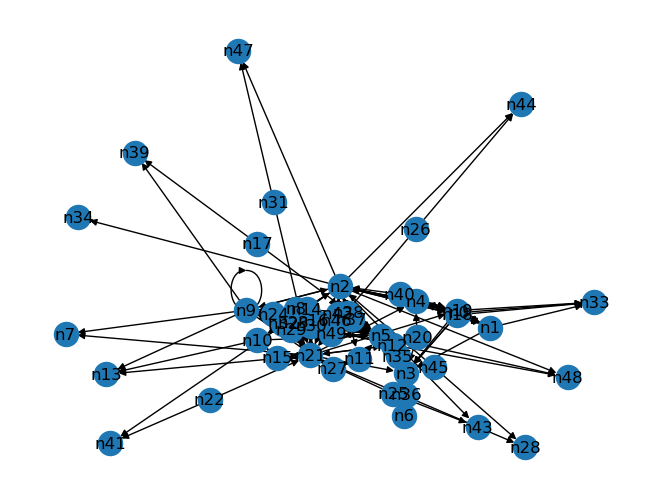

In [556]:
G = nx.DiGraph()
for reg in get_col_unique(seed_rxn_data, ['cpd_reg_left', 'cpd_reg_right']):
    G.add_node(reg)
    
for index, row in seed_rxn_data.iterrows():
    # G.add_node(row['reg_left'])
    # G.add_node(row['reg_right'])


        # if row['dirleft']:
        for r_item in row['cpd_reg_right']:
            for l_item in row['cpd_reg_left']:
                if l_item == 'n23':
                    print(row)
                if row['dirleft']:
                    G.add_edge(r_item, l_item)
                if row['dirright']:
                    G.add_edge(l_item, r_item)
                    
        # if row['dirright']:
        #     G.add_edge(row['reg_left'], row['reg_right'])

    
# connect reactions
# rxns = [(l,r) for l,r in seed_rxn_data[['reg_left', 'reg_right']].values]
# for rxn_a, rxn_b in itertools.product(rxns, rxns):
#     if len(rxn_a[0]) > 1:
#         ''
#     if rxn_a != rxn_b:
#         if rxn_a[-1] == rxn_b[0]:
#             print(rxn_a, rxn_b)
#             G.add_edge(rxn_a[-1], rxn_b[0])
nx.topological_sort(G)
nx.draw(G, with_labels=True)
# labels = nx.draw_networkx_labels(G, pos=nx.spring_layout(G))

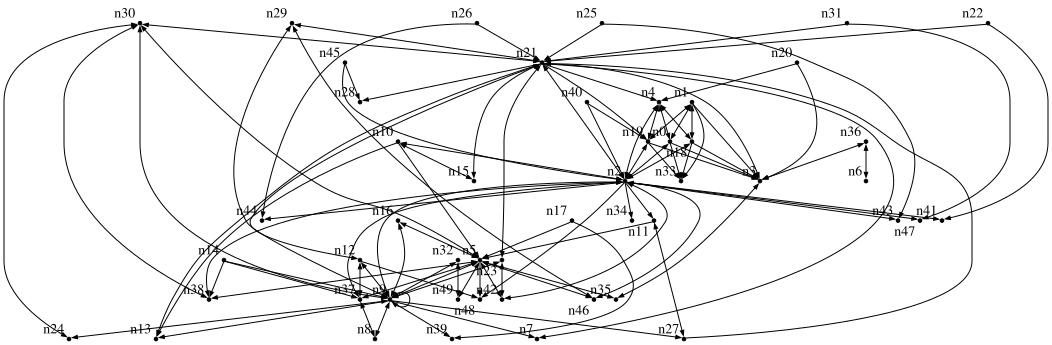

In [557]:
dot = render(G)
dot

In [543]:
seed_rxn_data.sort_values('cpd_reg_left')

,rxn_reg_left,rxn_reg_right,id,left,right,dirleft,dirright,left_names,right_names,cpd_reg_left,cpd_reg_right
0,n0,n19,rxn00147,[cpd00020],[cpd00061],False,True,"[H2O, ATP, Pyruvate]","[Phosphate, AMP, Phosphoenolpyruvate, H+]",[n0],[n18]
1,n1,n19,rxn00459,[cpd00482],[cpd00061],True,True,[2-Phospho-D-glycerate],"[H2O, Phosphoenolpyruvate]",[n1],[n18]
2,n1,n6,rxn01106,[cpd00482],[cpd00169],True,True,[2-Phospho-D-glycerate],[3-Phosphoglycerate],[n1],[n6]
3,n10,n25,rxn01870,[cpd00802],"[cpd00095, cpd00448]",True,True,[D-fructose-1-phosphate],"[Glycerone-phosphate, D-Glyceraldehyde]",[n10],"[n16, n22]"
4,n11,n26,rxn02314,[cpd00805],[cpd02371],False,True,"[ATP, D-Tagatose 6-phosphate]","[ADP, H+, D-Tagatose 1,6-biphosphate]",[n11],[n23]
5,n11,n28,rxn30050,[cpd00805],[cpd29681],True,False,"[ATP, H+, D-Tagatose 6-phosphate]","[ADP, D-Tagatose 1,6-biphosphate]",[n11],[n25]
6,n12,n14,rxn20522,[cpd00863],[cpd19035],True,True,[beta-D-Glucose 6-phosphate],[beta-D-Fructose 6-phosphate],[n12],[n14]
7,n12,n2,rxn02380,[cpd00863],[cpd00072],True,True,[beta-D-Glucose 6-phosphate],[D-fructose-6-phosphate],[n12],[n2]
8,n13,n27,rxn02936,[cpd02132],[cpd02645],True,True,[3-Phospho-D-erythronate],"[H2O, Phosphoenol-4-deoxy-3-tetrulosonate]",[n13],[n24]
10,n14,n20,rxn33839,[cpd19035],[cpd29990],True,False,"[ATP, beta-D-Fructose 6-phosphate]","[ADP, Fructose-1,6-Phosphate]",[n14],[n3]


In [181]:
def model_reactions_for_species(reactions_tbl_path, target_pathways):
    """
    Return {pathway_name: [model_reaction_ids]} using gapseq's own dbhit
    crosswalk -- avoids reimplementing the EC-mediated MetaCyc<->ModelSEED
    matching gapseq already did internally.
    """
    df = pd.read_csv(reactions_tbl_path, sep="\t", skiprows=3)
    df = df[df["pathway"].isin(target_pathways)]
    df = df[df["dbhit"].notna() & (df["dbhit"].astype(str).str.strip() != "")]
 
    pathway_col = "pathway.name" if "pathway.name" in df.columns else "pathway"
    out = {}
    for pathway_name, sub in df.groupby(pathway_col):
        model_ids = set()
        for hits in sub["dbhit"].astype(str):
            model_ids.update(h.strip() for h in hits.replace(";", " ").split() if h.strip())
        out[pathway_name] = list(model_ids)
    return out

 
def build_graph(species_files, target_pathways):
    """
    Union graph across species: nodes = metabolites (by name), edges =
    reactant->product for each reaction pulled from the target pathways.
    Each edge stores which species have it and which reaction/pathway it
    belongs to, for you to encode visually afterward.
    """
    G = nx.DiGraph()
 
    for species, (sbml_path, tbl_path) in species_files.items():
        model = cobra.io.read_sbml_model(sbml_path)
        model_rxn_ids = {r.id for r in model.reactions}
        species_pathways = model_reactions_for_species(tbl_path, target_pathways)
 
        for pathway_name, rxn_ids in species_pathways.items():
            # iterate over rxn ids
            for rxn_id in rxn_ids:
                rxn_id = rxn_id.strip()
                if rxn_id not in model_rxn_ids:
                    # dbhit reaction id may carry a compartment suffix (e.g. "rxn00001_c0")
                    # not present on the bare id, or vice versa -- adjust match if this fires often
                    matches = [r for r in model_rxn_ids if r.startswith(rxn_id) or rxn_id.startswith(r)]
                    if not matches:
                        continue
                    rxn_id = matches[0]
                rxn = model.reactions.get_by_id(rxn_id)
                reactants = [m.name or m.id for m in rxn.reactants]
                products = [m.name or m.id for m in rxn.products]
                
                for a in reactants:
                    for b in products:
                        if G.has_edge(a, b):
                            G[a][b]["species"].add(species)
                        else:
                            G.add_edge(a, b, reaction=rxn.id,
                                       pathway=pathway_name, species={species})
 
    return G



In [184]:
TARGET_PATHWAYS = [
    "glycolysis I (from glucose 6-phosphate)",
    # "glycolysis III (from glucose)",
    # "pentose phosphate pathway (oxidative branch) I",
    # "pyruvate fermentation to ethanol I",
    # "pyruvate fermentation to (S)-lactate",
    # "pyruvate fermentation to acetate II",
    # "heterolactic fermentation",
]
TARGET_PATHWAYS = [pway_name2id.loc[p] for p in TARGET_PATHWAYS]

In [187]:
pway_data = model_reactions_for_species(base + "HO2-3_MAG_03_protein-all-Reactions.tbl", 
                            TARGET_PATHWAYS)


In [185]:
# model_reactions_for_species(base + "HO2-3_MAG_03_protein-all-Reactions.tbl", 
#                             TARGET_PATHWAYS)
G = build_graph({'Entero':(base + "HO2-3_MAG_03_protein-draft.xml", base + "HO2-3_MAG_03_protein-all-Reactions.tbl")},
            TARGET_PATHWAYS)
dot = render(G)
# outpath = ''
# dot.render(outpath.rsplit(".svg", 1)[0], cleanup=True)

'HO2-3_MAG_03_protein' is not a valid SBML 'SId'.


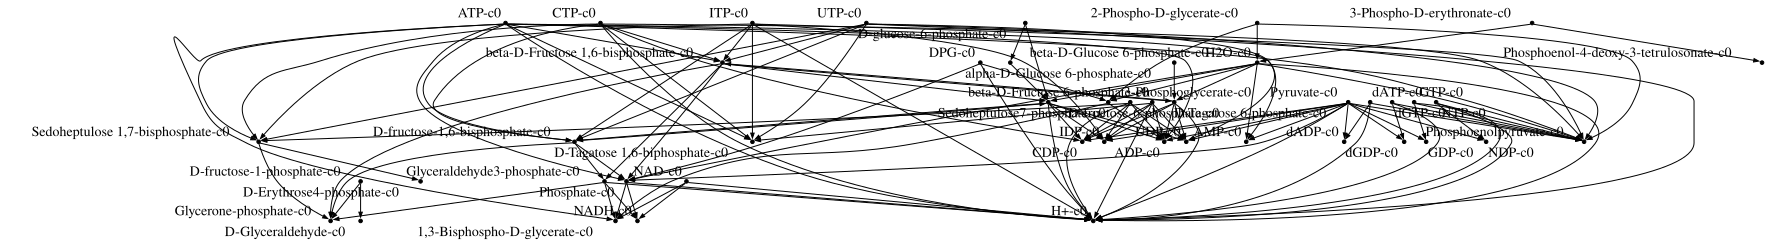

In [186]:
dot

In [118]:





def reactions_for_species(pathways_tbl_path, target_pathways):
    """Return {pathway_name: [reaction_ids]} for pathways gapseq called present."""
    df = pd.read_csv(pathways_tbl_path, sep="\t", skiprows=3)
    df = df[df["Name"].isin(target_pathways) & (df["Prediction"] == True)]  # noqa: E712
    return {
        row["Name"]: [s for s in str(row["ReactionsFound"]).split(" ") if s != '']
        for _, row in df.iterrows()
    }



def build_graph(species_files, target_pathways):
    """
    Union graph across species: nodes = metabolites (by name), edges =
    reactant->product for each reaction pulled from the target pathways.
    Each edge stores which species have it and which reaction/pathway it
    belongs to, for you to encode visually afterward.
    """
    G = nx.DiGraph()


    for species, (sbml_path, tbl_path) in SPECIES_FILES.items():
        model = cobra.io.read_sbml_model(sbml_path)
        species_pathways = reactions_for_species(tbl_path, TARGET_PATHWAYS)
        for pathway_name, rxn_ids in species_pathways.items():
            for rxn_id in rxn_ids:
                
                rxn_id = rxn_id.strip()
                if rxn_id not in model.reactions:
                    continue  # ID mismatch between pathway table and model -- check ID namespace
                rxn = model.reactions.get_by_id(rxn_id)
                reactants = [m.name or m.id for m in rxn.reactants]
                products = [m.name or m.id for m in rxn.products]
                for a in reactants:
                    for b in products:
                        if G.has_edge(a, b):
                            G[a][b]["species"].add(species)
                        else:
                            G.add_edge(a, b, reaction=rxn.id,
                                       pathway=pathway_name, species={species})

    return G


def render(G, outpath):
    """Bare edges/dots/labels SVG -- no boxes."""
    dot = graphviz.Digraph(format="svg", graph_attr={"splines": "true"})
    dot.node_attr.update(shape="point", width="0.05", label="")
    dot.edge_attr.update(arrowsize="0.5", fontsize="6")

    for node in G.nodes:
        print('yes')
        dot.node(node, xlabel=node)
    for a, b, data in G.edges(data=True):
        print('yes')
        dot.edge(a, b)

    return dot


def export_edge_table(G, outpath):
    """Companion table for programmatic recoloring: which species have each edge."""
    rows = [
        {"from": a, "to": b, "reaction": d["reaction"],
         "pathway": d["pathway"], "species": ";".join(sorted(d["species"]))}
        for a, b, d in G.edges(data=True)
    ]
    pd.DataFrame(rows).to_csv(outpath, sep="\t", index=False)

In [119]:

# species_name -> (sbml_path, pathways_tbl_path)
base = './../mag_pipeline/derep_mags/gapseq_test/'
SPECIES_FILES = {
    "Entero_1": (base + "HO2-3_MAG_03_protein-draft.xml", base + "HO2-3_MAG_03_protein-all-Pathways.tbl"),
    "Lacto_1": (base + "HO2-3_MAG_04_protein-draft.xml", base + "HO2-3_MAG_04_protein-all-Pathways.tbl"),

}

In [120]:
model = cobra.io.read_sbml_model(base + "HO2-3_MAG_03_protein-draft.xml")

'HO2-3_MAG_03_protein' is not a valid SBML 'SId'.


# Functional diversity plot

## Load data

In [64]:
# get interproscan name mapping to GO terms
interpro_go_data = pd.read_csv('/data/mhoffert/db/GO/interpro2go', sep=';', skiprows=6, header=None, names=['interpro_data', 'go'])
interpro_go_data['interpro_id'] = interpro_go_data['interpro_data'].apply(lambda x: x.split(':')[1].split(' ')[0])
interpro_go_data['go_annot'] = interpro_go_data['interpro_data'].apply(lambda x: x.split(' > GO:')[-1].rstrip())
interpro2go = interpro_go_data.set_index('interpro_id')['go']
interpro2go.head()

interpro_id
IPR000003     GO:0003677
IPR000003     GO:0003707
IPR000003     GO:0008270
IPR000003     GO:0006355
IPR000003     GO:0005634
Name: go, dtype: object

In [65]:
interpro_go_data.head()

,interpro_data,go,interpro_id,go_annot
0,InterPro:IPR000003 Retinoid X receptor/HNF4 > ...,GO:0003677,IPR000003,DNA binding
1,InterPro:IPR000003 Retinoid X receptor/HNF4 > ...,GO:0003707,IPR000003,nuclear steroid receptor activity
2,InterPro:IPR000003 Retinoid X receptor/HNF4 > ...,GO:0008270,IPR000003,zinc ion binding
3,InterPro:IPR000003 Retinoid X receptor/HNF4 > ...,GO:0006355,IPR000003,regulation of DNA-templated transcription
4,InterPro:IPR000003 Retinoid X receptor/HNF4 > ...,GO:0005634,IPR000003,nucleus


In [66]:
interpro2go_lists = interpro2go.reset_index().groupby('interpro_id').apply(lambda x: [i.lstrip(' ') for i in x['go']])

In [67]:
go_descs = interpro_go_data.set_index('go')['go_annot']

In [68]:
metacyc_pwys = pd.read_csv('/data/mhoffert/tools/gapseq/dat/meta_pwy.tbl', sep='\t')

In [69]:
repstr = '|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pathways|,'
metacyc_pwys['parsed_h'] = metacyc_pwys['hierarchy'].apply(lambda x: x.replace(repstr, '').lstrip('|').rstrip('|').split('|,|'))

In [70]:
metacyc_pwys.head(2)

,id,name,altname,hierarchy,taxrange,reaId,reaEc,keyRea,reaName,reaNr,ecNr,superpathway,status,spont,parsed_h
0,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","1,2-dichloroethane degradation","|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pat...",|TAX-2|,"DHLAXANAU-RXN,MOXXANAU-RXN,ALDXANAU-RXN,DHLBXA...","3.8.1.5,1.1.2.7,1.2.1.4,3.8.1.3",DHLAXANAU-RXN,"1,2-dichloroethane dehalogenase;2-chloroethano...",4,4,False,True,NaN,"[Degradation, CHLORINATED-COMPOUNDS-DEG]"
1,|14DICHLORBENZDEG-PWY|,"1,4-dichlorobenzene degradation","1,4-dichlorobenzene degradation","|CHLORINATED-COMPOUNDS-DEG|,|THINGS|,|FRAMES|,...",|TAX-1224|,"DIOXYXANFL-RXN,CHLOROBENDDH-RXN,CHLOROCATDIOXY...","1.14.12.26,1.3.1.119,1.13.11.M6,3.1.1.45,1.3.1...","DIOXYXANFL-RXN,CHLOROBENDDH-RXN","1,4-dichlorobenzene dioxygenase;1,4-dichlorobe...",9,7,False,True,"RXN-18361,RXN-18362","[CHLORINATED-COMPOUNDS-DEG, Degradation, AROMA..."


In [71]:
metacyc_pwys['h_1'] = metacyc_pwys['parsed_h'].apply(lambda x: x[0])
metacyc_pwys['h_2'] = metacyc_pwys['parsed_h'].apply(lambda x: x[1] if len(x) > 1 else x[-1])
metacyc_pwys['h_3'] = metacyc_pwys['parsed_h'].apply(lambda x: x[2] if len(x) > 2 else x[-1])
metacyc_pwys['h_4'] = metacyc_pwys['parsed_h'].apply(lambda x: x[3] if len(x) > 3 else x[-1])

In [72]:
metacyc_pwys['h_3'].value_counts()

PHENYLPROPANOID-SYN                  166
SECONDARY-METABOLITE-BIOSYNTHESIS    146
Toxin-Biosynthesis                   133
AROMATIC-COMPOUNDS-DEGRADATION       118
Terpenoid-Biosynthesis               117
                                    ... 
Fermentation-to-Lactate                1
PHYTOALEXIN-SYN                        1
LYSINE-DEG                             1
Hydrogen-Sulfide-Biosynthesis          1
MANDELATE-DEG                          1
Name: h_3, Length: 252, dtype: int64

In [73]:
# interpro_data = []
# # making functional table
interpro_columns = ['protein_accession', 'sequence_md5', 'sequence_length', 'analysis', 
                    'signature_accession', 'signature_description', 'start_location',
                    'stop_location', 'score', 'status', 'date', 'interpro_accession',
                    'interpro_annotations']
interpro_files = glob.glob('./../mag_pipeline/derep_mags/*_interpro.tsv')
interpro_dfs = []
for file in interpro_files:
    df = pd.read_csv(file, sep='\t', header=None, names=interpro_columns)
    # df = pd.merge(df,  metacyc_pwys, left_on='ID', right_on='id', how='inner')
    interpro_dfs.append(df.assign(genome=mag2species.loc[file.split('/')[-1].split('_interpro')[0]]))

interpro_data = pd.concat(interpro_dfs)

In [74]:
interpro2desc = interpro_data.groupby('interpro_accession').apply(lambda x: x['interpro_annotations'].unique()[0])

In [76]:
interpro_subset = interpro_data[interpro_data['signature_description'].str.contains('transport')].groupby(['genome', 'protein_accession']).count()['signature_description'].reset_index()
interpro_subset['genome'] = interpro_subset['genome'].replace({'s__': 'g__Enterobacter'})
# interpro_subset['taxon'] = interpro_subset['genome'].apply(lambda x: classify_genome(x))

## load pathways for all species

In [118]:
pway_data = glob.glob('./../mag_pipeline/derep_mags/gapseq_test/*-all-Pathways.tbl')
pway_dfs = []
for file in pway_data:
    df = pd.read_csv(file, sep='\t', skiprows=3)
    df = pd.merge(df,  metacyc_pwys, left_on='ID', right_on='id', how='inner')
    pway_dfs.append(df.assign(genome=mag2species.loc[file.split('/')[-1].split('_protein')[0]]))
    

In [119]:
pway_df = pd.concat(pway_dfs)
# pway_df = pway_df[pway_df['Prediction']]

In [120]:
plotdf = pway_df[pway_df['Prediction']].groupby(['genome', 'h_1', 'h_2']).count().reset_index().iloc[:, :4]

In [121]:
pway_df['h_1'].value_counts().index

Index(['Biosynthesis', 'Degradation', 'Energy-Metabolism',
       'Macromolecule-Modification', 'Vitamin-Biosynthesis',
       'Polymer-Degradation', 'Activation-Inactivation-Interconversion',
       'CHLORINATED-COMPOUNDS-DEG', 'Metabolic-Clusters', 'Detoxification',
       'TETRATERPENOID-SYN', 'SECONDARY-METABOLITE-DEGRADATION',
       'Electron-Transfer', 'Glycan-Pathways', 'Toxin-Biosynthesis',
       'Pyruvate-Degradation', 'PHENYLPROPANOID-SYN', 'Terpenoid-Biosynthesis',
       'POLYKETIDE-SYN', 'SECONDARY-METABOLITE-BIOSYNTHESIS',
       'Carriers-Biosynthesis', 'HORMONE-SYN', 'Tetrapyrrole-Biosynthesis',
       'Enzyme-Cofactor-Biosynthesis', 'Metabolic-Regulators',
       'Bioluminescence', 'Polyamine-Biosynthesis',
       'Unsaturated-Fatty-Acids-Biosynthesis', 'Sulfur-Metabolism',
       'Lipid-Biosynthesis', 'PUR-NUC-SYN', 'Fatty-Acid-and-Lipid-Degradation',
       'Phenolic-Compounds-Degradation', 'PYR-NUC-SYN',
       'Carbohydrates-Degradation', 'Cell-Structure-Biosynth

In [122]:
pway_df[pway_df['Prediction']]['h_1'].value_counts()

Biosynthesis                               599
Degradation                                441
Energy-Metabolism                           97
Vitamin-Biosynthesis                        68
Pyruvate-Degradation                        34
SECONDARY-METABOLITE-DEGRADATION            31
Macromolecule-Modification                  28
Carriers-Biosynthesis                       21
Enzyme-Cofactor-Biosynthesis                19
Detoxification                              18
Metabolic-Regulators                        15
Tetrapyrrole-Biosynthesis                   11
PUR-NUC-SYN                                 10
PYR-NUC-SYN                                  9
Metabolic-Clusters                           8
Polyamine-Biosynthesis                       7
Electron-Transfer                            7
Activation-Inactivation-Interconversion      7
TETRATERPENOID-SYN                           6
Glycan-Pathways                              6
Sulfur-Metabolism                            5
Noncarbon-Nut

In [123]:
pway_df[pway_df['Prediction']]['h_1'].value_counts().index

terms = ['Biosynthesis', 'Degradation', 'Energy-Metabolism', 
         'Detoxification',
         'Vitamin-Biosynthesis',
         'SECONDARY-METABOLITE-DEGRADATION',
           #'Polymer-Degradation', 
         # 'Activation-Inactivation-Interconversion',
       # 'Metabolic-Clusters',
         'Macromolecule-Modification'
         # 'Pyruvate-Degradation', 
         # 'Carbohydrates-Degradation',
         # 'Amino-Acid-Fermentation', 
         # 'Glycogen-Degradation',
         # 'Alcohol-Degradation', 
         # 'LACTOSE-DEG',
         # 'Starch-Degradation'
        ]

plotdf = pway_df[pway_df['Prediction']].groupby(['genome', 'h_1', 'h_2']).count().reset_index().iloc[:, :4]
plotdf['genome'] = plotdf['genome'].replace({'s__': 'g__Enterobacter'})

[plotdf[plotdf['h_1'].eq(go_term)].shape[0] for go_term in terms]

[81, 87, 43, 17, 15, 7, 11]

In [124]:
# plotdf = 
# pway_df[pway_df['Prediction']].groupby(['genome', 'h_1', 'h_2']).count()['ID'].sort_values(ascending=False).head(50)

In [125]:
len(terms)

7

In [126]:
def classify_genome(genome):
    lactos = ['s__Schleiferilactobacillus harbinensis',
 's__Lacticaseibacillus paracasei',
    's__Lentilactobacillus parabuchneri',
 's__Levilactobacillus brevis',]
    acetos = ['s__Gluconobacter_A japonicus']
    if genome in lactos:
        return 'L'
    elif genome in acetos:
        return 'A'
    else:
        return 'E'

plotdf['taxon'] = plotdf['genome'].apply(lambda x: classify_genome(x))

In [127]:
grouped_plotdf = plotdf.groupby(['genome', 'h_1']).agg({'ID':'sum'}).reset_index() #.sum()

In [131]:
# semantic_groups = [ 7,8,37,31,70,87,82,13,4]
semantic_groups = [3,5,6,7,8,10,13,31,70,71]
semantics_plotdf = (orthogroup_counts > 0).astype(int).T.dot((og2cluster.loc[:, semantic_groups] > 0).astype(int)).rename(index=mag2species, columns=cluster2desc).stack().reset_index()
semantics_plotdf.head()

,level_0,level_1,0
0,s__Pantoea agglomerans,3: developmental process,3
1,s__Pantoea agglomerans,5: cell-cell signaling,1
2,s__Pantoea agglomerans,6: response to stimulus,88
3,s__Pantoea agglomerans,7: locomotion,11
4,s__Pantoea agglomerans,8: biofilm formation,0


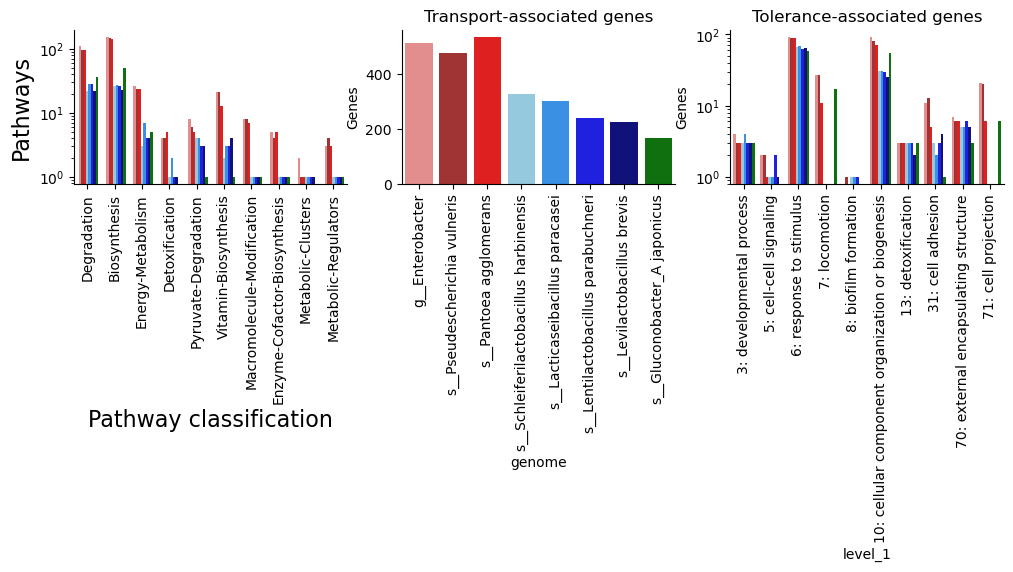

In [133]:
fig = plt.figure(figsize=(12,2))
ax = fig.add_subplot(1, 3, 1)
n_groups = 10
ax.set_yscale('log')
sns.barplot(data=grouped_plotdf[grouped_plotdf['h_1'].isin(plotdf['h_1'].value_counts().head(n_groups).index)], x='h_1', hue='genome', y='ID',
            hue_order=species_color_map.keys(), palette=species_color_map.values(), order=plotdf['h_1'].value_counts().head(n_groups).index,
            # hue_order=['E', 'L', 'A'], palette=[sns.desaturate(i, 0.75) for i in ['red', 'blue', 'green']],
           errwidth=0.25)
ax.get_legend().remove()
ax.tick_params(rotation=90, axis='x' )
sns.despine()
ax.set_ylabel('Pathways', fontsize=16)
ax.set_xlabel('Pathway classification', fontsize=16)

ax = fig.add_subplot(1, 3, 2)
sns.barplot(data=interpro_subset.groupby(['genome']).count().reset_index(), x='genome',  y='protein_accession',
            order=list(species_color_map.keys())[1:], palette=list(species_color_map.values())[1:],
            # hue_order=['E', 'L', 'A'], palette=[sns.desaturate(i, 0.75) for i in ['red', 'blue', 'green']],
            
           errwidth=0.25)


ax.tick_params(rotation=90, axis='x')
ax.set_ylabel('Genes')
ax.set_title(f'Transport-associated genes')

ax = fig.add_subplot(1, 3, 3)
ax.set_yscale('log')
sns.barplot(data=semantics_plotdf, x='level_1',  y=0, hue='level_0', 
            hue_order=list(species_color_map.keys())[1:], palette=list(species_color_map.values())[1:],
            # hue_order=['E', 'L', 'A'], palette=[sns.desaturate(i, 0.75) for i in ['red', 'blue', 'green']],
            
           errwidth=0.25)


ax.tick_params(rotation=90, axis='x')
ax.get_legend().remove()
ax.set_ylabel('Genes')
ax.set_title(f'Tolerance-associated genes')
# plt.tick_params(labelbottom=False)

sns.despine()
plt.savefig('./../data/figures/pathway_frequencies.svg', bbox_inches='tight')

## iRep plot

In [1768]:
'''
get IRep data
'''
irep_results = glob.glob('./../data/irep/irep_results/*.tsv')

In [1769]:
irep_df = pd.DataFrame(columns=['sample', 'genome', 'iRep', 'unfiltered'])

index = 0
for file in irep_results:
    
    
    with open(file, 'r') as handle:
        lines= handle.readlines()

        sample = file.split('/')[-1].split('_')[0]
        genome, irep = lines[2].split()
        genome = genome.split('/')[-1].replace('.fa', '')
        irep = float(irep) if irep != 'n/a' else np.nan
        unfiltered = lines[6].split()[-1]
        unfiltered = float(unfiltered) if unfiltered != 'n/a' else np.nan

        irep_df.loc[index, :] = [sample, genome, irep, unfiltered]
        index += 1

In [1770]:
irep_plotdf = pd.merge(irep_df, md, left_on='sample', right_on='Sample ID')

In [1771]:
irep_plotdf['replicate'] = irep_plotdf['Sample ID'].apply(lambda x: x[2])
irep_plotdf['genome'] = irep_plotdf['genome'].map(mag2species)

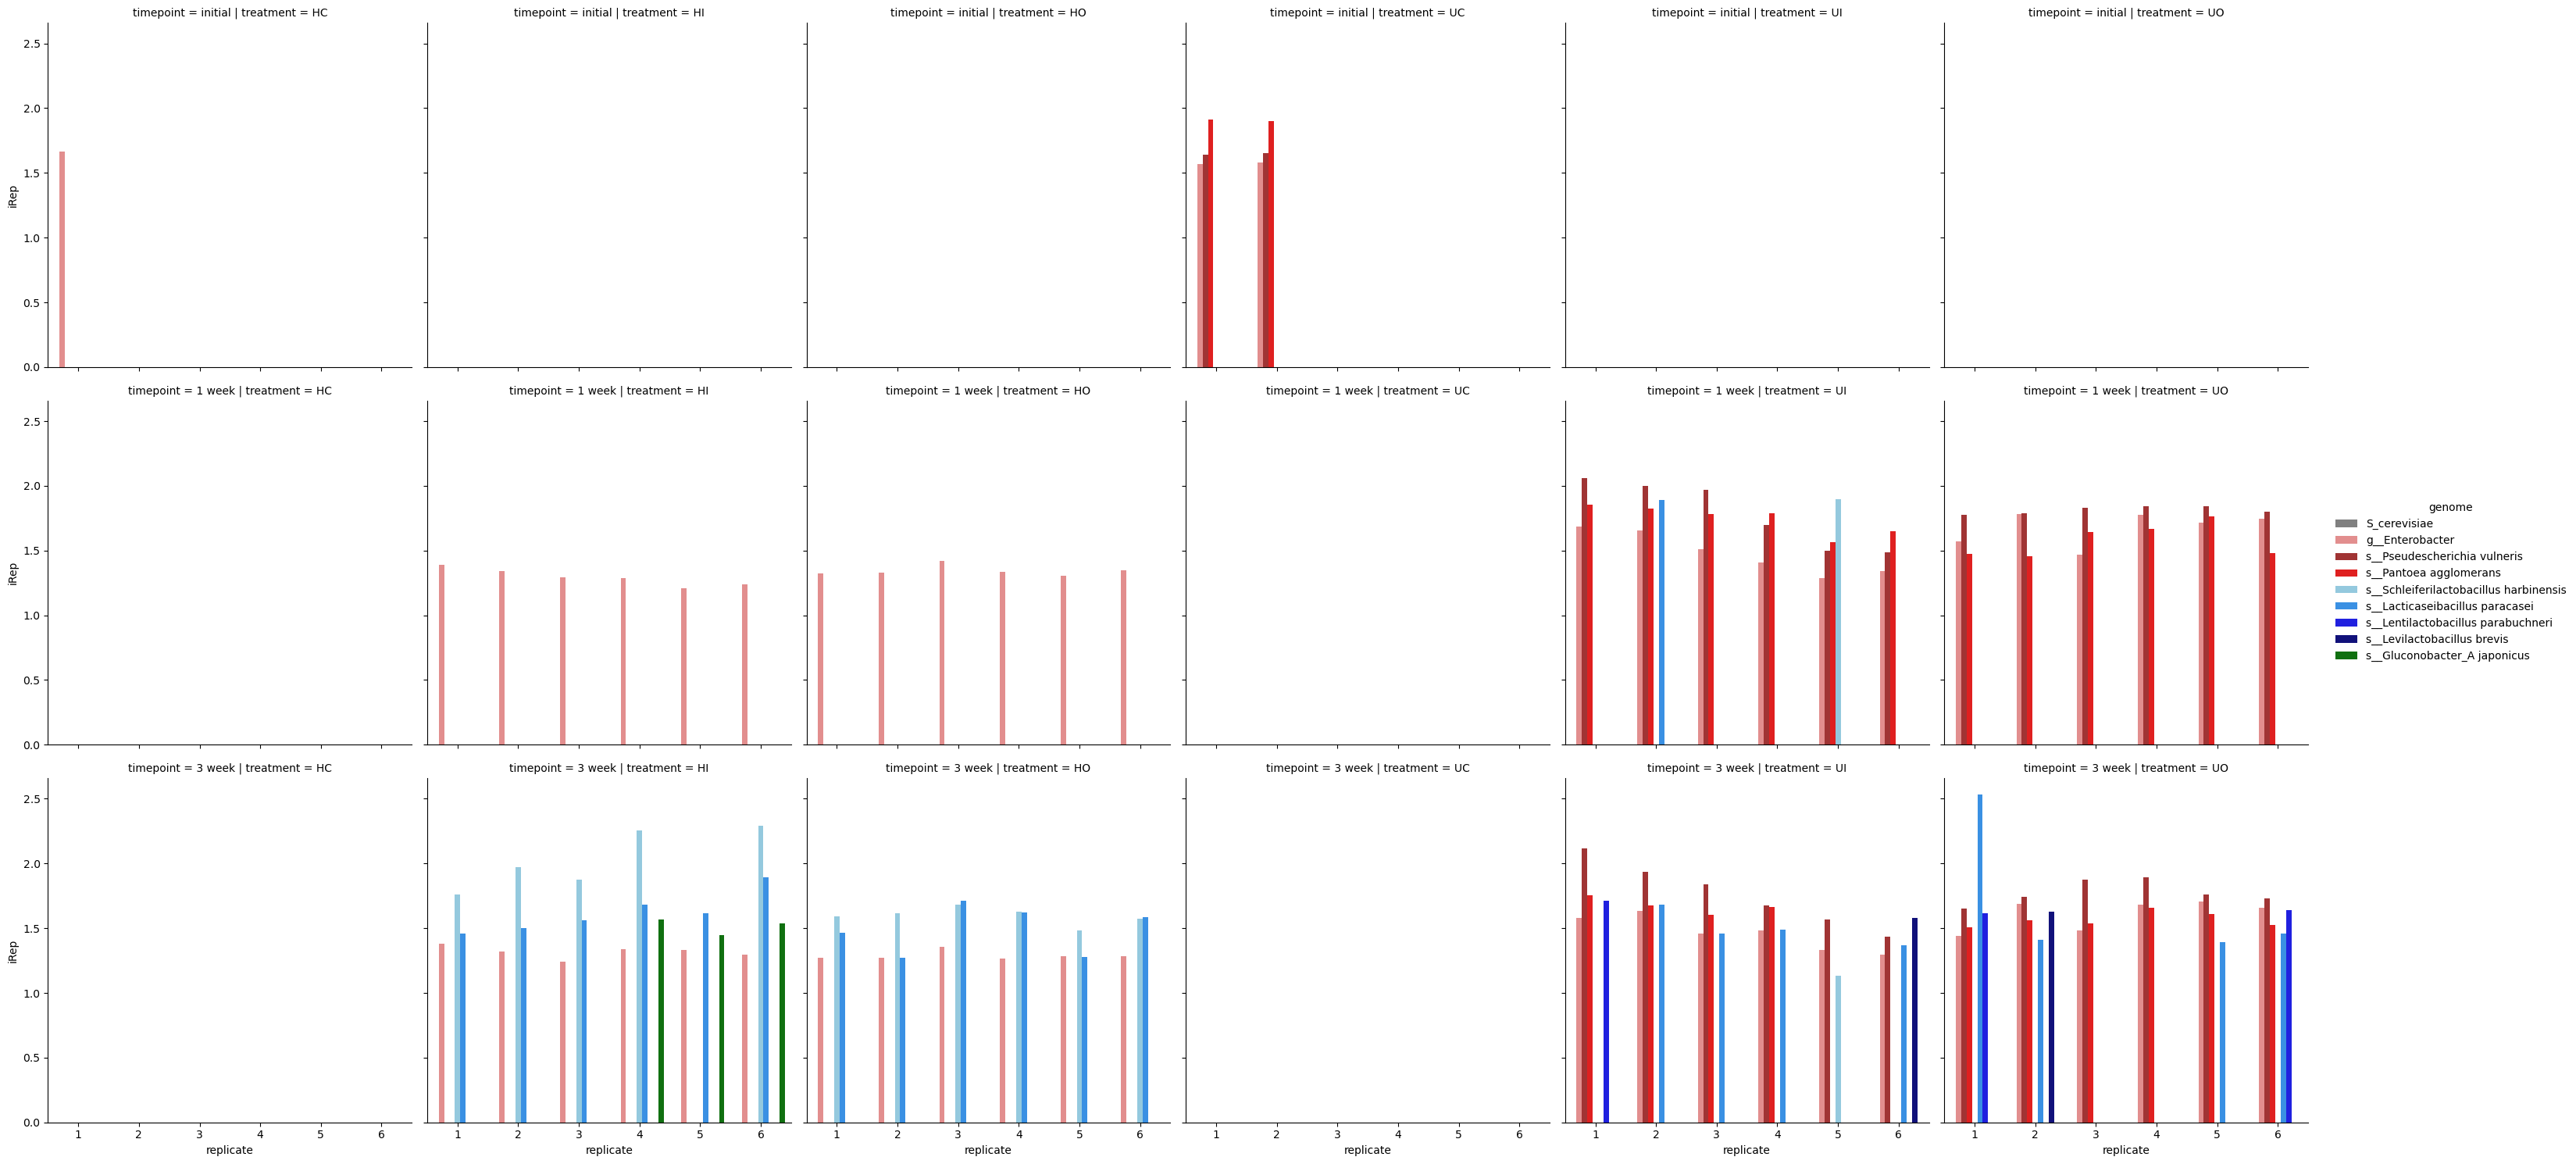

In [1772]:
sns.catplot(data=irep_plotdf, row='timepoint', col='treatment', x='replicate', y='iRep', hue='genome', kind='bar',
            hue_order=species_color_map.keys(), palette=species_color_map.values(),
           )

In [1348]:
interpro_data[interpro_data['interpro_annotations'].str.contains('ribosomal')].groupby(['genome', 'interpro_accession']).count().unstack()

protein_accession                      \
interpro_accession                             IPR003772 IPR004394 IPR011332   
genome                                                                         
g__Enterobacter                                      1.0       3.0       3.0   
s__Gluconobacter_A japonicus                         1.0       3.0       2.0   
s__Lacticaseibacillus paracasei                      1.0       3.0       3.0   
s__Lentilactobacillus parabuchneri                   1.0       3.0       4.0   
s__Levilactobacillus brevis                          1.0       3.0       2.0   
s__Pantoea agglomerans                               1.0       3.0       3.0   
s__Pseudescherichia vulneris                         1.0       3.0       3.0   
s__Schleiferilactobacillus harbinensis               1.0       3.0       3.0   

                                                                      \
interpro_accession                     IPR013005 IPR014717 IPR019984   
genome                                                                 
g__Enterobacter                              3.0       1.0       2.0   
s__Gluconobacter_A japonicus                 3.0       1.0       2.0   
s__Lacticaseibacillus paracasei              3.0       1.0       2.0   
s__Lentilactobacillus parabuchneri           3.0       1.0       2.0   
s__Levilactobacillus brevis                  3.0       1.0       2.0   
s__Pantoea agglomerans                       NaN       1.0       NaN   
s__Pseudescherichia vulneris                 3.0       1.0       2.0   
s__Schleiferilactobacillus harbinensis       3.0       1.0       2.0   

                                                                      \
interpro_accession                     IPR027437 IPR028364 IPR029064   
genome                                                                 
g__Enterobacter                              1.0       2.0       4.0   
s__Gluconobacter_A japonicus                 1.0       2.0       4.0   
s__Lacticaseibacillus paracasei              1.0       2.0       8.0   
s__Lentilactobacillus parabuchneri           1.0       2.0       7.0   
s__Levilactobacillus brevis                  1.0       2.0       7.0   
s__Pantoea agglomerans                       1.0       NaN       4.0   
s__Pseudescherichia vulneris                 1.0       NaN       4.0   
s__Schleiferilactobacillus harbinensis       1.0       2.0       8.0   

                                                  ... interpro_annotations  \
interpro_accession                     IPR032528  ...            IPR011332   
genome                                            ...                        
g__Enterobacter                              NaN  ...                  3.0   
s__Gluconobacter_A japonicus                 NaN  ...                  2.0   
s__Lacticaseibacillus paracasei              1.0  ...                  3.0   
s__Lentilactobacillus parabuchneri           1.0  ...                  4.0   
s__Levilactobacillus brevis                  1.0  ...                  2.0   
s__Pantoea agglomerans                       NaN  ...                  3.0   
s__Pseudescherichia vulneris                 NaN  ...                  3.0   
s__Schleiferilactobacillus harbinensis       1.0  ...                  3.0   

                                                                      \
interpro_accession                     IPR013005 IPR014717 IPR019984   
genome                                                                 
g__Enterobacter                              3.0       1.0       2.0   
s__Gluconobacter_A japonicus                 3.0       1.0       2.0   
s__Lacticaseibacillus paracasei              3.0       1.0       2.0   
s__Lentilactobacillus parabuchneri           3.0       1.0       2.0   
s__Levilactobacillus brevis                  3.0       1.0       2.0   
s__Pantoea agglomerans                       NaN       1.0       NaN   
s__Pseudescherichia vulneris                 3.0       1.0       

In [1313]:
irep_plotdf[irep_plotdf.timepoint.eq('1 week') & irep_plotdf.treatment.eq('HI')]

,sample,genome,iRep,unfiltered,Unnamed: 0,Sample Description,Sample Name,Sample ID,timepoint,Filter replicate,...,Alcohol (% v/v),Alcohol (% w/w),Specific Gravity,Ea (app. extract) (% w/w),Er (real extract) (% w/w),p (original extract) (% w/w),Concentration Sugar,RDF (real deg. of ferm.),ADF (% w/w),Calories (kcal/12oz)
3,HI1-1,HI4-3_MAG_04,NaN,10.804882,20,"Hopped, Indoor, Jar 1, wk1, filter 1",HI1 wk 1 #1,HI1-1,1 week,1,...,3.6,2.81,1.01297,3.32,4.64,10.15,3.32,55.59,67.29,135.03
4,HI1-1,HO2-3_MAG_03,NaN,10.206192,20,"Hopped, Indoor, Jar 1, wk1, filter 1",HI1 wk 1 #1,HI1-1,1 week,1,...,3.6,2.81,1.01297,3.32,4.64,10.15,3.32,55.59,67.29,135.03
7,HI2-1,HI4-3_MAG_04,NaN,11.534407,21,"Hopped, Indoor, Jar 2, wk1, filter 1",HI2 wk 1 #1,HI2-1,1 week,1,...,3.66,2.86,1.01248,3.2,4.54,10.14,3.2,56.53,68.46,134.59
8,HI2-1,HO2-3_MAG_03,NaN,4.258766,21,"Hopped, Indoor, Jar 2, wk1, filter 1",HI2 wk 1 #1,HI2-1,1 week,1,...,3.66,2.86,1.01248,3.2,4.54,10.14,3.2,56.53,68.46,134.59
11,HI3-1,HI4-3_MAG_04,NaN,10.645985,22,"Hopped, Indoor, Jar 3, wk1, filter 1",HI3 wk 1 #1,HI3-1,1 week,1,...,---,---,0.00951,Out of range,---,---,Out of range,---,---,---
12,HI3-1,HO2-3_MAG_03,NaN,3.684453,22,"Hopped, Indoor, Jar 3, wk1, filter 1",HI3 wk 1 #1,HI3-1,1 week,1,...,---,---,0.00951,Out of range,---,---,Out of range,---,---,---
15,HI4-1,HI4-3_MAG_04,NaN,10.948631,23,"Hopped, Indoor, Jar 4, wk1, filter 1",HI4 wk 1 #1,HI4-1,1 week,1,...,3.68,2.87,1.01214,3.11,4.46,10.09,3.11,57.09,69.16,133.77
16,HI4-1,HO2-3_MAG_03,NaN,3.362677,23,"Hopped, Indoor, Jar 4, wk1, filter 1",HI4 wk 1 #1,HI4-1,1 week,1,...,3.68,2.87,1.01214,3.11,4.46,10.09,3.11,57.09,69.16,133.77
19,HI5-1,HI4-3_MAG_04,NaN,4.68851,24,"Hopped, Indoor, Jar 5, wk1, filter 1",HI5 wk 1 #1,HI5-1,1 week,1,...,3.77,2.95,1.01149,2.95,4.33,10.11,2.95,58.47,70.87,133.74
20,HI5-1,HO2-3_MAG_03,NaN,5.373734,24,"Hopped, Indoor, Jar 5, wk1, filter 1",HI5 wk 1 #1,HI5-1,1 week,1,...,3.77,2.95,1.01149,2.95,4.33,10.11,2.95,58.47,70.87,133.74


In [1282]:
lines[2].split()[-1]

ValueError: could not convert string to float: 'n/a'

In [1280]:
lines[6].split()

['/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/HO2-3_MAG_04.fa',
 '4.357098553328602']

Biosynthesis 81
Degradation 87
Energy-Metabolism 43


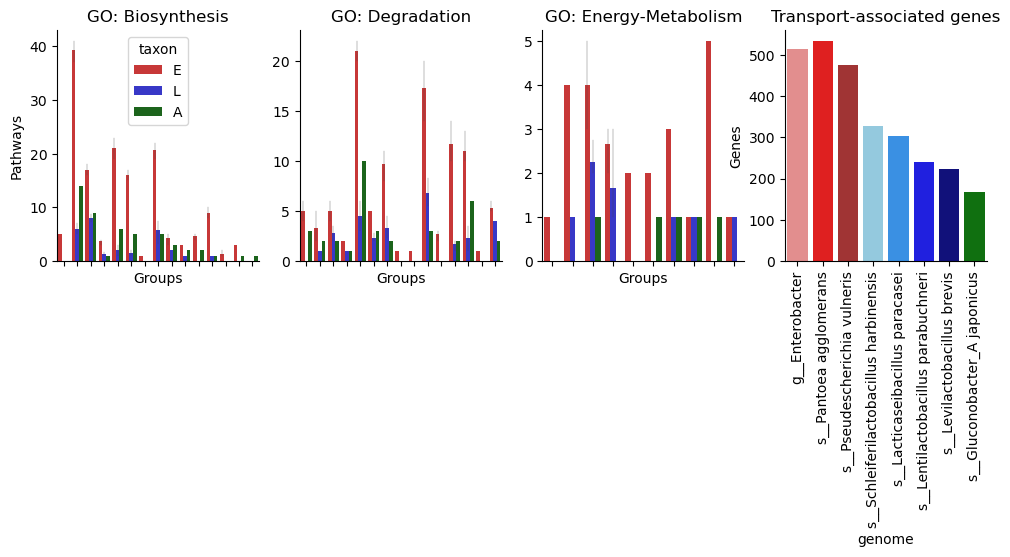

In [1264]:
fig = plt.figure(figsize=(12, 3))


i = 1
for go_term in terms[:3]:
    ax = fig.add_subplot(1, 4, i)
    subset = plotdf[plotdf['h_1'].eq(go_term)]
    print(go_term, len(subset))
    sns.barplot(data=subset, x='h_2', hue='taxon', y='ID',
                # hue_order=species_color_map.keys(), palette=species_color_map.values(),
                hue_order=['E', 'L', 'A'], palette=[sns.desaturate(i, 0.75) for i in ['red', 'blue', 'green']],
               errwidth=0.25)
               
    
    # ax.tick_params(rotation=90, )
    if i == 1:
        
        ax.set_ylabel('Pathways')
    else:
        ax.get_legend().remove()
        ax.set_ylabel('')
    ax.set_xlabel('Groups')
    plt.tick_params(labelbottom=False)
    ax.set_title(f'GO: {go_term}')
    sns.despine()
    
    i += 1
    
ax = fig.add_subplot(1, 4, 4)
sns.barplot(data=interpro_subset.groupby(['genome']).count().reset_index(), x='genome',  y='protein_accession',
            order=list(species_color_map.keys())[1:], palette=list(species_color_map.values())[1:],
            # hue_order=['E', 'L', 'A'], palette=[sns.desaturate(i, 0.75) for i in ['red', 'blue', 'green']],
            
           errwidth=0.25)


ax.tick_params(rotation=90, axis='x')
ax.set_ylabel('Genes')

# plt.tick_params(labelbottom=False)
ax.set_title(f'Transport-associated genes')
sns.despine()

plt.savefig('./../data/figures/taxa_functional_diversity.svg', bbox_inches='tight')

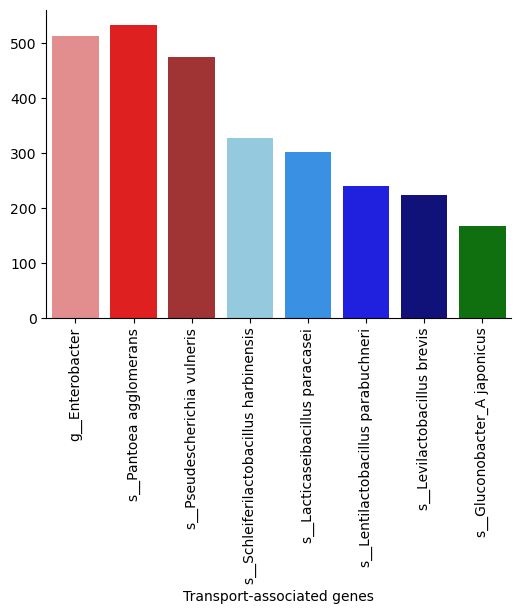

In [804]:
fig, ax = plt.subplots(figsize=(6,4))

sns.despine()

# Hops analysis

In [38]:
horA_hits = pd.read_csv('/data/mhoffert/fiererlab/beer/Group1/2022-11-30_functional_table.csv', index_col=0).stack().reset_index()
horA_hits = pd.merge(md, horA_hits, left_on='Sample ID', right_on='level_1') 

In [39]:
horA_hits.head(2) #) #.columns

,Unnamed: 0,Sample Description,Sample Name,Sample ID,timepoint,Filter replicate,pH,Density,Scent notes,Notes,...,Ea (app. extract) (% w/w),Er (real extract) (% w/w),p (original extract) (% w/w),Concentration Sugar,RDF (real deg. of ferm.),ADF (% w/w),Calories (kcal/12oz),Gene,level_1,0
0,20,"Hopped, Indoor, Jar 1, wk1, filter 1",HI1 wk 1 #1,HI1-1,1 week,1,4.48,3.4,"Grainy, 4VG",NaN,...,3.32,4.64,10.15,3.32,55.59,67.29,135.03,HitA,HI1-1,0
1,20,"Hopped, Indoor, Jar 1, wk1, filter 1",HI1 wk 1 #1,HI1-1,1 week,1,4.48,3.4,"Grainy, 4VG",NaN,...,3.32,4.64,10.15,3.32,55.59,67.29,135.03,HorA,HI1-1,0


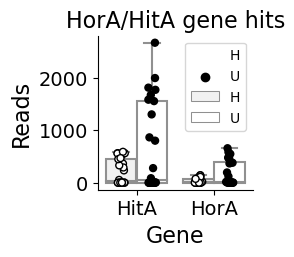

In [40]:
fig = plt.figure(figsize=(2,2))
ax = fig.add_subplot(1,1,1)
sns.stripplot(data=horA_hits, y=0, x='Gene', 
              alpha=1, s=5, linewidth=1, 
              hue='Hops', dodge=True, palette=['w', 'k'], edgecolor='k')
sns.boxplot(data=horA_hits, y=0, x='Gene', hue='Hops', color='white')
ax.set_ylabel('Reads', fontsize=16)
ax.set_xlabel('Gene', fontsize=16)
ax.set_title('HorA/HitA gene hits', fontsize=16)
plt.tick_params(labelsize=14)
sns.despine()
lgd = ax.legend()
plt.savefig('./../data/figures/HorA_gene_hits.svg', bbox_inches='tight', bbox_extra_artists=(lgd,))

In [41]:
horA_plotdf = pd.merge(horA_hits, clr_table, left_on='Sample ID', right_index=True)

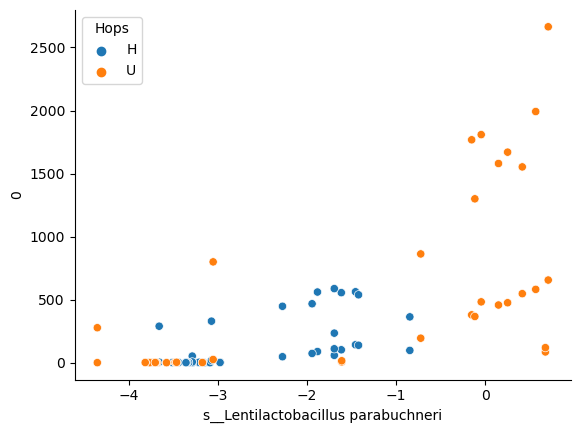

In [42]:
sns.scatterplot(data=horA_plotdf,
                y=0, x='s__Lentilactobacillus parabuchneri', hue='Hops')
sns.despine()

## Compile orthogroup data

In [46]:
seq2genome = []
n_records = 0
# for each protein fasta in orthofinder run
for faa in glob.glob('./../data/orthofinder/proteomes/*.faa'):
    # get records
    with open(faa, 'r') as handle:
        faa_lines = handle.readlines()
    # get genome id
    genome = faa.split('/')[-1].replace('_protein.faa', '')
    # get sequence ids
    headers = [l.split(' ')[0].lstrip('>') for l in faa_lines if l[0] == '>']
    # make series of seq id -> genome id
    seq2genome.append(pd.Series(index=headers, data=[genome]*len(headers)))
    # header count
    n_records += len(headers)

seq2genome = pd.concat(seq2genome)

In [47]:
# check all records have unique ids
len(set(seq2genome.index)), n_records

(24653, 24653)

In [48]:
with open('./../data/orthofinder/proteomes/OrthoFinder/Results_Jun26_1/Orthogroups/Orthogroups.txt', 'r') as handle:
    lines = handle.readlines()

orthogroup_counts = []
gene2ortho = []
for l in lines:
    splits = l.split(': ')
    group, members = splits[0], splits[1].strip().split(' ')
    genome_ids = [seq2genome.loc[m] for m in members]
    orthogroup_counts.append(pd.Series(genome_ids, name=group).value_counts())
    gene2ortho.append(pd.Series(index=members, data=[group]*len(members)))
    
gene2ortho = pd.concat(gene2ortho)
orthogroup_counts = pd.concat(orthogroup_counts, axis=1).T

orthogroup_counts = orthogroup_counts.rename(columns=mag2species).fillna(0)

In [49]:
# entero_gff = Gff("./../mag_pipeline/derep_mags/UO5-1_MAG_02.gff")
# vuln_gff = Gff("./../mag_pipeline/derep_mags/UO5-1_MAG_01.gff")

# # 
# vuln_orthos = get_shared_orthos(orthogroup_counts, [vuln_gff])
# # 
# entero_orthos = get_shared_orthos(orthogroup_counts, [entero_gff])

# ent_hop_orthos = entero_orthos - vuln_orthos

# gff_list = [entero_gff, vuln_gff]

# # mapping of gene id to genome id
# gene2genome = pd.Series(dtype='object')
# for g in gff_list:
#     print(g.name)
#     for i, r in enumerate(g.all_records):
#         gene2genome.loc[r.attrs['ID'][0].split(':')[0]] = g.name

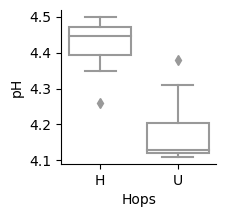

In [50]:
fig, ax = plt.subplots(figsize=(2,2))
sns.boxplot(data=md[md['timepoint'].eq('1 week')],
            x='Hops', y='pH', color='white')
sns.despine()

In [53]:
mag_list = ['g__Enterobacter',
            's__Pseudescherichia vulneris']

In [54]:
''' 
make a dataframe for plotting orthogroups
'''
# make dataframe describing sharedness of orthogroups
ortho_plotdf = orthogroup_counts.loc[:, mag_list].stack().reset_index().rename(columns={'index':'order',
                                                                                              'level_0':'orthogroup',
                                                                                              'level_1':'mag',
                                                                                              0:'count'})

# enable sorting by core (shared) and accessory
membership = pd.Series(data=[f'{i[0]}{i[1]}' for i in (orthogroup_counts.loc[:, mag_list].fillna(0) > 0).astype(int).values],
          index=orthogroup_counts.index)

# add membership and copy number columns
ortho_plotdf['group'] = ortho_plotdf['orthogroup'].map(membership)
ortho_plotdf['diff'] = ortho_plotdf['orthogroup'].map(orthogroup_counts.loc[:, mag_list[0]].fillna(0) - orthogroup_counts.loc[:, mag_list[1]].fillna(0))

# sort by sharedness
ortho_plotdf = ortho_plotdf.sort_values(['group']).reset_index(drop=True).reset_index()
group_map = ortho_plotdf.groupby('group')['mag'].first().map(mag2species)
group_map.loc['11'] = 'shared'
ortho_plotdf['group'] = ortho_plotdf['group'].map(group_map)
ortho_plotdf = ortho_plotdf.set_index('orthogroup')
ortho_plotdf

,index,mag,count,group,diff
orthogroup,,,,,
OG0006043,0,g__Enterobacter,0.0,NaN,0.0
OG0004492,1,s__Pseudescherichia vulneris,0.0,NaN,0.0
OG0004493,2,g__Enterobacter,0.0,NaN,0.0
OG0006002,3,g__Enterobacter,0.0,NaN,0.0
OG0006002,4,s__Pseudescherichia vulneris,0.0,NaN,0.0
...,...,...,...,...,...
OG0002576,15607,g__Enterobacter,1.0,shared,0.0
OG0002576,15608,s__Pseudescherichia vulneris,1.0,shared,0.0
OG0002577,15609,g__Enterobacter,1.0,shared,0.0


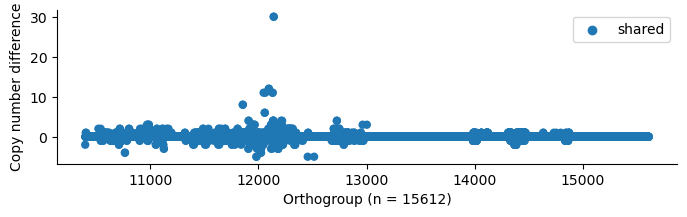

In [55]:
fig, ax = plt.subplots(figsize=(8,2))
sns.scatterplot(data=ortho_plotdf,
            x='index', hue='group', y='diff', linewidth=0)

lgd = ax.legend()
ax.set_ylabel('Copy number difference')
ax.set_xlabel(f'Orthogroup (n = {len(ortho_plotdf)})')
sns.despine()

## Functions and imports for semantic GO clsutering

In [56]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

In [57]:
from goatools.obo_parser import GODag
from goatools.anno.gaf_reader import GafReader  # or your own annotation loader
from goatools.semantic import TermCounts, resnik_sim, lin_sim
import itertools

In [58]:
from collections import Counter
import re

In [59]:
import sys

# Increase the recursion limit from default (usually 1000) to a higher value
sys.setrecursionlimit(10000)

In [60]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
def get_col_unique(df, cols):
    '''
    get unique items from rows containing lists
    '''
    
    unique = []
    for col in cols:
        if isinstance(df[col].values[0], list):
            item_list = [i for item in df[col].values for i in item]
        else:
            item_list = [item for item in df[col].values]
        
        unique += item_list
    return list(set(unique))

In [62]:
# load GO DAG
godag = GODag("/data/mhoffert/db/GO/go.obo")

# Given a base annotation: orthogroup -> set of GO IDs
# Propagate by walking up godag[go_id].parents recursively
def get_ancestors(go_id, godag):
    term = godag[go_id]
    return term.get_all_parents()  # built-in method, returns all ancestor GO IDs

/data/mhoffert/db/GO/go.obo: fmt(1.2) rel(2022-03-22) 47,103 Terms


In [77]:
# sns.histplot(interpro_data['score'])

In [78]:
'''
orthogroups to GO ontology terms
'''

per_og_gos = []
per_og_interpros = []
# unannotated = 0
# no_go = 0

# for each orthogroup
for i, (og, presence) in enumerate(orthogroup_counts.iterrows()):
    if i % 10 == 0:
        display(i)
        clear_output(wait=True)
    
    per_gene_gos = []
    
    # for og in list(ent_hop_orthos):
    genes = gene2ortho[gene2ortho.eq(og)]    
    
    # get interpro IDs associated with this gene
    interpros = list(interpro_data[interpro_data.protein_accession.isin(genes.index)]['interpro_accession'].replace({'-':np.nan}).dropna().unique())
    if len(interpros) > 0:
        interpro_go_data = interpro2go_lists.reindex(index=interpros).dropna().reset_index()
        if interpro_go_data.shape[0] == 0:
            pass
            # no_go += 1
        else:
            # get unique go terms associated with this interpro
            per_gene_gos += get_col_unique(interpro_go_data, cols=[0])
    # else:
    #     unannotated += 1
        
    per_gene_gos = list(set(per_gene_gos))
        
    all_terms = set(per_gene_gos)
    for go_id in per_gene_gos:
        if go_id in godag:
            all_terms |= godag[go_id].get_all_parents()
    per_og_gos.append(pd.Series(index=list(all_terms), data=[1]*len(all_terms), name=og))
    per_og_interpros.append(pd.Series(index=interpros, data=[1]*len(interpros), name=og))

# concatenate
og2go = pd.concat(per_og_gos, axis=1).fillna(0)

# subset to terms in godag
og2go = og2go.loc[og2go.index.isin(godag.keys()), :]

7800

In [79]:
og2interpro = pd.concat(per_og_interpros, axis=1).fillna(0)

In [80]:
pway2levels = metacyc_pwys.set_index('id')[['h_1', 'h_2', 'h_3', 'h_4']]
pway2levels.index = [i.lstrip('|').rstrip('|') for i in pway2levels.index]

In [86]:
'''
aggregrate pathways
'''

og2pways = {}
for i, og in enumerate(orthogroup_counts.index):
    if i % 50 == 0:
        display(i)
        clear_output(wait=True)
    genes = gene2ortho[gene2ortho.eq(og)]
    og2pways[og] = [p.lstrip('|').rstrip('|') for p in all_reaction_data[all_reaction_data.gene_id.isin(genes.index)]['pathway'].unique()]

og2pway_wide = pd.DataFrame.from_dict(og2pways, orient='index').stack().reset_index(level=1, drop=True).reset_index().assign(presence=1).set_index(['index', 0])['presence'].unstack().fillna(0)
og2pway_wide

,12DICHLORETHDEG-PWY,14DICHLORBENZDEG-PWY,1CMET2-PWY,2AMINOBENZDEG-PWY,2ASDEG-PWY,2PHENDEG-PWY,3-HYDROXYPHENYLACETATE-DEGRADATION-PWY,4-HYDROXYMANDELATE-DEGRADATION-PWY,4TOLCARBDEG-PWY,ACETOACETATE-DEG-PWY,...,TRPIAACAT-PWY,TRPKYNCAT-PWY,TRPSYN-PWY,TYRFUMCAT-PWY,TYRSYN,UDPNACETYLGALSYN-PWY,UDPNAGSYN-PWY,VALDEG-PWY,VALSYN-PWY,XYLCAT-PWY
index,,,,,,,,,,,,,,,,,,,,,
OG0000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OG0007702,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0007737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0007742,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Plot of annotations for each orthogroup

In [83]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

In [84]:
# cluster orthogroups
def clustermap_reorder(data, method="average", metric="euclidean"):
    """Minimal replica of seaborn.clustermap's row/col clustering."""
    row_linkage = linkage(pdist(data.values, metric=metric), method=method)
    col_linkage = linkage(pdist(data.values.T, metric=metric), method=method)

    row_order = dendrogram(row_linkage, no_plot=True)["leaves"]
    col_order = dendrogram(col_linkage, no_plot=True)["leaves"]

    return data.iloc[row_order, :].iloc[:, col_order], row_linkage, col_linkage

In [87]:
has_interpro = (og2interpro.sum() > 0)
has_go = (og2go.sum() > 0)
has_pway = og2pway_wide.T.reindex(columns=og2go.columns).sum() > 0

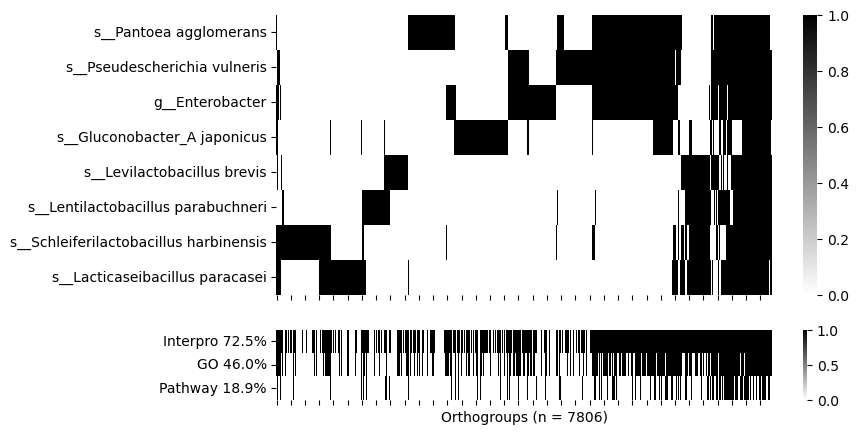

In [88]:
fig = plt.figure(figsize=(8, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[4,1])
ax = fig.add_subplot(gs[0])
df, _, _ = clustermap_reorder((orthogroup_counts.fillna(0) > 0).T.rename(index=mag2species))
df = df.astype(int)
sns.heatmap(df, cmap='gray_r')
ax.tick_params(labelbottom=False)

ax = fig.add_subplot(gs[1])
sns.heatmap(pd.concat([has_interpro, has_go, has_pway], axis=1).T.reindex(columns=df.columns), 
            cmap='gray_r')
ax.tick_params(labelbottom=False)
ax.set_xlabel(f'Orthogroups (n = {df.shape[1]})')
ax.set_yticklabels([f'{label} {cat.sum() / df.shape[1] * 100:.1f}%'
                    for cat, label in zip([has_interpro, has_go, has_pway], ['Interpro', 'GO', 'Pathway'])], rotation=0)
plt.savefig('./../data/figures/orthogroup_annotations.svg', bbox_inches='tight')

In [89]:
mag2interpro = (interpro_data.groupby(['genome', 'interpro_accession']).count()['protein_accession'].unstack().drop('-', axis=1).fillna(0).T > 0).astype(int)

In [90]:
mag2interpro.columns

Index(['g__Enterobacter', 's__Gluconobacter_A japonicus',
       's__Lacticaseibacillus paracasei', 's__Lentilactobacillus parabuchneri',
       's__Levilactobacillus brevis', 's__Pantoea agglomerans',
       's__Pseudescherichia vulneris',
       's__Schleiferilactobacillus harbinensis'],
      dtype='object', name='genome')

In [91]:
mag2interpro

genome,g__Enterobacter,s__Gluconobacter_A japonicus,s__Lacticaseibacillus paracasei,s__Lentilactobacillus parabuchneri,s__Levilactobacillus brevis,s__Pantoea agglomerans,s__Pseudescherichia vulneris,s__Schleiferilactobacillus harbinensis
interpro_accession,,,,,,,,
IPR000013,0,0,0,1,0,0,0,0
IPR000014,1,1,1,1,1,1,1,1
IPR000015,1,0,0,0,0,1,1,0
IPR000021,0,0,0,0,0,0,1,0
IPR000023,1,0,1,0,0,1,1,1
...,...,...,...,...,...,...,...,...
IPR046213,1,0,0,0,0,0,1,0
IPR046227,1,0,0,0,0,0,1,0
IPR046239,0,0,0,0,0,0,1,0


### Trying Fisher's Exact Test on interproscan terms

In [92]:
# presence_matrix: rows=domains, columns=genomes, values=0/1
# groups: dict mapping genome -> 'A' or 'B'

group_A_genomes = ['g__Enterobacter', 's__Pantoea agglomerans',
       's__Pseudescherichia vulneris', 's__Gluconobacter_A japonicus',]

group_B_genomes = [
       's__Lacticaseibacillus paracasei', 
       's__Lentilactobacillus parabuchneri',
       's__Levilactobacillus brevis', 
       's__Schleiferilactobacillus harbinensis']

results = []
for i, domain in enumerate(mag2interpro.index):
    if i % 50 == 0:
        display(i)
        clear_output(wait=True)
    a = mag2interpro.loc[domain, group_A_genomes].sum()
    c = len(group_A_genomes) - a
    b = mag2interpro.loc[domain, group_B_genomes].sum()
    d = len(group_B_genomes) - b
    odds, p = fisher_exact([[a, b], [c, d]])
    results.append((domain, a, b, odds, p))



8450

In [93]:
df = pd.DataFrame(results, columns=['domain','A_count','B_count','odds_ratio','pval'])
df['qval'] = multipletests(df['pval'], method='fdr_bh')[1]
df.sort_values('qval', inplace=True)
print((df['qval'] < 0.05).sum())

0


### Semantic orthogroup clustering

In [94]:
'''
semantic clustering of GO terms in shared orthologs
'''

# dict: go_id -> set of orthogroup ids
orthogroup2go = og2go.apply(lambda x: set(x[x > 0].index), axis=0).to_dict()

# TermCounts needs your actual GO-id -> orthogroup associations
# (this plays the role of the "corpus" for information content)
termcounts = TermCounts(godag, orthogroup2go)  

all_terms = sorted(set().union(*orthogroup2go.values()))

# Pairwise Lin similarity matrix (bounded 0-1, easier to interpret than Resnik)

n = len(all_terms)
sim_matrix = np.zeros((n, n))
for i, j in itertools.combinations(range(n), 2):
    s = lin_sim(all_terms[i], all_terms[j], godag, termcounts)
    sim_matrix[i, j] = sim_matrix[j, i] = s if s is not None else 0
np.fill_diagonal(sim_matrix, 1.0)

dist = 1 - sim_matrix
np.fill_diagonal(dist, 0)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method='average')

# Cut the tree to get, say, ~30-50 clusters
clusters = fcluster(Z, t=100, criterion='maxclust')

term2cluster = dict(zip(all_terms, clusters))

pd.Series(term2cluster).unique()

array([ 38,   2,  10,  55,  57,   4,  44,  47,  65,  23,  21,  54,  60,
        53,  25,   6,  39,   3,   9,  67,  40,   7,  46,  95,  94,  62,
        96,  61,  58,  43,  41,  97,  82,  87,  70,  72,  78,  80,  77,
        19,  24,  26,  15,  34,  18,  27,  32,  22,  14,  33,  31,   5,
        98,  20,  75,  71,  30,  83,  88,  79,  81,  89,  90,  91,  85,
        99,  68,  11,  50, 100,  29,  76,   1,  63,  56,  69,  13,  16,
        17,  51,  35,  74,  92,  37,  73,  86,  84,  48,   8,  36,  49,
        64,  93,  28,  42,  12,  45,  66,  59,  52], dtype=int32)

In [96]:
'''
what kinds of terms are in the clusters?
'''


cluster2desc = {}
cluster2goid = {}
for c in set(term2cluster.values()):
    # get cluster members
    members = [t for t, cl in term2cluster.items() if cl == c]
    
    # members = informative_terms(members, termcounts, len(all_terms), cutoff=0.3)
    # get representation: item with minimum distance

    # get most common names
    members_sorted = sorted(members, key=lambda t: -termcounts.gocnts[t])
    rep = members_sorted[0]
    print(f"--- Cluster {c} ---")
    print(c, godag[rep].name)
    cluster2desc[c] = f'{c}: {godag[rep].name}'
    cluster2goid[c] = rep
    
    for t in members_sorted[:10]:
        print(f"  {t}\t{godag[t].name}\t(n={termcounts.gocnts[t]})")

def get_namespace(go_id, godag):
    return godag[go_id].namespace  # 'biological_process', 'molecular_function', 'cellular_component'

groups_by_namespace = {"BP": [], "MF": [], "CC": []}
ns_map = {"biological_process": "BP", "molecular_function": "MF", "cellular_component": "CC"}
for c, go_id in cluster2goid.items():
    ns = ns_map[get_namespace(go_id, godag)]
    groups_by_namespace[ns].append(c)

--- Cluster 1 ---
1 viral process
  GO:0016032	viral process	(n=7)
  GO:0019069	viral capsid assembly	(n=5)
--- Cluster 2 ---
2 biological regulation
  GO:0065007	biological regulation	(n=385)
  GO:0050789	regulation of biological process	(n=373)
  GO:0050794	regulation of cellular process	(n=355)
  GO:0019222	regulation of metabolic process	(n=309)
  GO:0060255	regulation of macromolecule metabolic process	(n=307)
  GO:0080090	regulation of primary metabolic process	(n=303)
  GO:0031323	regulation of cellular metabolic process	(n=301)
  GO:0051171	regulation of nitrogen compound metabolic process	(n=301)
  GO:0010468	regulation of gene expression	(n=298)
  GO:0019219	regulation of nucleobase-containing compound metabolic process	(n=295)
--- Cluster 3 ---
3 developmental process
  GO:0032502	developmental process	(n=5)
  GO:0000902	cell morphogenesis	(n=3)
  GO:0009653	anatomical structure morphogenesis	(n=3)
  GO:0022611	dormancy process	(n=1)
  GO:0030154	cell differentiation	(n=1)
 

In [100]:
# orthogroup to cluster mapping
og2cluster = og2go.rename(index=term2cluster).unstack().reset_index().groupby(['level_0', 'level_1']).sum()[0].unstack()
# how many orthogroups in each cluster?
og2cluster.sum()

level_1
1        12.0
2      6268.0
3        17.0
4      4710.0
5        12.0
        ...  
96       12.0
97     1147.0
98     2509.0
99        1.0
100       2.0
Length: 100, dtype: float64

In [101]:
pd.Series(term2cluster)[pd.Series(term2cluster).eq(1)]

GO:0016032    1
GO:0019069    1
dtype: int32

In [1710]:
grouped = {
    "Core metabolism (BP)": [
        "25: nitrogen compound metabolic process",
        "24: carbohydrate metabolic process",
        "23: lipid metabolic process",
        "21: secondary metabolic process",
        "19: generation of precursor metabolites and energy",
        "28: ATP metabolic process",
        "26: tricarboxylic acid cycle",
        "20: sulfate assimilation",
        "22: nitrate metabolic process",
        "14: reactive oxygen species metabolic process",
    ],
    "General/regulatory processes (BP)": [
        "98: biological_process",
        "11: cellular process",
        "10: cellular component organization or biogenesis",
        "4: response to stimulus",
        "3: localization",
        "32: protein folding",
    ],
    "Cell cycle / division / development (BP)": [
        "9: cell cycle process",
        "12: cell division",
        "2: developmental process",
        "31: cell adhesion",
        "7: locomotion",
    ],
    "Host, symbiosis, defense, stress (BP)": [
        "6: biological process involved in symbiotic interaction",
        "5: viral process",
        "13: detoxification",
        "8: biofilm formation",
        "18: transposition, DNA-mediated",
    ],
    "Catalytic activity (MF)": [
        "95: molecular_function",
        "54: transferase activity",
        "57: hydrolase activity",
        "53: oxidoreductase activity",
        "60: catalytic activity, acting on a nucleic acid",
        "61: lyase activity",
        "62: isomerase activity",
        "58: ligase activity",
    ],
    "Binding activities (MF)": [
        "48: ion binding",
        "44: RNA binding",
        "43: protein binding",
        "46: iron-sulfur cluster binding",
        "47: sulfur compound binding",
        "45: glycosaminoglycan binding",
        "49: molybdopterin cofactor binding",
        "42: quinone binding",
        "40: lipid binding",
        "41: protein-containing complex binding",
    ],
    "Transport (MF)": [
        "65: transporter activity",
        "63: molecular carrier activity",
    ],
    "Regulatory / structural / signaling (MF)": [
        "67: transcription regulator activity",
        "39: molecular function regulator activity",
        "52: molecular transducer activity",
        "59: small molecule sensor activity",
        "94: structural molecule activity",
        "96: cytoskeletal motor activity",
        "64: protein folding chaperone",
    ],
    "Membranes / envelope (CC)": [
        "76: membrane",
        "77: plasma membrane",
        "75: outer membrane",
        "70: external encapsulating structure",
        "73: periplasmic space",
    ],
    "Cellular components / organelles / complexes (CC)": [
        "97: cellular_component",
        "78: cytoplasm",
        "72: organelle",
        "38: protein-containing complex",
        "71: cell projection",
        "79: bacterial-type flagellum hook",
        "69: host cellular component",
    ],
}

In [1711]:
ordering = []
for group_label, cluster_list in groups_by_namespace.items():
    ordering += cluster_list # [d for d in df.columns if d in cluster_list]
    
    
ordering2 = []
for group_label, cluster_list in grouped.items():
    clusters_reformat = [int(c.split(':')[0]) for c in cluster_list]
    ordering2 += clusters_reformat #[d for d in df.columns if d in clusters_reformat]


In [1712]:
len(ordering)

100

In [1713]:
(orthogroup_counts > 0).T.dot(og2cluster.loc[:, 26]).rename(mag2species)

s__Pantoea agglomerans                    15.0
s__Pseudescherichia vulneris              16.0
g__Enterobacter                           16.0
s__Gluconobacter_A japonicus               7.0
s__Levilactobacillus brevis                2.0
s__Schleiferilactobacillus harbinensis     2.0
s__Lentilactobacillus parabuchneri         6.0
s__Lacticaseibacillus paracasei            5.0
dtype: float64

In [1714]:
mag2species.values

array(['s__Gluconobacter_A japonicus', 's__Lacticaseibacillus paracasei',
       's__Schleiferilactobacillus harbinensis', 's__Pantoea agglomerans',
       's__Levilactobacillus brevis', 's__Pseudescherichia vulneris',
       'g__Enterobacter', 's__Lentilactobacillus parabuchneri'],
      dtype=object)

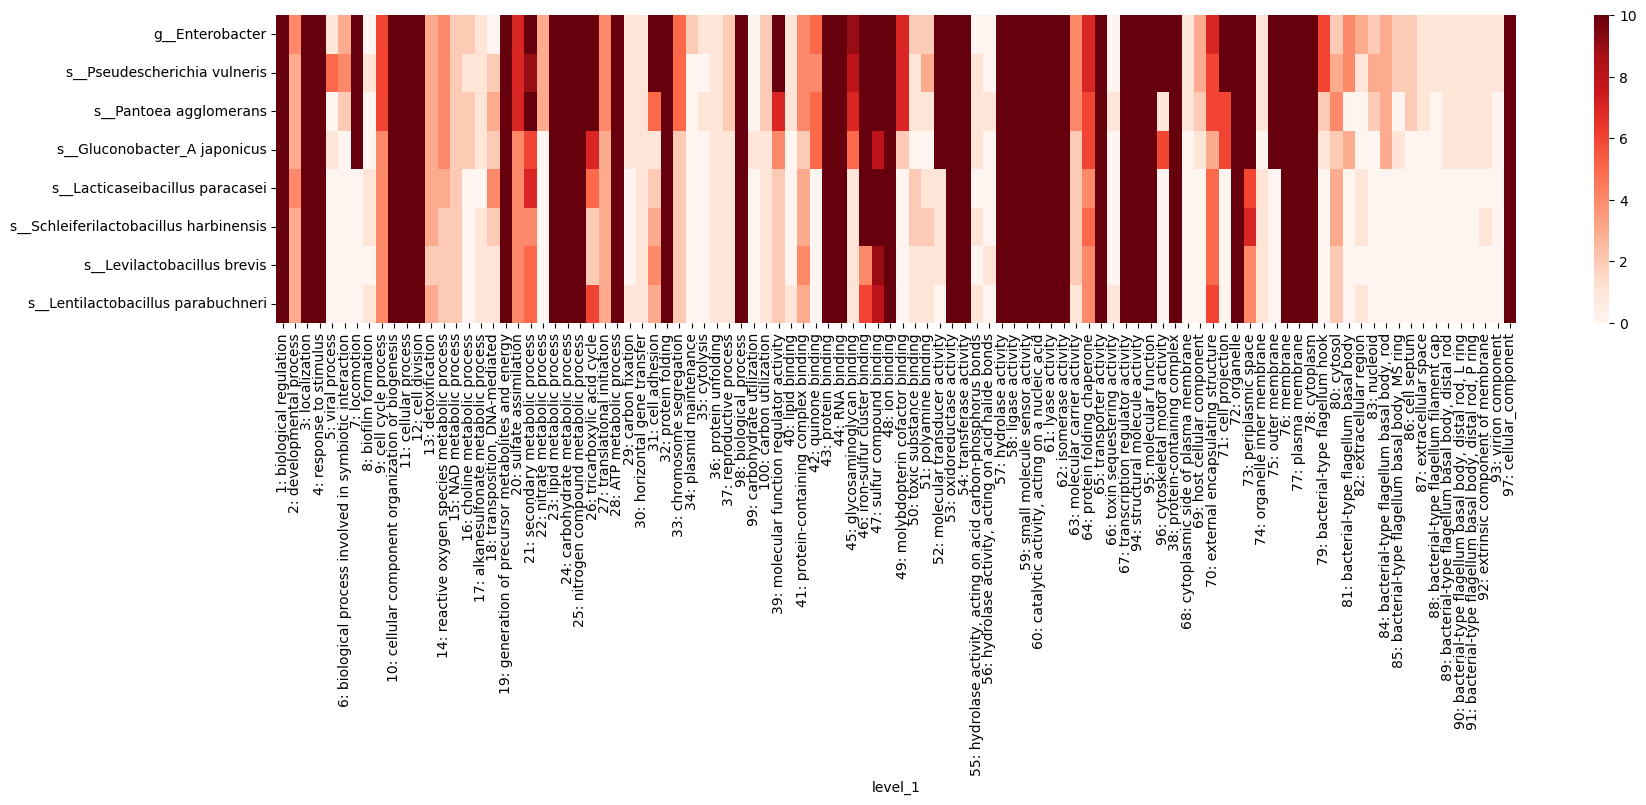

In [1715]:
fig = plt.figure(figsize=(20, 4))
ax = fig.add_subplot(1,1,1)
# mag2cluster, _, _ = clustermap_reorder(((orthogroup_counts > 0).astype(int).T.dot(og2cluster).apply(np.log10)).rename(index=mag2species))
mag2cluster, _, _ = clustermap_reorder((orthogroup_counts > 0).astype(int).T.dot((og2cluster > 0).astype(int)).rename(index=mag2species))
y_order = ['g__Enterobacter','s__Pseudescherichia vulneris', 's__Pantoea agglomerans', 
           's__Gluconobacter_A japonicus', 
           's__Lacticaseibacillus paracasei',
           's__Schleiferilactobacillus harbinensis', 
           's__Levilactobacillus brevis', 
            's__Lentilactobacillus parabuchneri']
sns.heatmap(mag2cluster.reindex(columns=ordering, index=y_order), xticklabels=True, ax=ax, cmap='Reds', vmax=10)
# xticklabels = ax.set_xticklabels([cluster2desc[c] for c in mag2cluster])
xticklabels = ax.set_xticklabels([cluster2desc[c] for c in ordering])
plt.savefig('./../data/figures/go_semantic_heatmap.svg', bbox_inches='tight')

In [1716]:
og2cluster.sum(0)

level_1
1      6268.0
2        17.0
3      4710.0
4       919.0
5        12.0
        ...  
96       12.0
97     1147.0
98     2509.0
99        1.0
100       2.0
Length: 100, dtype: float64

In [1717]:
ortho_cluster_plotdf = pd.merge(ortho_plotdf, og2cluster.loc[:, og2cluster.sum(0) > 5] > 0, left_index=True, right_index=True)
print(ortho_cluster_plotdf.shape)
ortho_cluster_plotdf.head(2)

(6528, 71)


,index,mag,count,group,diff,1,2,3,4,5,...,75,76,77,78,79,94,95,96,97,98
OG0000000,2834,UO5-1_MAG_01,22.0,shared,-2.0,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
OG0000000,6527,UO5-1_MAG_02,20.0,shared,-2.0,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [1718]:
ortho_plotdf

,index,mag,count,group,diff
orthogroup,,,,,
OG0002190,0,UO5-1_MAG_01,1.0,s__Pseudescherichia vulneris,-1.0
OG0003968,1,UO5-1_MAG_01,2.0,s__Pseudescherichia vulneris,-2.0
OG0003962,2,UO5-1_MAG_01,2.0,s__Pseudescherichia vulneris,-2.0
OG0003956,3,UO5-1_MAG_01,2.0,s__Pseudescherichia vulneris,-2.0
OG0003928,4,UO5-1_MAG_01,2.0,s__Pseudescherichia vulneris,-2.0
...,...,...,...,...,...
OG0001598,6523,UO5-1_MAG_01,1.0,shared,0.0
OG0001598,6524,UO5-1_MAG_02,1.0,shared,0.0
OG0001597,6525,UO5-1_MAG_01,1.0,shared,0.0


In [1719]:

# cluster orthogroups
def clustermap_reorder(data, method="average", metric="euclidean"):
    """Minimal replica of seaborn.clustermap's row/col clustering."""
    row_linkage = linkage(pdist(data.values, metric=metric), method=method)
    col_linkage = linkage(pdist(data.values.T, metric=metric), method=method)

    row_order = dendrogram(row_linkage, no_plot=True)["leaves"]
    col_order = dendrogram(col_linkage, no_plot=True)["leaves"]

    return data.iloc[row_order, :].iloc[:, col_order], row_linkage, col_linkage


In [1720]:

new_row_orders = []
new_col_orders = []
# cluster within groups
for group in ortho_cluster_plotdf['group'].unique():
    df, row_linkage, col_linkage = clustermap_reorder(ortho_cluster_plotdf[ortho_cluster_plotdf['group'].eq(group)].iloc[:, 6:])
    new_row_orders.append(pd.Series(index=df.index, data=list(range(len(df)))))

In [1721]:
new_row_orders = pd.concat(new_row_orders).sort_index()

<Axes: >

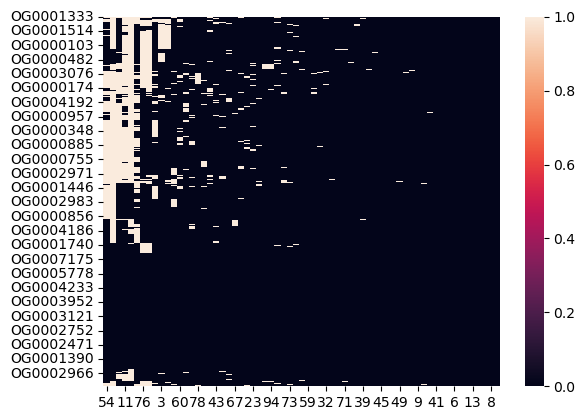

In [1722]:
df, _, _ = clustermap_reorder(ortho_cluster_plotdf.iloc[:, 6:])
sns.heatmap(df)

In [1723]:
df.shape

(6528, 65)

In [1724]:
new_row_orders

OG0000000    2534
OG0000000    2535
OG0000001    4456
OG0000001    4457
OG0000002    4932
             ... 
OG0007787     222
OG0007790      49
OG0007800     221
OG0007802     142
OG0007805     119
Length: 6528, dtype: int64

In [1725]:
ortho_cluster_plotdf['secondary_order'] = new_row_orders
ortho_cluster_plotdf = ortho_cluster_plotdf.sort_values(['group', 'secondary_order'])
ortho_cluster_plotdf['secondary_order_int'] = list(range(len(ortho_cluster_plotdf)))
ortho_cluster_plotdf

,index,mag,count,group,diff,1,2,3,4,5,...,77,78,79,94,95,96,97,98,secondary_order,secondary_order_int
OG0002203,867,UO5-1_MAG_02,1.0,g__Enterobacter,1.0,False,False,False,False,False,...,True,False,False,False,True,False,True,True,0,0
OG0002221,1033,UO5-1_MAG_02,1.0,g__Enterobacter,1.0,False,False,False,False,False,...,True,False,False,False,True,False,True,True,1,1
OG0006587,1296,UO5-1_MAG_02,1.0,g__Enterobacter,1.0,False,False,False,False,False,...,False,True,False,False,True,False,True,True,2,2
OG0000789,859,UO5-1_MAG_02,2.0,g__Enterobacter,2.0,False,False,True,False,False,...,False,False,False,False,True,False,True,True,3,3
OG0001262,759,UO5-1_MAG_02,1.0,g__Enterobacter,1.0,False,False,True,False,False,...,False,False,False,False,True,False,True,True,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OG0000066,2798,UO5-1_MAG_02,3.0,shared,-1.0,True,False,False,False,False,...,False,False,False,True,True,False,True,True,5209,6523
OG0000003,2840,UO5-1_MAG_01,15.0,shared,4.0,True,False,False,False,False,...,False,True,False,False,True,False,True,True,5210,6524
OG0000003,2839,UO5-1_MAG_02,19.0,shared,4.0,True,False,False,False,False,...,False,True,False,False,True,False,True,True,5211,6525
OG0002157,5214,UO5-1_MAG_02,1.0,shared,-2.0,False,False,False,True,False,...,False,False,False,False,True,False,True,True,5212,6526


In [1726]:
# subset to genes with different copy numbers
subset_plotdf = ortho_cluster_plotdf.loc[(ortho_cluster_plotdf['diff'].apply(np.abs) > 0), :]

subset_plotdf = subset_plotdf.sort_values(['group', 'secondary_order_int'])

temp = subset_plotdf.iloc[:, 5:-2].sum() == 0
temp[temp].index
subset_plotdf = subset_plotdf.drop(temp[temp].index, axis=1)
subset_plotdf = subset_plotdf.loc[subset_plotdf.iloc[:, 5:-2].sum(1) != 0, :]

# resort
subset_plotdf['secondary_order_int'] = list(range(len(subset_plotdf)))

# fill heatmap with diffs  
for index, row in subset_plotdf.iterrows():
    subset_plotdf.loc[index, :] = row.replace({True:row['diff']}).values

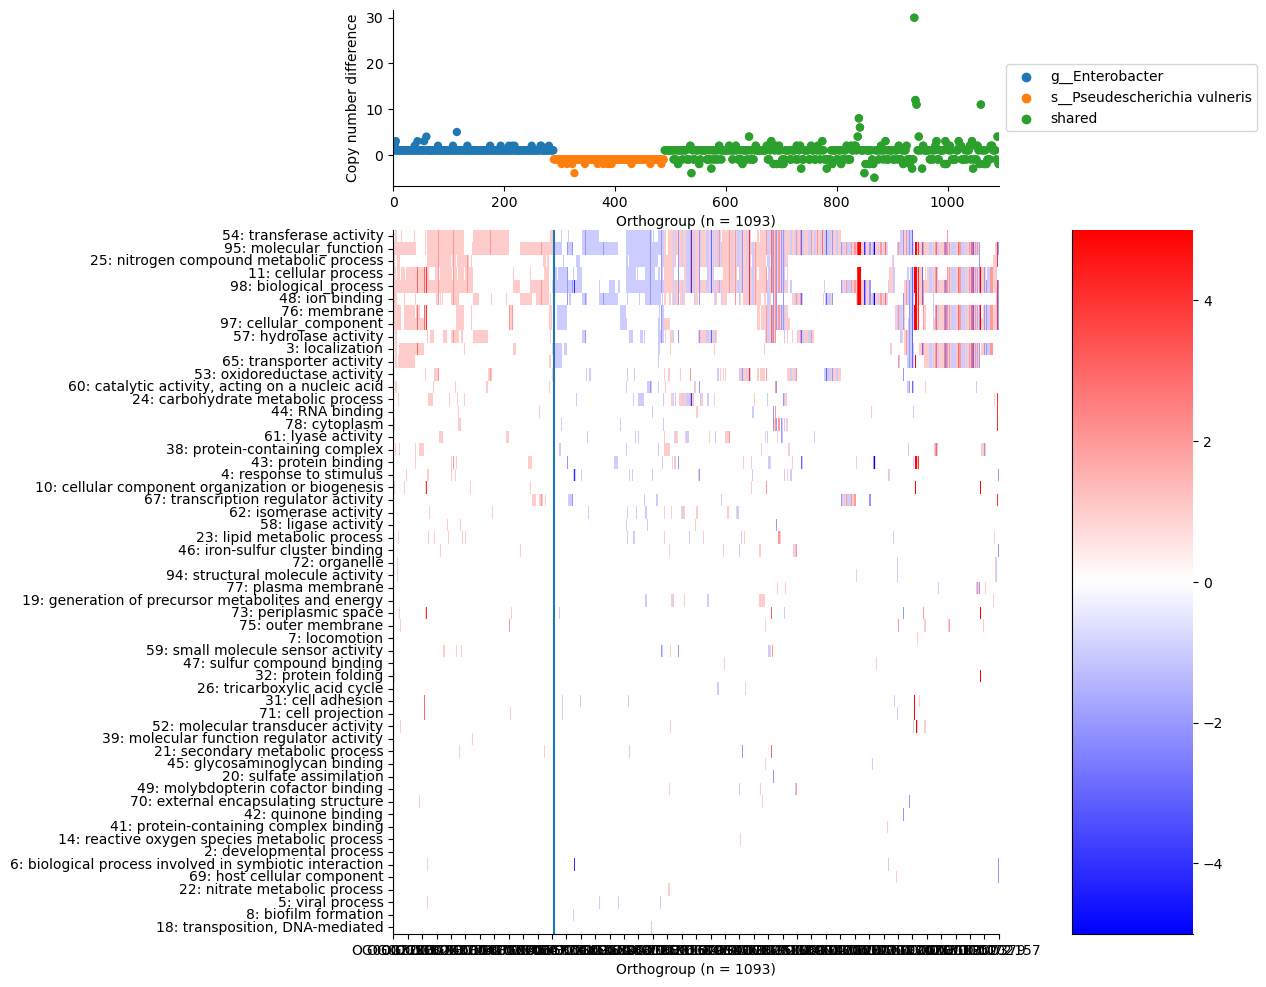

In [1730]:
# og2pway_plotdf, _, _ = clustermap_reorder(og2pway_wide.T)

fig = plt.figure(figsize=(8,12))

gs = fig.add_gridspec(2, 2, width_ratios=[5,1], height_ratios=[1, 4], left=0, right=1, )


ax2 = fig.add_subplot(gs[0, 0])
sns.scatterplot(data=subset_plotdf,
            x='secondary_order_int', hue='group', y='diff', linewidth=0)

# ax2 = fig.add_subplot(gs[1, 0], sharex=ax)
# sns.stripplot(data=ortho_cluster_plotdf,
#             x='index', hue='group', y='diff', linewidth=0)
ax2.set_xlim(0, len(subset_plotdf))
lgd = ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.set_ylabel('Copy number difference')
ax2.set_xlabel(f'Orthogroup (n = {len(subset_plotdf)})')
sns.despine()

ax = fig.add_subplot(gs[1, 0])
cax = fig.add_subplot(gs[1, 1])
yorder = [i for i in df.columns if i in subset_plotdf.columns] 
sns.heatmap(subset_plotdf.iloc[:, 5:].astype(int).drop(['secondary_order', 'secondary_order_int'], axis=1).T.reindex(index=yorder), 
            yticklabels=True, linecolor='k',
            ax=ax, cbar_ax = cax, cmap='bwr', center=0, vmin=-5, vmax=5)
ax.set_xlabel(f'Orthogroup (n = {len(subset_plotdf)})')
ax.set_yticklabels([cluster2desc[c] for c in yorder])
temp = subset_plotdf.reset_index()

for line in temp[temp['secondary_order'].eq(0)].index:
    ax.axvline(line)
sns.despine()
ax.tick_params(rotation=0)

# ax = fig.add_subplot(gs[1, 0])
# cax = fig.add_subplot(gs[1, 1])


# temp = og2pway_plotdf.reindex(columns=subset_plotdf.index)

# sns.heatmap(temp[temp.fillna(0).sum(1) >= 1], ax=ax, cbar_ax=cax, cmap='gray_r')
# ax.set_yticklabels([pway2levels.loc[i.get_text(), 'h_4'] for i in ax.get_yticklabels()])
# ax.set_xlabel(f'Orthogroup (n = {len(subset_plotdf)})')
# # ax.set_yticklabels([cluster2desc[c] for c in ordering2])
# # temp = ortho_cluster_plotdf.reset_index()

# # for line in temp[temp['secondary_order'].eq(0)].index:
# #     ax.axvline(line)
sns.despine()
ax.tick_params(rotation=0)



plt.tight_layout()
fig.subplots_adjust(hspace=0.1)
# plt.savefig('./../data/figures/enterobacter_pangenome.svg', bbox_inches='tight')

In [1635]:
gene_ids = seq2genome[seq2genome.eq('UO5-1_MAG_02')].index
df = make_geneloc_df(gene_ids)

In [1638]:
gene2ortho

NODE_109_length_67898_cov_219.537226_2      OG0000000
NODE_116_length_66745_cov_21.370310_23      OG0000000
NODE_119_length_66354_cov_24.413385_1       OG0000000
NODE_119_length_66354_cov_24.413385_13      OG0000000
NODE_119_length_66354_cov_24.413385_25      OG0000000
                                              ...    
NODE_25_length_157474_cov_25.670599_37      OG0007801
NODE_15_length_297527_cov_115.807568_143    OG0007802
NODE_73_length_61317_cov_13.789739_12       OG0007803
NODE_40_length_100009_cov_13.814565_45      OG0007804
NODE_16_length_269207_cov_283.449646_84     OG0007805
Length: 24653, dtype: object

In [1643]:
# summaries = Series
for og in subset_plotdf[subset_plotdf['diff'] > 2].index.unique():
    print(og)
    temp = og2interpro.loc[:, og]
    if (temp > 0).sum() > 0:
        summary = summarize_interpro(interpro2desc.loc[temp[temp > 0].index.values])
        print(summary)
        # print(gene2ortho[gene2ortho.eq(og)])
        print()

OG0000932
ABC transporter-like

OG0001382
Single hybrid motif

OG0003208
Fimbrial-type adhesion domain

OG0002167
Immunoglobulin-like fold

OG0001505
Glycoside hydrolase superfamily

OG0000458
Filamentous haemagglutinin

OG0000151
Aldehyde dehydrogenase

OG0000492
Beta-lactamase/transpeptidase-like

OG0000145
GNAT domain

OG0000361
Signal transduction response regulator

OG0000214
Signal transduction response regulator

OG0000052
Signal transduction response regulator

OG0000839
Gfo/Idh/MocA-like oxidoreductase

OG0000461
RmlC-like jelly roll fold

OG0000288
Rhs repeat-associated core

OG0000286
Hcp1-like superfamily

OG0000017
YdgH/BhsA/McbA-like domain

OG0000008
Fimbrial-type adhesion domain

OG0000076
PapC-like

OG0000001
Nucleotide cyclase

OG0000006
Nucleotide cyclase

OG0000038
RND efflux pump

OG0000032
ABC transporter

OG0000838
MFS transporter superfamily

OG0000035
MFS transporter superfamily

OG0000056
Pili assembly chaperone

OG0000003
Transcription regulator HTH



### Pathway stuff

In [1636]:
subset_plotdf.head(2)

,index,mag,count,group,diff,1,2,3,4,5,...,73,75,76,77,78,95,97,98,secondary_order,secondary_order_int
OG0002203,867,UO5-1_MAG_02,1.0,g__Enterobacter,1.0,False,False,False,False,False,...,False,False,1.0,1.0,False,1.0,1.0,1.0,0,0
OG0002221,1033,UO5-1_MAG_02,1.0,g__Enterobacter,1.0,False,False,False,False,False,...,False,False,1.0,1.0,False,1.0,1.0,1.0,1,1


In [1637]:
interpro_data.score.head(2)

0     2.1E-15
1    8.29E-71
Name: score, dtype: object

In [674]:
temp = og2pway_wide.reindex(index=ortho_cluster_plotdf[ortho_cluster_plotdf['diff'].apply(np.abs) > 3].index)

In [679]:
temp.loc[:, temp.sum() > 0].dropna()

,12DICHLORETHDEG-PWY,14DICHLORBENZDEG-PWY,2PHENDEG-PWY,3-HYDROXYPHENYLACETATE-DEGRADATION-PWY,4-HYDROXYMANDELATE-DEGRADATION-PWY,4TOLCARBDEG-PWY,ANAPHENOXI-PWY,ARGDEG-IV-PWY,BETA-ALA-DEGRADATION-I-PWY,BETSYN-PWY,...,PWY0-1317,PWY0-1477,PWY0-461,PWY1F-353,PWY66-161,PWY66-162,PWY66-21,TOLSULFDEG-PWY,TOLUENE-DEG-CATECHOL-PWY,VALDEG-PWY
OG0001505,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000151,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
OG0000151,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
OG0000214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OG0000006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [680]:
metacyc_pwys

,id,name,altname,hierarchy,taxrange,reaId,reaEc,keyRea,reaName,reaNr,ecNr,superpathway,status,spont,parsed_h,h_1,h_2,h_3,h_4
0,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","1,2-dichloroethane degradation","|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pat...",|TAX-2|,"DHLAXANAU-RXN,MOXXANAU-RXN,ALDXANAU-RXN,DHLBXA...","3.8.1.5,1.1.2.7,1.2.1.4,3.8.1.3",DHLAXANAU-RXN,"1,2-dichloroethane dehalogenase;2-chloroethano...",4,4,False,True,NaN,"[Degradation, CHLORINATED-COMPOUNDS-DEG]",Degradation,CHLORINATED-COMPOUNDS-DEG,CHLORINATED-COMPOUNDS-DEG,CHLORINATED-COMPOUNDS-DEG
1,|14DICHLORBENZDEG-PWY|,"1,4-dichlorobenzene degradation","1,4-dichlorobenzene degradation","|CHLORINATED-COMPOUNDS-DEG|,|THINGS|,|FRAMES|,...",|TAX-1224|,"DIOXYXANFL-RXN,CHLOROBENDDH-RXN,CHLOROCATDIOXY...","1.14.12.26,1.3.1.119,1.13.11.M6,3.1.1.45,1.3.1...","DIOXYXANFL-RXN,CHLOROBENDDH-RXN","1,4-dichlorobenzene dioxygenase;1,4-dichlorobe...",9,7,False,True,"RXN-18361,RXN-18362","[CHLORINATED-COMPOUNDS-DEG, Degradation, AROMA...",CHLORINATED-COMPOUNDS-DEG,Degradation,AROMATIC-COMPOUNDS-DEGRADATION,Chloroaromatic-Compounds-Degradation
2,|1CMET2-PWY|,folate transformations III (E. coli),"folate transformations III (<i>E. coli</i>),<i...","|Vitamin-Biosynthesis|,|THINGS|,|FRAMES|,|Gene...","|TAX-4751|,|TAX-33208|,|TAX-2|","DIHYDROFOLATEREDUCT-RXN,5-FORMYL-THF-CYCLO-LIG...","1.5.1.3,6.3.3.2,1.5.1.20,2.1.1.13,1.4.1.f,3.5....",NaN,dihydrofolate reductase;5-formyltetrahydrofola...,9,9,False,True,NaN,"[Vitamin-Biosynthesis, Biosynthesis, Cofactor-...",Vitamin-Biosynthesis,Biosynthesis,Cofactor-Biosynthesis,Carriers-Biosynthesis
3,|2AMINOBENZDEG-PWY|,anthranilate degradation III (anaerobic),"anthranilate degradation III (anaerobic),2-ami...","|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pat...",|TAX-1224|,"AMINOBENZCOALIG-RXN,AMBENCOATHAUERA-RXN","6.2.1.32,",NaN,2-aminobenzoate-CoA ligase;2-aminobenzoyl-CoA ...,2,1,False,True,NaN,"[Degradation, AROMATIC-COMPOUNDS-DEGRADATION, ...",Degradation,AROMATIC-COMPOUNDS-DEGRADATION,2-Aminobenzoate-Degradation,2-Aminobenzoate-Degradation
4,|2ASDEG-PWY|,orthanilate degradation,"orthanilate degradation,2-aminobenzenesulfonat...","|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pat...",|TAX-1224|,"2ASDOSALCAL-RXN,3SC23OALCAL-RXN,3SC23OSPON-RXN...","1.14.12.14,1.13.11,,5.3.2.6,4.1.1.77",NaN,"2-aminobenzenesulfonate,NADH:oxygen oxidoreduc...",5,4,False,True,3SC23OSPON-RXN,"[Degradation, AROMATIC-COMPOUNDS-DEGRADATION]",Degradation,AROMATIC-COMPOUNDS-DEGRADATION,AROMATIC-COMPOUNDS-DEGRADATION,AROMATIC-COMPOUNDS-DEGRADATION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3236,|URDEGR-PWY|,superpathway of allantoin degradation in plants,superpathway of allantoin degradation in plant...,"|Super-Pathways|,|THINGS|,|FRAMES|,|Generalize...",|TAX-33090|,"ALLANTOINASE-RXN,ALLANTOICASE-RXN,UREIDOGLYCOL...","3.5.2.5,3.5.3.4,4.3.2.3,3.5.2.5,3.5.3.4,3.5.2....",NaN,allantoinase;allantoicase;ureidoglycolate lyas...,14,14,True,True,NaN,"[Super-Pathways, Degradation, AMINE-DEG, Allan...",Super-Pathways,Degradation,AMINE-DEG,Allantoin-degradation
3237,|URSIN-PWY|,ureide biosynthesis,"ureide biosynthesis,ureide biogenesis","|Super-Pathways|,|THINGS|,|FRAMES|,|Generalize...",|TAX-3803|,"IMP-DEHYDROG-RXN,XMPXAN-RXN,XANTHOSINEPHOSPHOR...","1.1.1.205,3.1.3.5,2.4.2.1,1.17.1.4,1.7.3.3,4.1...",URATE-OXIDASE-RXN,IMP dehydrogenase;XMPXAN-RXN;purine nucleoside...,7,7,True,True,NaN,"[Super-Pathways, Biosynthesis, Polyamine-Biosy...",Super-Pathways,Biosynthesis,Polyamine-Biosynthesis,Polyamine-Biosynthesis
3238,|VALDEG-PWY|,L-valine degradation I,L-valine degradation I,"|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pat...","|TAX-2759|,|TAX-201174|,|TAX-1224|,|TAX-1239|","BRANCHED-CHAINAMINOTRANSFERVAL-RXN,MEPROPCOA-F...","2.6.1.42,1.3.8.5,4.2.1.17,3.1.2.4,1.1.1.31,1.2...",NaN,L-valine:2-oxoglutarate aminotransferase;isobu...,8,8,False,True,NaN,"[Degradation, Amino-Acid-Degradation, Proteino...",Degradation,Amino-Acid-Degradation,Proteinogen

In [672]:
ortho_cluster_plotdf[ortho_cluster_plotdf['diff'].apply(np.abs) > 3].index

Index(['OG0002167', 'OG0001505', 'OG0001476', 'OG0000816', 'OG0000816',
       'OG0000151', 'OG0000151', 'OG0000361', 'OG0000361', 'OG0000214',
       'OG0000214', 'OG0000052', 'OG0000052', 'OG0000310', 'OG0000310',
       'OG0000556', 'OG0000556', 'OG0000076', 'OG0000076', 'OG0000001',
       'OG0000001', 'OG0000006', 'OG0000006', 'OG0000008', 'OG0000008',
       'OG0000056', 'OG0000056', 'OG0000003', 'OG0000003'],
      dtype='object')

In [583]:
(og2cluster.loc[:, [int(i.split(':')[0]) for i in grouped['Core metabolism (BP)']]].sum(1) > 0)

level_0
OG0000000    False
OG0000001    False
OG0000002    False
OG0000003     True
OG0000004    False
             ...  
OG0007801    False
OG0007802    False
OG0007803    False
OG0007804    False
OG0007805    False
Length: 7806, dtype: bool

In [707]:
og2taxa_plotdf, _, _ = clustermap_reorder((orthogroup_counts.rename(columns=mag2species).fillna(0).loc[(og2cluster.loc[:, [int(i.split(':')[0]) for i in grouped['Membranes / envelope (CC)']]].sum(1) > 0),
                                :] > 0).T)

In [791]:
og2pway_wide.shape

(1476, 1689)

In [709]:
og2taxa_plotdf.shape

(8, 1054)

In [704]:
pway_order = [i.lstrip('|').rstrip('|') for i in metacyc_pwys.sort_values(['h_1', 'h_2', 'h_3', 'h_4'])['id'].values]

In [756]:
og_plotdf, _, _ = clustermap_reorder(orthogroup_counts.rename(columns=mag2species).fillna(0).T > 0)

In [767]:
og_plotdf.sum(0).eq(1)

OG0000847    False
OG0001304    False
OG0001352    False
OG0000600    False
OG0000855    False
             ...  
OG0000142    False
OG0000108    False
OG0000109    False
OG0001231    False
OG0001234    False
Length: 7806, dtype: bool

In [770]:
og_plotdf.loc[:, og_plotdf.sum(0).eq(1)]

,OG0007798,OG0007792,OG0007789,OG0007785,OG0007782,OG0007778,OG0007765,OG0007764,OG0007755,OG0007751,...,OG0003180,OG0003179,OG0003178,OG0003177,OG0003176,OG0003175,OG0003174,OG0003173,OG0001502,OG0001503
s__Pantoea agglomerans,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
s__Pseudescherichia vulneris,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
g__Enterobacter,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
s__Gluconobacter_A japonicus,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
s__Levilactobacillus brevis,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
s__Lentilactobacillus parabuchneri,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
s__Schleiferilactobacillus harbinensis,True,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
s__Lacticaseibacillus paracasei,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [1083]:
temp = (og2cluster.T.reindex(columns=og_plotdf.columns,
                                index=[26]) > 0).T
temp.sort_values(26) #[temp[26].eq(True)]

level_1,26
OG0000847,False
OG0002988,False
OG0002989,False
OG0002990,False
OG0002991,False
...,...
OG0002534,True
OG0001630,True
OG0002533,True
OG0002532,True


<Axes: ylabel='level_1'>

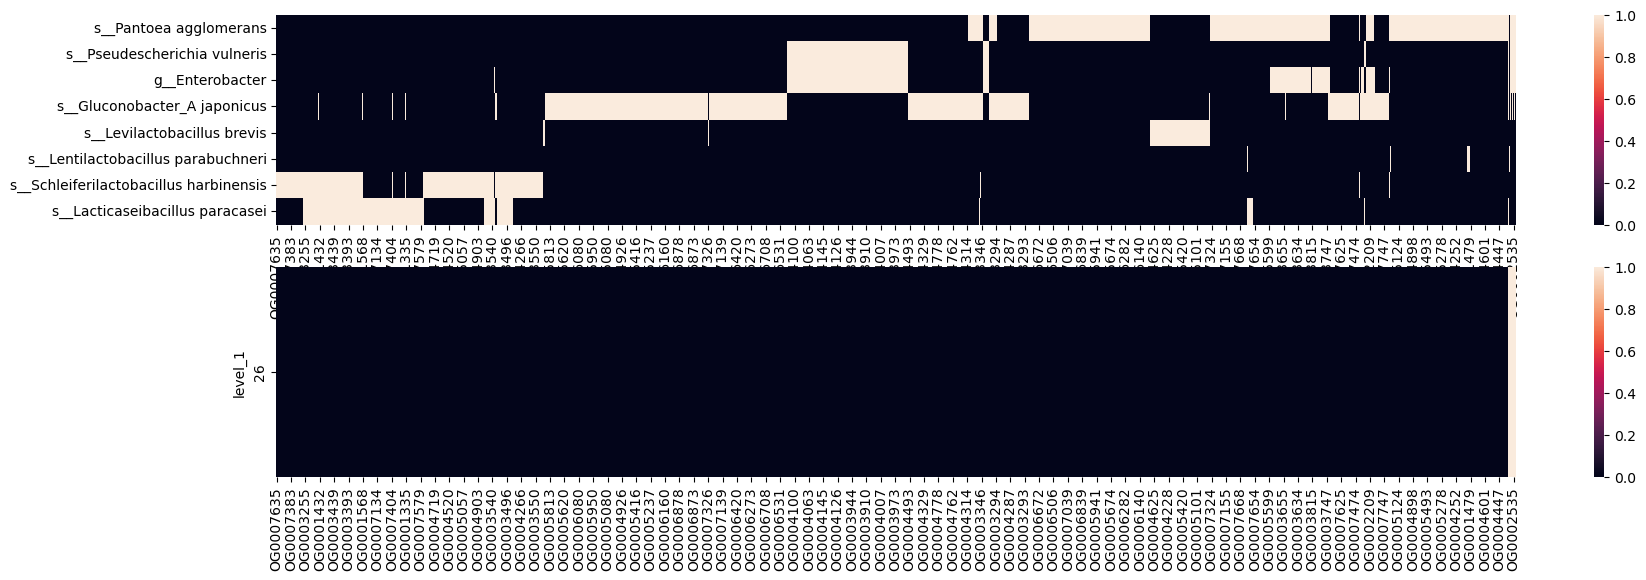

In [1086]:
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(2,1,1)
sns.heatmap(og_plotdf.loc[:, temp.sort_values(26).tail(2500).index] > 0)

ax = fig.add_subplot(2,1,2)
sns.heatmap((og2cluster.T.reindex(columns=og_plotdf.columns,
                                index=[26]).loc[:, temp.sort_values(26).tail(2500).index]))



In [1077]:
(og2cluster.T.reindex(columns=og_plotdf.columns,
                                index=[26]) > 0).sum().sum()

17

In [1066]:
(og2go.sum() > 0).sum()

3594

In [1068]:
(og2interpro.sum() > 0).sum()

5662

In [1078]:
og_plotdf

,OG0000847,OG0001304,OG0001352,OG0000600,OG0000855,OG0001672,OG0001265,OG0001512,OG0003732,OG0002238,...,OG0000465,OG0000463,OG0000300,OG0000294,OG0000274,OG0000142,OG0000108,OG0000109,OG0001231,OG0001234
s__Pantoea agglomerans,True,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
s__Pseudescherichia vulneris,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
g__Enterobacter,True,True,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
s__Gluconobacter_A japonicus,True,True,True,True,True,True,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
s__Levilactobacillus brevis,False,False,True,True,True,False,False,False,True,True,...,True,True,True,True,True,True,True,True,True,True
s__Lentilactobacillus parabuchneri,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
s__Schleiferilactobacillus harbinensis,True,True,True,True,True,True,True,True,False,False,...,True,True,True,True,True,True,True,True,True,True
s__Lacticaseibacillus paracasei,True,True,True,True,True,True,True,True,False,False,...,True,True,True,True,True,True,True,True,False,False


In [1057]:
og_plotdf.sum(0).eq(1)

OG0000847    False
OG0001304    False
OG0001352    False
OG0000600    False
OG0000855    False
             ...  
OG0000142    False
OG0000108    False
OG0000109    False
OG0001231    False
OG0001234    False
Length: 7806, dtype: bool

In [ ]:
temp = (orthogroup_counts.rename(columns=mag2species).loc[:, 's__Schleiferilactobacillus harbinensis'].fillna(0) == orthogroup_counts.rename(columns=mag2species).sum(1))


OG0000303    True
OG0000455    True
OG0000456    True
OG0001462    True
OG0002037    True
             ... 
OG0007782    True
OG0007785    True
OG0007789    True
OG0007792    True
OG0007798    True
Length: 558, dtype: bool

<Axes: xlabel='index', ylabel='0'>

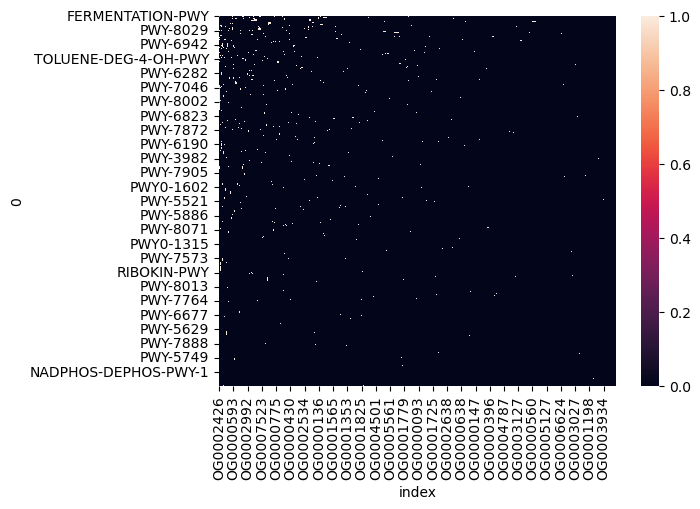

In [638]:
sns.heatmap(og2pway_plotdf)

In [639]:
og2pway_plotdf.sum(1)

0
FERMENTATION-PWY    34.0
PWY-8086            27.0
PWY-101             30.0
P3-PWY              31.0
P162-PWY            30.0
                    ... 
CITRULBIO-PWY       12.0
PWY-3081            15.0
GLUTORN-PWY          7.0
ARGSYNBSUB-PWY      11.0
PWY-5154            13.0
Length: 1689, dtype: float64

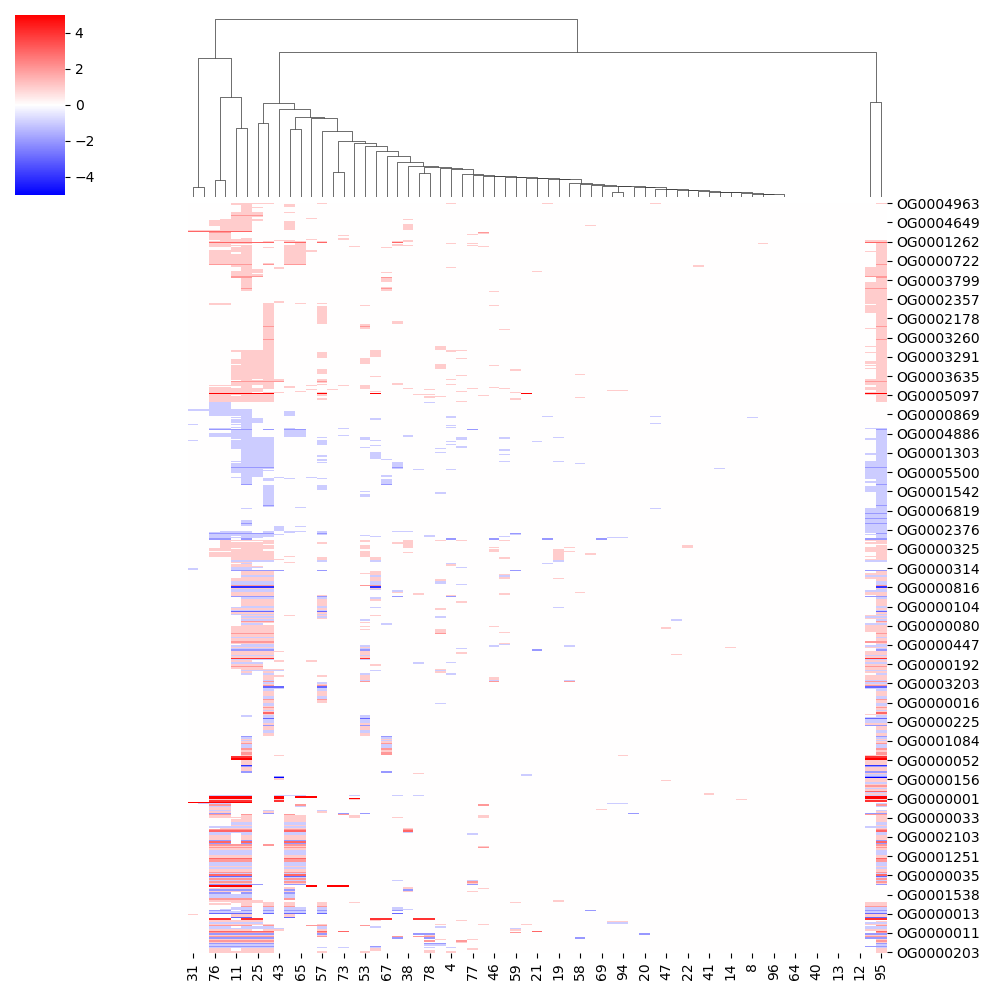

In [570]:
sns.clustermap(subset_plotdf.iloc[:, 6:-2].astype(int), cmap='bwr', center=0, vmax=5, row_cluster=False)

### Alternate view

In [102]:
def get_unique_orthos(og_counts, mag_id_1, mag_id_2):
    '''
    given a table of orthogroups x mags, 
    get ortho groups unique to mag_id
    '''
    counts = og_counts.loc[(og_counts.loc[:, [mag_id_1, mag_id_2]] > 0).sum(1) > 0, :]
    temp = (counts.loc[:, [mag_id_1, mag_id_2]].sum(1) == counts.loc[:, mag_id_1])
    return list(temp[temp].index)

In [103]:
# ortho_cluster_plotdf[~ortho_cluster_plotdf.group.eq('shared')].groupby('group').sum().iloc[:, 3:-2].stack().reset_index()

# temp = ortho_cluster_plotdf[~ortho_cluster_plotdf.group.eq('shared')].groupby('group').sum().iloc[:, 3:-2]
# diffplot = (temp.iloc[0, :] - temp.iloc[1, :]).rename('diff')

In [107]:
tax1 = 's__Schleiferilactobacillus harbinensis'
tax2 = 's__Lacticaseibacillus paracasei'

orthos1 = get_unique_orthos(orthogroup_counts,   tax1, tax2)
orthos2 = get_unique_orthos(orthogroup_counts,   tax2, tax1)
# check dot product for cluster 1
temp = (og2cluster > 0).loc[:, 2]
orthogroup_counts.T.loc[tax1, temp[temp & temp.index.isin(orthos1 + orthos2)].index].sum()

57.0

In [108]:
orthogroup_counts.T.loc[tax1, temp[temp & temp.index.isin(orthos1)].index] # .sum()

level_0
OG0000001    2.0
OG0000003    1.0
OG0000006    1.0
OG0000112    5.0
OG0000218    8.0
OG0000466    1.0
OG0000468    2.0
OG0000486    2.0
OG0000824    1.0
OG0000825    1.0
OG0001050    1.0
OG0001054    1.0
OG0001098    3.0
OG0001229    2.0
OG0001269    1.0
OG0001278    1.0
OG0001461    1.0
OG0001466    1.0
OG0001519    1.0
OG0001569    1.0
OG0002043    2.0
OG0002385    3.0
OG0003217    2.0
OG0003551    1.0
OG0004337    1.0
OG0004500    1.0
OG0004895    1.0
OG0005051    1.0
OG0005529    1.0
OG0006002    1.0
OG0006034    1.0
OG0006177    1.0
OG0006289    1.0
OG0007272    1.0
OG0007400    1.0
OG0007792    1.0
Name: s__Schleiferilactobacillus harbinensis, dtype: float64

In [2038]:
# reording of clusters
ordered_clusters = [
    # generic / GO root terms
    98, 95, 97, 11, 25,
    # regulation
    1, 39, 67,
    # stress response
    4,
    # development
    2, 37,
    # cell cycle
    9, 12, 33, 86,
    # organization / biogenesis
    10,
    # energy metabolism
    19, 26, 28, 29, 100,
    # carbohydrate metabolism
    24, 99,
    # lipid metabolism
    23,
    # nitrogen / sulfur metabolism
    22, 17, 20,
    # secondary metabolism
    21,
    # cofactor metabolism
    15, 16,
    # redox / detoxification
    13, 14,
    # translation
    27,
    # protein folding
    32, 36, 64,
    # catalytic activity
    53, 54, 55, 56, 57, 58, 60, 61, 62,
    # binding
    40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 66,
    # transport
    3, 63, 65,
    # signaling
    52, 59,
    # structural
    94, 96,
    # membrane
    68, 74, 75, 76, 77, 92,
    # cell envelope
    70, 73,
    # cellular component (generic)
    38, 72, 78, 80, 82, 83, 87,
    # motility
    7, 71, 79, 81, 84, 85, 88, 89, 90, 91,
    # adhesion / biofilm
    8, 31,
    # host-microbe interaction
    5, 6, 35, 69, 93,
    # mobile genetic elements
    18, 30, 34,
]

# short names
cluster_labels = {
    98: "Biological process (root)",
    95: "Molecular function (root)",
    97: "Cellular component (root)",
    11: "Cellular process (generic)",
    25: "Metabolic process (generic)",
    1: "Biological regulation",
    39: "Enzyme regulator activity",
    67: "Transcription regulation",
    4: "Stress/DNA damage response",
    2: "Development/differentiation",
    37: "Reproductive process",
    9: "Cell cycle process",
    12: "Cell division",
    33: "Chromosome segregation",
    86: "Cell septum",
    10: "Organelle/complex biogenesis",
    19: "Energy generation (ETC)",
    26: "TCA cycle",
    28: "ATP metabolism",
    29: "Carbon fixation",
    100: "Carbon utilization",
    24: "Carbohydrate metabolism",
    99: "Carbohydrate utilization",
    23: "Lipid metabolism",
    22: "Nitrate metabolism",
    17: "Alkanesulfonate metabolism",
    20: "Sulfate assimilation",
    21: "Secondary metabolism",
    15: "NAD metabolism",
    16: "Choline/ammonium metabolism",
    13: "Detoxification",
    14: "ROS metabolism",
    27: "Translation initiation",
    32: "Protein folding",
    36: "Protein unfolding",
    64: "Folding chaperone activity",
    53: "Oxidoreductase activity",
    54: "Transferase activity",
    55: "Hydrolase (C-P bonds)",
    56: "Hydrolase (acid halide)",
    57: "Hydrolase activity",
    58: "Ligase activity",
    60: "Nucleic acid catalysis",
    61: "Lyase activity",
    62: "Isomerase activity",
    40: "Lipid binding",
    41: "Complex binding",
    42: "Quinone binding",
    43: "Protein binding",
    44: "RNA/DNA binding",
    45: "Glycan/peptidoglycan binding",
    46: "Fe-S cluster binding",
    47: "Sulfur compound binding",
    48: "Ion/nucleotide binding",
    49: "Molybdopterin binding",
    50: "Toxic substance binding",
    51: "Polyamine binding",
    66: "Toxin sequestering",
    3: "Localization/transport",
    63: "Molecular carrier activity",
    65: "Transporter activity",
    52: "Signal transduction",
    59: "Small molecule sensing",
    94: "Structural molecule activity",
    96: "Cytoskeletal motor activity",
    68: "Membrane (cytoplasmic side)",
    74: "Organelle inner membrane",
    75: "Outer membrane",
    76: "Membrane",
    77: "Plasma membrane",
    92: "Extrinsic membrane component",
    70: "Cell wall/envelope",
    73: "Periplasmic space",
    38: "Protein complex",
    72: "Organelle",
    78: "Cytoplasm",
    80: "Cytosol",
    82: "Extracellular region",
    83: "Nucleoid",
    87: "Extracellular space",
    7: "Locomotion/motility",
    71: "Cell projection (flagellum/pilus)",
    79: "Flagellum hook",
    81: "Flagellum basal body",
    84: "Flagellum basal body (rod)",
    85: "Flagellum basal body (MS ring)",
    88: "Flagellum filament cap",
    89: "Flagellum basal body (distal rod)",
    90: "Flagellum basal body (L ring)",
    91: "Flagellum basal body (P ring)",
    8: "Biofilm formation",
    31: "Cell adhesion",
    5: "Viral process",
    6: "Symbiotic interaction",
    35: "Cytolysis",
    69: "Host cellular component",
    93: "Virion component",
    18: "DNA transposition",
    30: "Horizontal gene transfer",
    34: "Plasmid maintenance",
}

# categories
cluster_categories = (
    ["generic/root"] * 5 +
    ["regulation"] * 3 +
    ["stress response"] * 1 +
    ["development"] * 2 +
    ["cell cycle"] * 4 +
    ["organization/biogenesis"] * 1 +
    ["energy metabolism"] * 5 +
    ["carbohydrate metabolism"] * 2 +
    ["lipid metabolism"] * 1 +
    ["nitrogen/sulfur metabolism"] * 3 +
    ["secondary metabolism"] * 1 +
    ["cofactor metabolism"] * 2 +
    ["redox/detoxification"] * 2 +
    ["translation"] * 1 +
    ["protein folding"] * 3 +
    ["catalytic activity"] * 9 +
    ["binding"] * 13 +
    ["transport"] * 3 +
    ["signaling"] * 2 +
    ["structural"] * 2 +
    ["membrane"] * 6 +
    ["cell envelope"] * 2 +
    ["cellular component"] * 7 +
    ["motility"] * 10 +
    ["adhesion/biofilm"] * 2 +
    ["host-microbe interaction"] * 5 +
    ["mobile genetic elements"] * 3
)

assert len(ordered_clusters) == len(cluster_categories) == 100
assert set(ordered_clusters) == set(cluster_labels.keys()) == set(range(1, 101))

In [111]:
clusters = []
for tax1, tax2 in zip(['s__Schleiferilactobacillus harbinensis', 'g__Enterobacter'],
                      ['s__Lacticaseibacillus paracasei', 's__Pseudescherichia vulneris']):
    print(tax1, tax2)

    orthos1 = get_unique_orthos(orthogroup_counts,   tax1, tax2)
    orthos2 = get_unique_orthos(orthogroup_counts,   tax2, tax1)

    # number of genes in each genome in each semantic GO group
    gocluster_counts = orthogroup_counts.loc[orthos1 + orthos2, :].T.dot((og2cluster.loc[orthos1 + orthos2] > 0).astype(int))
    diffplot = (gocluster_counts.loc[tax1, :] - gocluster_counts.loc[tax2, :]).rename('diff').reset_index()
    diffplot['hue'] = diffplot['diff'] > 0
    clusters += list(diffplot[~diffplot['diff'].eq(0)]['level_1'].unique())
    
clusters = list(set(clusters))

s__Schleiferilactobacillus harbinensis s__Lacticaseibacillus paracasei
g__Enterobacter s__Pseudescherichia vulneris


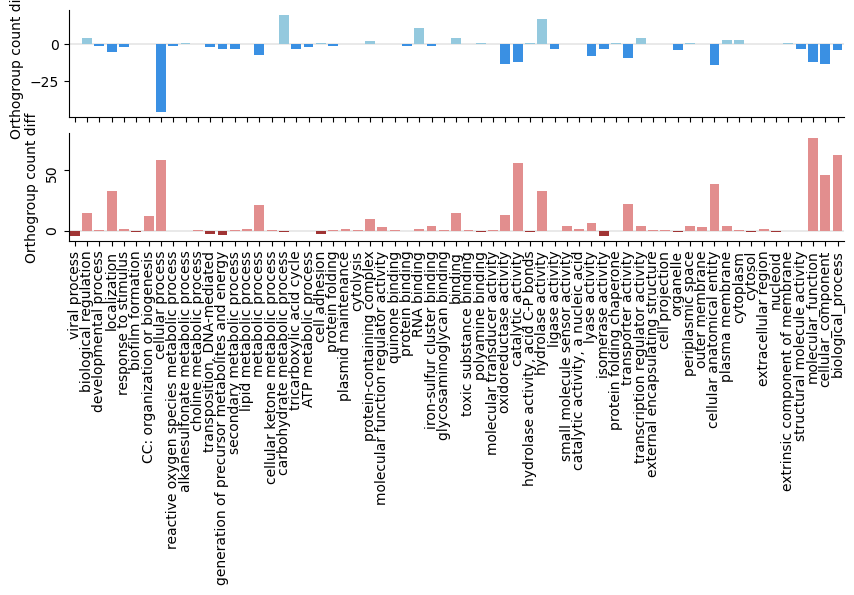

In [115]:
fig = plt.figure(figsize=(10, 3))

i, axes = 1, []
for tax1, tax2 in zip(['s__Schleiferilactobacillus harbinensis', 'g__Enterobacter'],
                      ['s__Lacticaseibacillus paracasei', 's__Pseudescherichia vulneris']):

    if i == 1:
        ax = fig.add_subplot(2, 1, i)
    else:
        ax = fig.add_subplot(2, 1, i, sharex=axes[0])
    axes.append(ax)


    orthos1 = get_unique_orthos(orthogroup_counts,   tax1, tax2)
    orthos2 = get_unique_orthos(orthogroup_counts,   tax2, tax1)

    # orthogroup_counts.loc[orthos1 + orthos2, :].T.dot((og2cluster.loc[orthos1 + orthos2] > 0).astype(int))

    # number of genes in each genome in each semantic GO group
    gocluster_counts = (orthogroup_counts.loc[orthos1 + orthos2, :].T > 0).astype(int).dot((og2cluster.loc[orthos1 + orthos2] > 0).astype(int))
    diffplot = (gocluster_counts.loc[tax1, :] - gocluster_counts.loc[tax2, :]).rename('diff').reset_index()
    diffplot = diffplot[diffplot['level_1'].isin(clusters)]
    # diffplot['order'] = pd.Categorical(diffplot['level_1'], ordered=True, categories = ordered_clusters)
    # diffplot = diffplot.sort_values('order')
    diffplot['hue'] = diffplot['diff'] > 0
    
    sns.barplot(data=diffplot,
                x='level_1', y='diff', # order=diffplot['order'],
                hue='hue', palette=[species_color_map[tax1], species_color_map[tax2]],
                hue_order=[True, False],
                ax=ax, zorder=1, dodge=False)
    ax.get_legend().remove()
    
    
    ax.axhline(0, color='gray', linewidth=0.25, zorder=0)
    
    
    # ax.set_yscale('log')
    sns.despine()
    

    if i == 2:
        new_labels = [cluster2desc[c].split(': ')[-1].replace('cellular component', 'CC:').replace('molecular process', 'MP:').replace('acting on ', '').replace('carbon-phosphorus', 'C-P') for c in diffplot[diffplot['level_1'].isin(clusters)]['level_1'].values]
        # new_labels = [c for c in diffplot['level_1'].values]
        ax.set_xticklabels(new_labels)
        ax.tick_params(rotation=90)
        # ax.set_ylim(-40,100)
    else:
        ax.tick_params(labelbottom=False)
    ax.set_xlabel('')
    ax.set_ylabel('Orthogroup count diff')
    
        
    i += 1
fig.subplots_adjust(hspace=0.15)
plt.savefig('./../data/figures/acc_comparison.svg', bbox_inches='tight')

In [2055]:
diffplot

,level_1,diff,hue
0,1,4,True
1,2,-1,False
2,3,-5,False
3,4,-2,False
4,5,0,False
...,...,...,...
91,92,1,True
93,94,-3,False
94,95,-12,False
96,97,-13,False


In [2057]:
(gocluster_counts.loc[tax1, :] - gocluster_counts.loc[tax2, :]).sort_values()

level_1
11   -46
76   -14
53   -13
97   -13
54   -12
      ..
48     4
1      4
44    11
57    17
24    23
Length: 100, dtype: int64

In [2032]:
[cluster2desc[c] for c in diffplot[diffplot['level_1'].isin(clusters)]['level_1'].values]

['1: biological regulation',
 '2: developmental process',
 '3: localization',
 '4: response to stimulus',
 '5: viral process',
 '6: biological process involved in symbiotic interaction',
 '8: biofilm formation',
 '10: cellular component organization or biogenesis',
 '11: cellular process',
 '14: reactive oxygen species metabolic process',
 '16: choline metabolic process',
 '17: alkanesulfonate metabolic process',
 '18: transposition, DNA-mediated',
 '19: generation of precursor metabolites and energy',
 '21: secondary metabolic process',
 '23: lipid metabolic process',
 '24: carbohydrate metabolic process',
 '25: nitrogen compound metabolic process',
 '26: tricarboxylic acid cycle',
 '28: ATP metabolic process',
 '31: cell adhesion',
 '32: protein folding',
 '34: plasmid maintenance',
 '35: cytolysis',
 '38: protein-containing complex',
 '39: molecular function regulator activity',
 '42: quinone binding',
 '43: protein binding',
 '44: RNA binding',
 '45: glycosaminoglycan binding',
 '4

In [2029]:
gocluster_counts

level_1,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
s__Pantoea agglomerans,27,0,41,8,0,1,0,0,0,8,...,0,0,0,0,171,0,58,133,0,0
s__Pseudescherichia vulneris,28,0,24,9,5,2,0,1,0,1,...,0,0,0,1,161,0,41,132,0,0
g__Enterobacter,43,1,57,11,1,1,0,0,0,13,...,0,0,0,1,237,0,87,194,0,0
s__Gluconobacter_A japonicus,8,0,12,0,0,0,0,0,0,6,...,0,0,0,2,54,0,24,43,0,0
s__Levilactobacillus brevis,13,0,13,2,0,0,0,0,0,2,...,0,0,0,2,64,0,18,49,0,0
s__Schleiferilactobacillus harbinensis,17,0,24,4,0,0,0,0,0,2,...,0,0,0,2,87,0,32,73,0,0
s__Lentilactobacillus parabuchneri,9,0,14,1,0,0,0,0,0,2,...,0,0,0,2,59,0,21,45,0,0
s__Lacticaseibacillus paracasei,23,0,24,2,0,0,0,0,0,2,...,0,0,0,2,96,0,33,71,0,0


level_1
1      15
2       1
3      33
4       2
5      -4
       ..
96      0
97     46
98     62
99      0
100     0
Length: 100, dtype: int64

In [2013]:
orthogroup_counts.loc[orthos1 + orthos2, :].T .dot((og2cluster.loc[orthos1 + orthos2] > 0).astype(int))

level_1,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
s__Pantoea agglomerans,30.0,0.0,45.0,10.0,0.0,1.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,203.0,0.0,64.0,149.0,0.0,0.0
s__Pseudescherichia vulneris,32.0,0.0,25.0,13.0,5.0,5.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,173.0,0.0,43.0,142.0,0.0,0.0
g__Enterobacter,46.0,1.0,64.0,11.0,1.0,1.0,0.0,0.0,0.0,17.0,...,0.0,0.0,0.0,1.0,253.0,0.0,104.0,217.0,0.0,0.0
s__Gluconobacter_A japonicus,13.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,...,0.0,0.0,0.0,2.0,69.0,0.0,34.0,58.0,0.0,0.0
s__Levilactobacillus brevis,16.0,0.0,20.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,2.0,83.0,0.0,25.0,63.0,0.0,0.0
s__Schleiferilactobacillus harbinensis,29.0,0.0,30.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,2.0,119.0,0.0,47.0,101.0,0.0,0.0
s__Lentilactobacillus parabuchneri,11.0,0.0,21.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,2.0,80.0,0.0,30.0,59.0,0.0,0.0
s__Lacticaseibacillus paracasei,35.0,0.0,46.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,2.0,139.0,0.0,56.0,112.0,0.0,0.0


In [2016]:
len(orthos1), len(orthos2)

(674, 640)

In [2019]:
(orthogroup_counts.loc[orthos1 + orthos2, :].T > 0).dot((og2cluster.loc[orthos1 + orthos2] > 0).astype(int))

level_1,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
s__Pantoea agglomerans,27,0,41,8,0,1,0,0,0,8,...,0,0,0,0,171,0,58,133,0,0
s__Pseudescherichia vulneris,28,0,24,9,5,2,0,1,0,1,...,0,0,0,1,161,0,41,132,0,0
g__Enterobacter,43,1,57,11,1,1,0,0,0,13,...,0,0,0,1,237,0,87,194,0,0
s__Gluconobacter_A japonicus,8,0,12,0,0,0,0,0,0,6,...,0,0,0,2,54,0,24,43,0,0
s__Levilactobacillus brevis,13,0,13,2,0,0,0,0,0,2,...,0,0,0,2,64,0,18,49,0,0
s__Schleiferilactobacillus harbinensis,17,0,24,4,0,0,0,0,0,2,...,0,0,0,2,87,0,32,73,0,0
s__Lentilactobacillus parabuchneri,9,0,14,1,0,0,0,0,0,2,...,0,0,0,2,59,0,21,45,0,0
s__Lacticaseibacillus paracasei,23,0,24,2,0,0,0,0,0,2,...,0,0,0,2,96,0,33,71,0,0


In [2008]:
gocluster_counts.loc[tax2, :]

level_1
1       32.0
2        0.0
3       25.0
4       13.0
5        5.0
       ...  
96       0.0
97      43.0
98     142.0
99       0.0
100      0.0
Name: s__Pseudescherichia vulneris, Length: 100, dtype: float64

In [2007]:
diffplot.sort_values('diff')

,level_1,diff,hue
61,62,-4.0,False
4,5,-4.0,False
5,6,-4.0,False
18,19,-3.0,False
3,4,-2.0,False
...,...,...,...
96,97,61.0,True
53,54,62.0,True
10,11,73.0,True
97,98,75.0,True


In [1962]:
(diffplot['diff'] > 0)

0      True
1     False
2      True
3     False
4     False
      ...  
95    False
96     True
97     True
98    False
99    False
Name: diff, Length: 100, dtype: bool

In [1960]:
diffplot['diff'] > 0

0      True
1      True
2      True
3     False
4     False
      ...  
95    False
96     True
97     True
98    False
99    False
Name: diff, Length: 100, dtype: bool

In [1957]:
diffplot['diff'] > 0

0      True
1     False
2      True
3     False
4     False
      ...  
95    False
96     True
97     True
98    False
99    False
Name: diff, Length: 100, dtype: bool

In [1954]:
diffplot

level_1
1      14.0
2       1.0
3      39.0
4      -2.0
5      -4.0
       ... 
96      0.0
97     61.0
98     75.0
99      0.0
100     0.0
Name: diff, Length: 100, dtype: float64

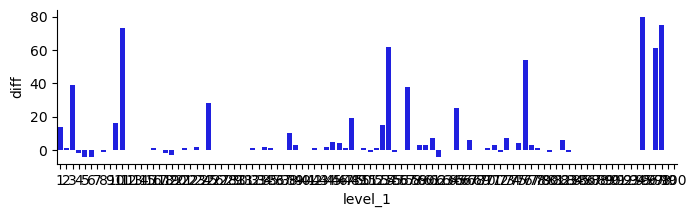

In [1930]:
fig, ax = plt.subplots(figsize=(8, 2))
sns.barplot(data=diffplot.reset_index(),
            x='level_1', y='diff', color='blue')
# ax.set_yscale('log')
sns.despine()

In [1786]:
temp

,1,2,3,4,5,6,7,8,9,10,...,75,76,77,78,79,94,95,96,97,98
group,,,,,,,,,,,,,,,,,,,,,
g__Enterobacter,43,1,57,11,1,1,0,0,0,13,...,4,78,5,6,0,1,237,0,87,194
s__Pseudescherichia vulneris,28,0,24,9,5,2,0,1,0,1,...,1,39,1,5,0,1,161,0,41,132


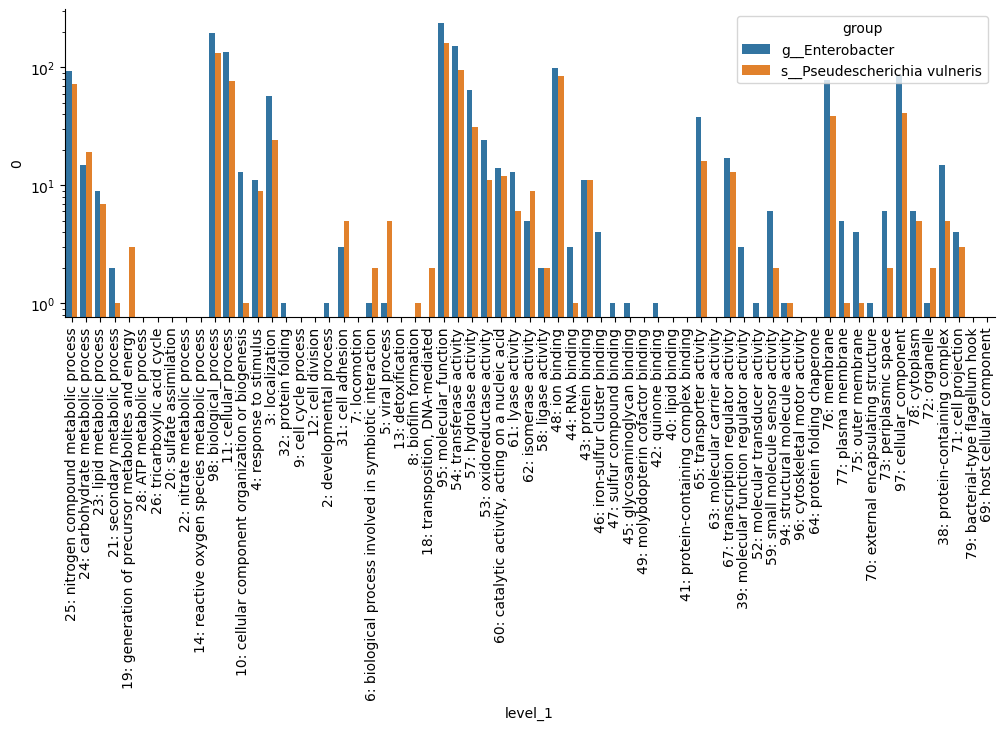

In [1732]:
fig, ax = plt.subplots(figsize=(12,4))
sns.barplot(data=ortho_cluster_plotdf[~ortho_cluster_plotdf.group.eq('shared')].groupby('group').sum().iloc[:, 3:-2].stack().reset_index(),
            x='level_1', y=0, hue='group', order=ordering2)

ax.set_xticklabels([cluster2desc[c] for c in ordering2])
ax.tick_params(rotation=90, axis='x')
ax.set_yscale('log')
sns.despine()

In [1026]:
# def calc_localization_score(gene_ids, all_genes):
gene_ids = seq2genome[seq2genome.eq('UO5-1_MAG_02')].index

def make_geneloc_df(gene_ids):
    '''
    take a list of gene ids and make a dataframe containing contig & gene loc
    needs spades contig IDs
    '''
    
    df = pd.DataFrame(index=gene_ids, columns=['contig', 'order'])
    for gene in gene_ids:
        df.loc[gene, :] = ['_'.join(gene.split('_')[:-1]), int(gene.split('_')[-1])]
    return df

def test_loc_similarity(target_genes, all_genes, n_reps=100):
    '''
    score how similar a group of genes is
    '''
    df = make_geneloc_df(gene_ids)
    n_contigs = df.loc[target_genes, 'contig'].value_counts()
    # main_contig = n_contigs.index[0]
    dists = []
    for contig in n_contigs.index:
        locs = [[i] for i in df[df['contig'].eq(contig) & df.index.isin(target_genes)]['order'].unique()]
        if len(locs) == 1:
            dist = 100
        else:
            dist = squareform(pdist(locs)).mean()
        dists.append(dist)
    return np.mean(dists)
    

In [ ]:
# def calc_localization_score(gene_ids, all_genes):
gene_ids = seq2genome[seq2genome.eq('UO5-1_MAG_02')].index
df = make_geneloc_df(gene_ids)

In [1027]:
consecutive_genes = ['NODE_3_length_463027_cov_129.355367_1',
       'NODE_3_length_463027_cov_129.355367_2',
       'NODE_3_length_463027_cov_129.355367_3',
       'NODE_3_length_463027_cov_129.355367_4',
       'NODE_3_length_463027_cov_129.355367_5']

df = make_geneloc_df(gene_ids)
diff_contigs = df.reset_index().groupby('contig').apply(lambda x: x[:1]).head(10)['index'].values
random = df.reset_index().groupby('contig').apply(lambda x: x.sample(np.min([5, len(x)]))).iloc[:5]['index'].values


print('Consecutive', test_loc_similarity(consecutive_genes, gene_ids, 10))
print('Diff contigs', test_loc_similarity(diff_contigs, gene_ids, 10))
print('Random', test_loc_similarity(random, gene_ids, 10))

Consecutive 1.6
Diff contigs 100.0
Random 23.52


In [1028]:
test_loc_similarity(consecutive_genes, gene_ids, 10)

1.6

In [1029]:


def summarize_interpro(descs):
    '''
    take a list of interpro descriptions
    and return the most frequenent comma-delimated substring
    '''
    c = Counter([i for desc in descs for i in desc.split(',')])
    return max(c, key=c.get)

In [1030]:
unique_orthos = get_unique_orthos(orthogroup_counts.rename(columns=mag2species), 'g__Enterobacter', 's__Pseudescherichia vulneris')
print(len(unique_orthos))

674


In [1598]:
for cluster_id in [65]: # cluster_desc in cluster2desc.items():

#     print(cluster_desc)
    # get ortho groups of a cluster
    # cluster_id = 65
    cluster_og_ids = og2cluster.loc[:, cluster_id].reindex(unique_orthos)
    cluster_og_ids[cluster_og_ids > 0]

    # get all annotations of these interpro groups
    cluster_interpros = og2interpro.loc[:, cluster_og_ids[cluster_og_ids > 0].index].apply(lambda x: x[x > 0].index.to_series().unique(), axis=0) #.explode().unique()

    # summarize descriptions
    cluster_interpros.apply(lambda x: summarize_interpro(interpro2desc.loc[x].unique())).value_counts()

    # get genes in orthogroups and species of interest
    genes_of_interest = gene2ortho[gene2ortho.isin(cluster_og_ids[cluster_og_ids > 0].index) & gene2ortho.index.isin(seq2genome[seq2genome.map(mag2species).eq('g__Enterobacter')].index)].index

    # # get annotations from gene list
    # interpro_data[interpro_data.protein_accession.isin(genes_of_interest)]['interpro_annotations'].unique()

    print(test_loc_similarity(genes_of_interest, gene_ids))
    print()

54.30827160493827



In [1600]:
cluster_og_ids[cluster_og_ids > 0].index

Index(['OG0000219', 'OG0000368', 'OG0000722', 'OG0000789', 'OG0000854',
       'OG0000932', 'OG0001091', 'OG0001214', 'OG0001260', 'OG0001262',
       'OG0001291', 'OG0001551', 'OG0001554', 'OG0001555', 'OG0001576',
       'OG0001586', 'OG0001595', 'OG0002206', 'OG0002212', 'OG0002220',
       'OG0002222', 'OG0003006', 'OG0003229', 'OG0003231', 'OG0003236',
       'OG0003272', 'OG0003648', 'OG0003649', 'OG0003743', 'OG0003756',
       'OG0003757', 'OG0003778', 'OG0003781', 'OG0004279', 'OG0005182',
       'OG0005768', 'OG0006607', 'OG0006724'],
      dtype='object', name='level_0')

In [1599]:
cluster_interpros

level_0
OG0000219         [IPR036259, IPR004638, IPR011701, IPR020846]
OG0000368    [IPR036259, IPR004638, IPR011701, IPR020846, I...
OG0000722                    [IPR002528, IPR044644, IPR045070]
OG0000789    [IPR003439, IPR027417, IPR017871, IPR003593, I...
OG0000854         [IPR000515, IPR035906, IPR017797, IPR005769]
OG0000932    [IPR003439, IPR027417, IPR017871, IPR003593, I...
OG0001091                    [IPR003501, IPR036095, IPR013012]
OG0001214                               [IPR010651, IPR004673]
OG0001260    [IPR003439, IPR027417, IPR017871, IPR003593, I...
OG0001262    [IPR003439, IPR027417, IPR017871, IPR003593, I...
OG0001291    [IPR023214, IPR036412, IPR018247, IPR001757, I...
OG0001551                    [IPR004715, IPR002178, IPR016152]
OG0001554                    [IPR003352, IPR004796, IPR004501]
OG0001555                    [IPR003352, IPR004796, IPR004501]
OG0001576    [IPR001638, IPR015168, IPR007210, IPR010068, I...
OG0001586    [IPR012910, IPR037066, IPR036942, 

In [1055]:
sorted(genes_of_interest)

['NODE_104_length_73425_cov_170.883944_34',
 'NODE_104_length_73425_cov_170.883944_42',
 'NODE_15_length_297527_cov_115.807568_33',
 'NODE_181_length_41339_cov_162.246633_27',
 'NODE_181_length_41339_cov_162.246633_33',
 'NODE_181_length_41339_cov_162.246633_6',
 'NODE_208_length_33358_cov_113.218389_29',
 'NODE_24_length_213096_cov_109.631334_31',
 'NODE_24_length_213096_cov_109.631334_32',
 'NODE_26_length_210358_cov_154.326900_17',
 'NODE_26_length_210358_cov_154.326900_85',
 'NODE_27_length_206235_cov_159.749059_142',
 'NODE_27_length_206235_cov_159.749059_143',
 'NODE_29_length_176004_cov_138.922040_24',
 'NODE_29_length_176004_cov_138.922040_52',
 'NODE_35_length_155439_cov_120.399488_131',
 'NODE_35_length_155439_cov_120.399488_77',
 'NODE_3_length_463027_cov_129.355367_121',
 'NODE_3_length_463027_cov_129.355367_144',
 'NODE_3_length_463027_cov_129.355367_156',
 'NODE_3_length_463027_cov_129.355367_261',
 'NODE_3_length_463027_cov_129.355367_393',
 'NODE_3_length_463027_cov_129

In [1047]:
gene2ortho[gene2ortho.isin(cluster_og_ids[cluster_og_ids > 0].index) & gene2ortho.index.isin(seq2genome[seq2genome.map(mag2species).eq('g__Enterobacter')].index)].index

Index([], dtype='object')

In [1046]:
genes_of_interest

Index([], dtype='object')

In [1044]:
test_loc_similarity(genes_of_interest, gene_ids)

nan

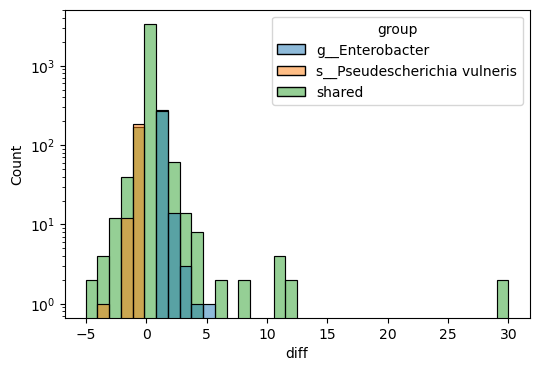

In [437]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(data=ortho_cluster_plotdf, x='diff', hue='group', bins=36)
ax.set_yscale('log')

In [425]:
def get_namespace(go_id, godag):
    return godag[go_id].namespace  # 'biological_process', 'molecular_function', 'cellular_component'

groups_by_namespace = {"BP": [], "MF": [], "CC": []}
ns_map = {"biological_process": "BP", "molecular_function": "MF", "cellular_component": "CC"}
for c, go_id in cluster2goid.items():
    ns = ns_map[get_namespace(go_id, godag)]
    groups_by_namespace[ns].append(c)

NameError: name 'cluster2goid' is not defined

In [422]:
[cluster2desc[c] for c in df.columns]

['54: transferase activity',
 '95: molecular_function',
 '25: nitrogen compound metabolic process',
 '11: cellular process',
 '98: biological_process',
 '48: ion binding',
 '76: membrane',
 '97: cellular_component',
 '57: hydrolase activity',
 '3: localization',
 '65: transporter activity',
 '53: oxidoreductase activity',
 '60: catalytic activity, acting on a nucleic acid',
 '24: carbohydrate metabolic process',
 '44: RNA binding',
 '78: cytoplasm',
 '61: lyase activity',
 '38: protein-containing complex',
 '43: protein binding',
 '4: response to stimulus',
 '10: cellular component organization or biogenesis',
 '67: transcription regulator activity',
 '62: isomerase activity',
 '58: ligase activity',
 '23: lipid metabolic process',
 '46: iron-sulfur cluster binding',
 '72: organelle',
 '94: structural molecule activity',
 '77: plasma membrane',
 '19: generation of precursor metabolites and energy',
 '73: periplasmic space',
 '75: outer membrane',
 '7: locomotion',
 '59: small molecule 

In [430]:
gos_of_interest = ortho_cluster_plotdf[ortho_cluster_plotdf['diff'].apply(np.abs) > 2].index.unique()

In [449]:
gos_of_interest = ['OG0000008']

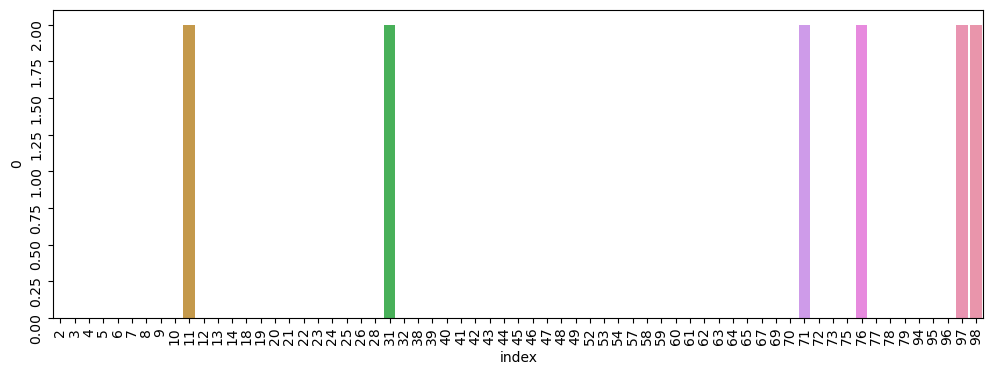

In [450]:
fig,ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=(ortho_cluster_plotdf[ortho_cluster_plotdf.index.to_series().isin(gos_of_interest)].iloc[:, 6:-2]).sum(0).reset_index(),
           x='index', y=0)
ax.tick_params(rotation=90)

2      0
3      0
4      0
5      0
6      0
      ..
94     0
95     8
96     0
97     8
98    12
Length: 65, dtype: int64

In [284]:
temp = ortho_cluster_plotdf.loc[:, ['group', 36]]
temp[temp[36]]['group'].value_counts()

shared                          64
g__Enterobacter                  6
s__Pseudescherichia vulneris     2
Name: group, dtype: int64

In [285]:
ortho_cluster_plotdf.loc[:, 34].sum()

KeyError: 34

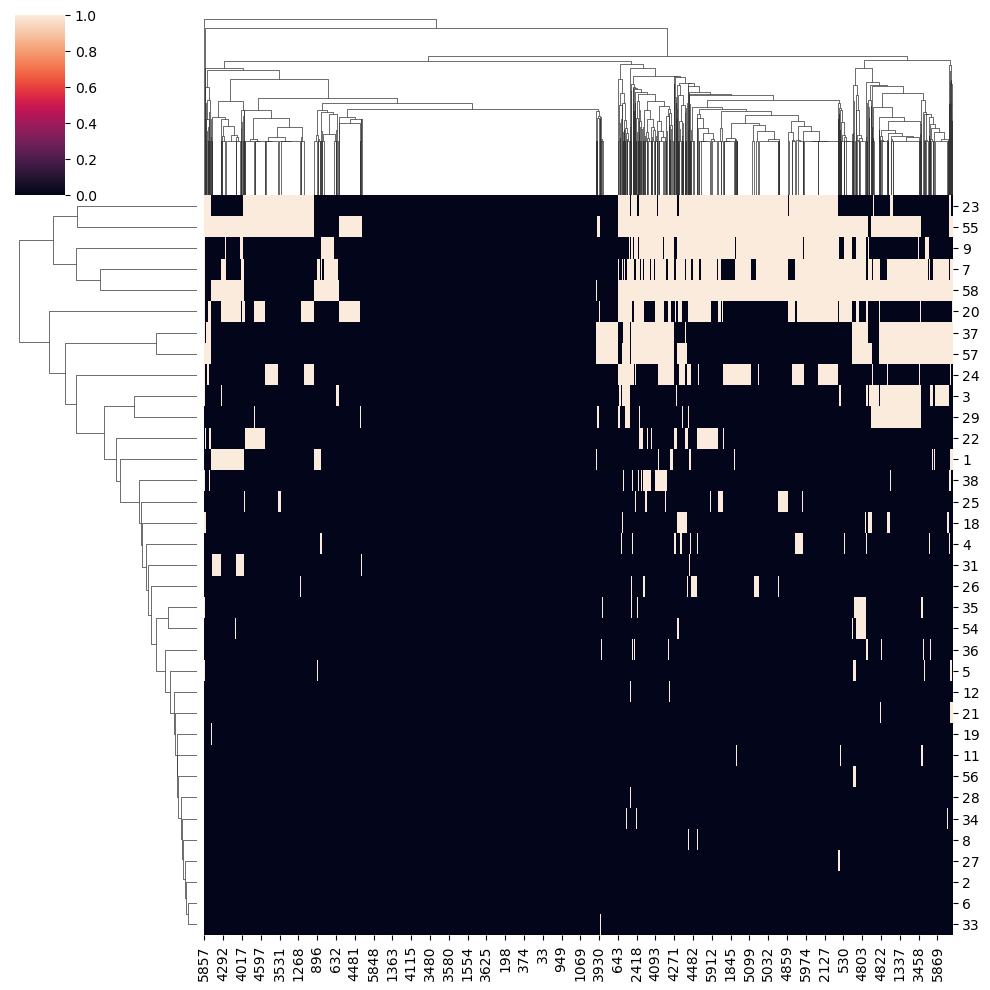

In [130]:
sns.clustermap(ortho_cluster_plotdf.iloc[:, 6:].drop('secondary_order', axis=1).T)

In [1096]:
c = Counter(per_gene_gos)

<Axes: xlabel='index', ylabel='0'>

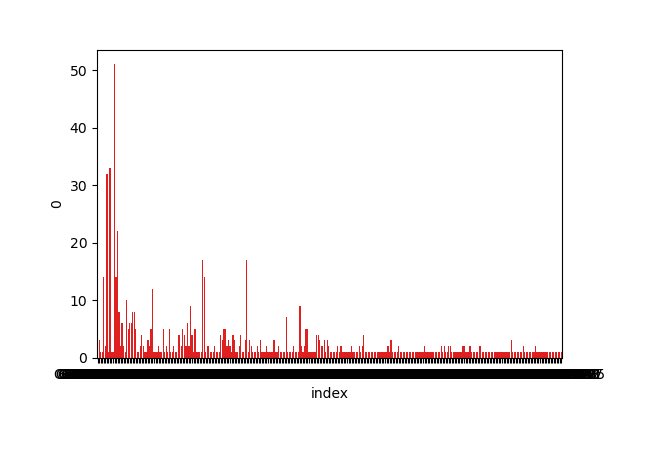

In [1109]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=pd.Series(c).reset_index(),
           x='index', y=0, color='r')

In [1007]:
all_reaction_data[all_reaction_data['gene_id'].eq('NODE_181_length_41339_cov_162.246633_38')]['pathway']

Series([], Name: pathway, dtype: object)

In [1006]:
# ent_hop_orthos

In [ ]:
'''
orthogroups to pathways
'''

In [ ]:
'''
orthogroups to domains
'''

## Co-occurrence

Co-occurrence network (pure Python): CLR-transform your abundance table (skbio.stats.composition.clr) to handle compositionality, then Spearman correlation between species pairs (scipy.stats.spearmanr), with permutation-based p-values (shuffle sample labels per species, rebuild null) — this replicates SparCC's logic without needing external binaries. Build the graph in networkx; compute this per treatment group if edges differ by hops/exposure.

In [857]:
import scipy
from scipy.stats import spearmanr


In [858]:
def spearman_cooccurrence_with_permutation(clr_df, n_permutations=999, random_state=0):
    """
    Returns: (rho_matrix, pval_matrix) as DataFrames, species x species
    """
    species = clr_df.columns.tolist()
    n = len(species)
    rho_matrix = pd.DataFrame(np.eye(n), index=species, columns=species)
    pval_matrix = pd.DataFrame(np.zeros((n, n)), index=species, columns=species)

    rng = np.random.default_rng(random_state)

    for i in range(n):
        for j in range(i + 1, n):
            x, y = clr_df.iloc[:, i].values, clr_df.iloc[:, j].values
            observed_rho, _ = spearmanr(x, y)

            null_rhos = np.empty(n_permutations)
            for p in range(n_permutations):
                y_shuffled = rng.permutation(y)
                null_rhos[p], _ = spearmanr(x, y_shuffled)

            empirical_p = (np.sum(np.abs(null_rhos) >= np.abs(observed_rho)) + 1) / (n_permutations + 1)

            rho_matrix.iloc[i, j] = rho_matrix.iloc[j, i] = observed_rho
            pval_matrix.iloc[i, j] = pval_matrix.iloc[j, i] = empirical_p

    return rho_matrix, pval_matrix

In [860]:
rho, pvals = spearman_cooccurrence_with_permutation(clr_table)

In [861]:
rho

,S_cerevisiae,g__Enterobacter,s__Lacticaseibacillus paracasei,s__Lentilactobacillus parabuchneri,s__Pantoea agglomerans,s__Pseudescherichia vulneris,s__Schleiferilactobacillus harbinensis
S_cerevisiae,1.000000,0.768284,-0.728729,-0.656227,0.549692,0.679671,-0.189356
g__Enterobacter,0.768284,1.000000,-0.583726,-0.721307,0.336079,0.431390,0.048606
s__Lacticaseibacillus paracasei,-0.728729,-0.583726,1.000000,0.735246,-0.715695,-0.628077,-0.152245
s__Lentilactobacillus parabuchneri,-0.656227,-0.721307,0.735246,1.000000,-0.548063,-0.540641,-0.204471
s__Pantoea agglomerans,0.549692,0.336079,-0.715695,-0.548063,1.000000,0.835445,-0.332911
s__Pseudescherichia vulneris,0.679671,0.431390,-0.628077,-0.540641,0.835445,1.000000,-0.587618
s__Schleiferilactobacillus harbinensis,-0.189356,0.048606,-0.152245,-0.204471,-0.332911,-0.587618,1.000000


In [874]:
interpro_columns

['protein_accession',
 'sequence_md5',
 'sequence_length',
 'analysis',
 'signature_accession',
 'signature_description',
 'start_location',
 'stop_location',
 'score',
 'status',
 'date',
 'interpro_accession',
 'interpro_annotations']

In [1325]:
import matplotlib as mpl

In [1351]:
"""
Pseudocode: functional-overlap vs. co-occurrence niche analysis.
Not run/tested -- structure and real function calls only.
"""

import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from skbio.stats.composition import clr
from skbio.stats.distance import mantel, DistanceMatrix
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# 1. Functional capacity matrix (species x pathway/domain)
# ---------------------------------------------------------------------------
def build_functional_matrix(gapseq_pathway_tables, 
                            # interpro_tables, #target_pathways, target_domains
                           ):
    """
    gapseq_pathway_tables: dict[species] -> path to that species' *-Pathways.tbl
    interpro_tables:       dict[species] -> path to that species' InterProScan output
    target_pathways / target_domains: your a priori fermentation-relevant lists

    Returns: DataFrame, index=species, columns=pathway/domain IDs,
             values = completeness score (0-1) or presence (0/1)
    """
    rows = {}
    for species, pwy_path in gapseq_pathway_tables.items():
        pwy_df = pd.read_csv(pwy_path, sep="\t", skiprows=3)
        pwy_df = pwy_df[pwy_df['Completeness'] > 0.75]
        # pwy_df = pwy_df[pwy_df["Name"].isin(target_pathways)]
        pwy_scores = dict(zip(pwy_df["Name"], pwy_df["Completeness"]))

        # ipr_df = pd.read_csv(interpro_tables[species], sep='\t', header=None, names=interpro_columns)
        # # ipr_df = ipr_df[ipr_df["domain_id"].isin(target_domains)]
        # domain_presence = {d: 1 for d in ipr_df["signature_accession"].unique()}

        rows[species] = {**pwy_scores}

    functional_df = pd.DataFrame.from_dict(rows, orient="index").fillna(0)
    return functional_df


# ---------------------------------------------------------------------------
# 2. Pairwise functional overlap -> distance matrix
# ---------------------------------------------------------------------------
def functional_distance_matrix(functional_df, metric="jaccard"):
    """
    metric="jaccard" for presence/absence (binarize first),
    metric="cosine" or "euclidean" for continuous completeness scores.
    Returns: skbio DistanceMatrix, species-ordered to match functional_df.index
    """
    if metric == "jaccard":
        binary = (functional_df > 0).astype(int)
        dist_condensed = pdist(binary.values, metric="jaccard")
    else:
        dist_condensed = pdist(functional_df.values, metric=metric)

    dist_square = squareform(dist_condensed)
    return DistanceMatrix(dist_square, ids=functional_df.index.tolist())


# ---------------------------------------------------------------------------
# 3. Co-occurrence network from abundance data (CLR + Spearman + permutation)
# ---------------------------------------------------------------------------
def clr_transform_abundance(abundance_df, pseudocount=1e-6):
    """
    abundance_df: samples x species (raw or relative abundance)
    Returns: samples x species, CLR-transformed
    """
    values = abundance_df.values + pseudocount
    clr_values = clr(values)
    return pd.DataFrame(clr_values, index=abundance_df.index, columns=abundance_df.columns)


def spearman_cooccurrence_with_permutation(clr_df, n_permutations=999, random_state=0):
    """
    Returns: (rho_matrix, pval_matrix) as DataFrames, species x species
    """
    species = clr_df.columns.tolist()
    n = len(species)
    rho_matrix = pd.DataFrame(np.eye(n), index=species, columns=species)
    pval_matrix = pd.DataFrame(np.zeros((n, n)), index=species, columns=species)

    rng = np.random.default_rng(random_state)

    for i in range(n):
        for j in range(i + 1, n):
            x, y = clr_df.iloc[:, i].values, clr_df.iloc[:, j].values
            observed_rho, _ = spearmanr(x, y)

            null_rhos = np.empty(n_permutations)
            for p in range(n_permutations):
                y_shuffled = rng.permutation(y)
                null_rhos[p], _ = spearmanr(x, y_shuffled)

            empirical_p = (np.sum(np.abs(null_rhos) >= np.abs(observed_rho)) + 1) / (n_permutations + 1)

            rho_matrix.iloc[i, j] = rho_matrix.iloc[j, i] = observed_rho
            pval_matrix.iloc[i, j] = pval_matrix.iloc[j, i] = empirical_p

    return rho_matrix, pval_matrix


def build_cooccurrence_graph(rho_matrix, pval_matrix, alpha=0.05):
    """
    Returns: networkx Graph, edges only for significant correlations,
             edge attribute 'weight' = rho, 'sign' = + or -
    """
    G = nx.Graph()
    G.add_nodes_from(rho_matrix.index)

    species = rho_matrix.index.tolist()
    for i in range(len(species)):
        for j in range(i + 1, len(species)):
            a, b = species[i], species[j]
            rho = rho_matrix.loc[a, b]
            p = pval_matrix.loc[a, b]
            if p < alpha:
                G.add_edge(a, b, weight=rho, sign="positive" if rho > 0 else "negative")

    return G


def cooccurrence_distance_matrix(rho_matrix):
    """
    Convert correlation to distance for Mantel comparison: 1 - rho
    (so strong positive co-occurrence = small distance).
    Returns: skbio DistanceMatrix, same species order as rho_matrix
    """
    dist_values = 1 - rho_matrix.values
    np.fill_diagonal(dist_values, 0)
    return DistanceMatrix(dist_values, ids=rho_matrix.index.tolist())


# ---------------------------------------------------------------------------
# 4. Mantel test: functional overlap vs. co-occurrence
# ---------------------------------------------------------------------------
def run_mantel_test(functional_dm, cooccurrence_dm, method="spearman", permutations=999):
    """
    functional_dm, cooccurrence_dm: skbio DistanceMatrix objects,
    MUST share the same species set/order (skbio handles reordering by id
    if ids match, but confirm species sets are identical first).

    Returns: (correlation_coefficient, p_value, n)
    """
    shared_ids = [i for i in functional_dm.ids if i in cooccurrence_dm.ids]
    functional_dm = functional_dm.filter(shared_ids)
    cooccurrence_dm = cooccurrence_dm.filter(shared_ids)

    r, p, n = mantel(functional_dm, cooccurrence_dm, method=method, permutations=permutations)
    return r, p, n


# ---------------------------------------------------------------------------
# 5. Two-panel figure
# ---------------------------------------------------------------------------
def plot_niche_overlap_figure(cooccurrence_graph, functional_df, species_family_map,
                               mantel_r, mantel_p, outpath="niche_overlap_figure.png"):
    """
    species_family_map: dict[species] -> family (for node/row coloring)
    """
    fig, (ax_net, ax_heat) = plt.subplots(1, 2, figsize=(14, 6))

    # --- left panel: co-occurrence network ---
    pos = nx.spring_layout(cooccurrence_graph, seed=0)
    node_colors = [hash(species_family_map[n]) % 20 for n in cooccurrence_graph.nodes]

    edge_colors = ["tab:blue" if d["sign"] == "positive" else "tab:red"
                   for _, _, d in cooccurrence_graph.edges(data=True)]
    edge_widths = [abs(d["weight"]) * 4 for _, _, d in cooccurrence_graph.edges(data=True)]

    nx.draw_networkx_nodes(cooccurrence_graph, pos, node_color=node_colors, ax=ax_net)
    nx.draw_networkx_labels(cooccurrence_graph, pos, ax=ax_net, font_size=8)
    nx.draw_networkx_edges(cooccurrence_graph, pos, edge_color=edge_colors,
                            width=edge_widths, ax=ax_net)
    ax_net.set_title("Co-occurrence network")
    ax_net.axis("off")

    # --- right panel: functional capacity clustermap ---
    # clustermap makes its own figure; render separately then compose,
    # or use sns.heatmap on ax_heat with precomputed linkage if a single
    # combined figure object is required
    row_colors = functional_df.index.map(species_family_map)
    sns.clustermap(functional_df, cmap="viridis", cbar=True)
    ax_heat.set_title("Functional capacity matrix")

    fig.suptitle(f"Mantel r = {mantel_r:.2f}, p = {mantel_p:.3f}")
    # fig.savefig(outpath, dpi=300, bbox_inches="tight")
    return fig


# ---------------------------------------------------------------------------
# Orchestration
# ---------------------------------------------------------------------------
# def main():



In [1330]:
species_family_map = {
            'g__Enterobacter':'E',
            's__Lacticaseibacillus paracasei':'L',
            's__Lentilactobacillus parabuchneri':'L',
            's__Pantoea agglomerans':'E',
            's__Pseudescherichia vulneris':'E',
            's__Schleiferilactobacillus harbinensis':'L'}  # species -> Enterobacteriaceae/Lactobacillaceae/Acetobacteraceae

In [1340]:
pval_matrix

,g__Enterobacter,s__Lacticaseibacillus paracasei,s__Lentilactobacillus parabuchneri,s__Pantoea agglomerans,s__Pseudescherichia vulneris,s__Schleiferilactobacillus harbinensis
g__Enterobacter,0.000,0.294,0.011,0.004,0.018,0.144
s__Lacticaseibacillus paracasei,0.294,0.000,0.002,0.008,0.011,0.154
s__Lentilactobacillus parabuchneri,0.011,0.002,0.000,0.001,0.003,0.239
s__Pantoea agglomerans,0.004,0.008,0.001,0.000,0.001,0.218
s__Pseudescherichia vulneris,0.018,0.011,0.003,0.001,0.000,0.072
s__Schleiferilactobacillus harbinensis,0.144,0.154,0.239,0.218,0.072,0.000


{'weight': -0.6295652173913043, 'sign': 'negative'}
{'weight': -0.7739130434782608, 'sign': 'negative'}
{'weight': 0.5721739130434782, 'sign': 'positive'}
{'weight': 0.6991304347826087, 'sign': 'positive'}
{'weight': -0.64, 'sign': 'negative'}
{'weight': 0.41739130434782606, 'sign': 'positive'}
{'weight': -0.7817391304347826, 'sign': 'negative'}
{'weight': 0.9382608695652173, 'sign': 'positive'}
{'weight': -0.5852173913043477, 'sign': 'negative'}
{'weight': -0.7182608695652173, 'sign': 'negative'}


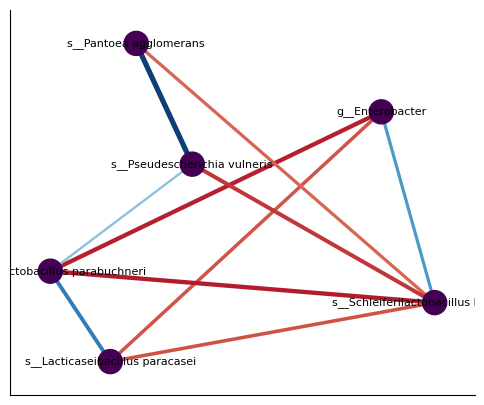

In [1425]:
rho_matrix, pval_matrix = spearman_cooccurrence_with_permutation(clr_table[clr_table.index.str.contains('-3')].drop('S_cerevisiae', axis=1))
cooccurrence_graph = build_cooccurrence_graph(rho_matrix, pval_matrix)
cooccurrence_dm = cooccurrence_distance_matrix(rho_matrix)


fig, ax = plt.subplots(figsize=(6,5))
pos = nx.spring_layout(cooccurrence_graph, seed=0)
node_colors = [hash(species_family_map[n]) % 20 for n in cooccurrence_graph.nodes]

for _, _, d in cooccurrence_graph.edges(data=True):
    print(d)
cmap = mpl.colormaps['RdBu']

edge_colors = ["tab:blue" if d["sign"] == "positive" else "tab:red"
               for _, _, d in cooccurrence_graph.edges(data=True)]

norm = mpl.colors.Normalize(-1, 1)
edge_colors = [cmap(norm(d['weight']))
               for _, _, d in cooccurrence_graph.edges(data=True)]

edge_widths = [abs(d["weight"]) * 4 for _, _, d in cooccurrence_graph.edges(data=True)]

nx.draw_networkx_nodes(cooccurrence_graph, pos, node_color=node_colors)
nx.draw_networkx_labels(cooccurrence_graph, pos, font_size=8)
nx.draw_networkx_edges(cooccurrence_graph, pos, edge_color=edge_colors,
                        width=edge_widths)
sns.despine()

plt.savefig('./../data/figures/week3_cooccurence.svg', bbox_inches='tight')

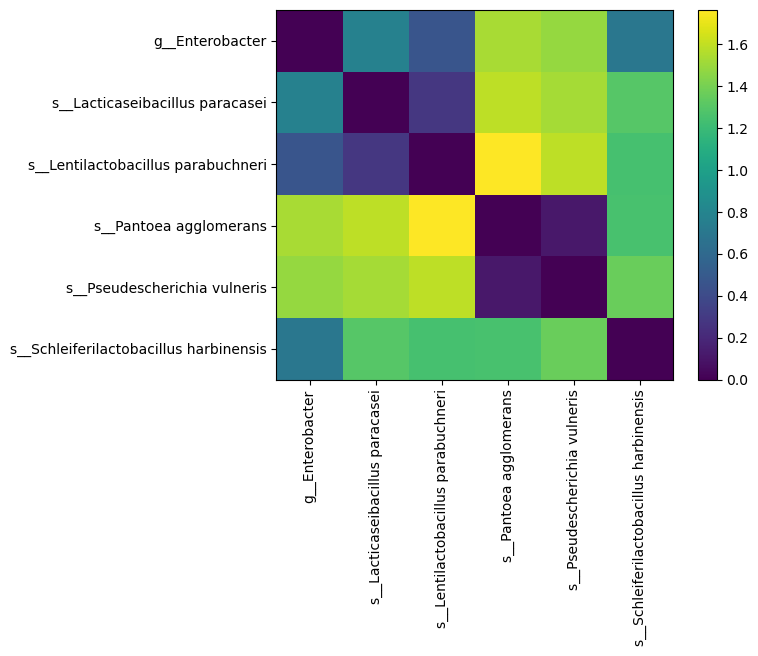

In [1349]:
cooccurrence_dm

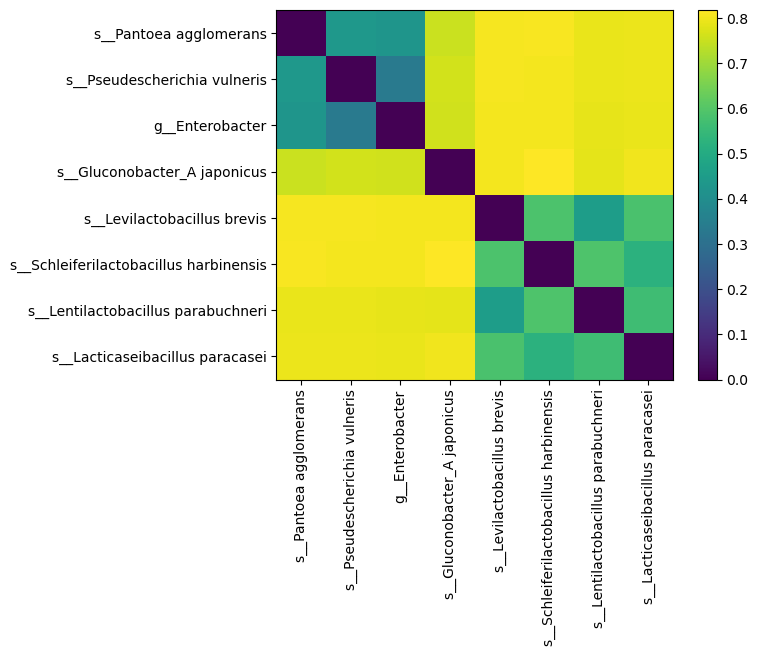

In [1350]:
functional_dm

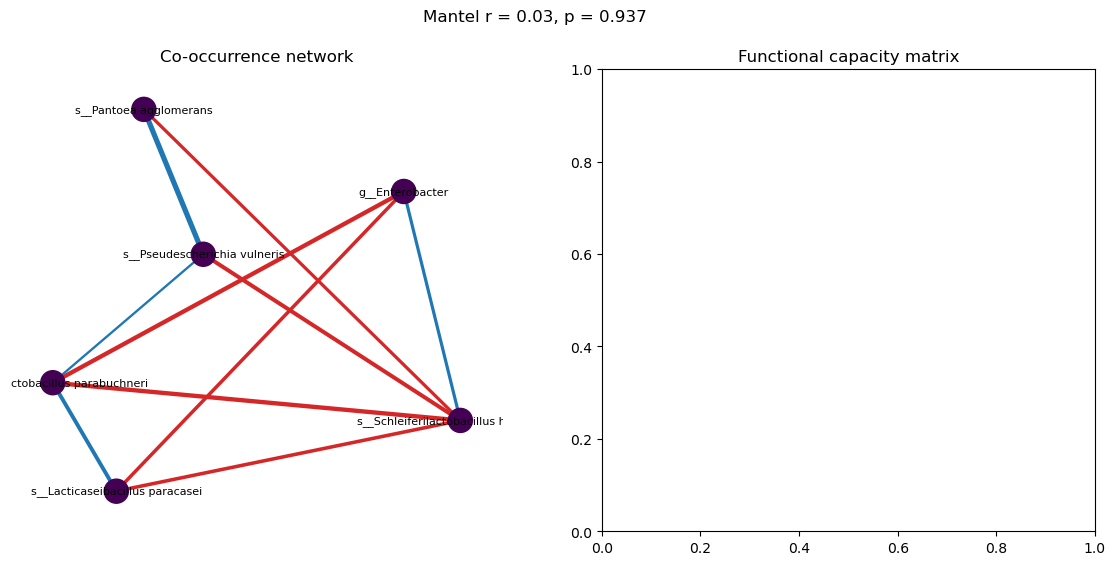

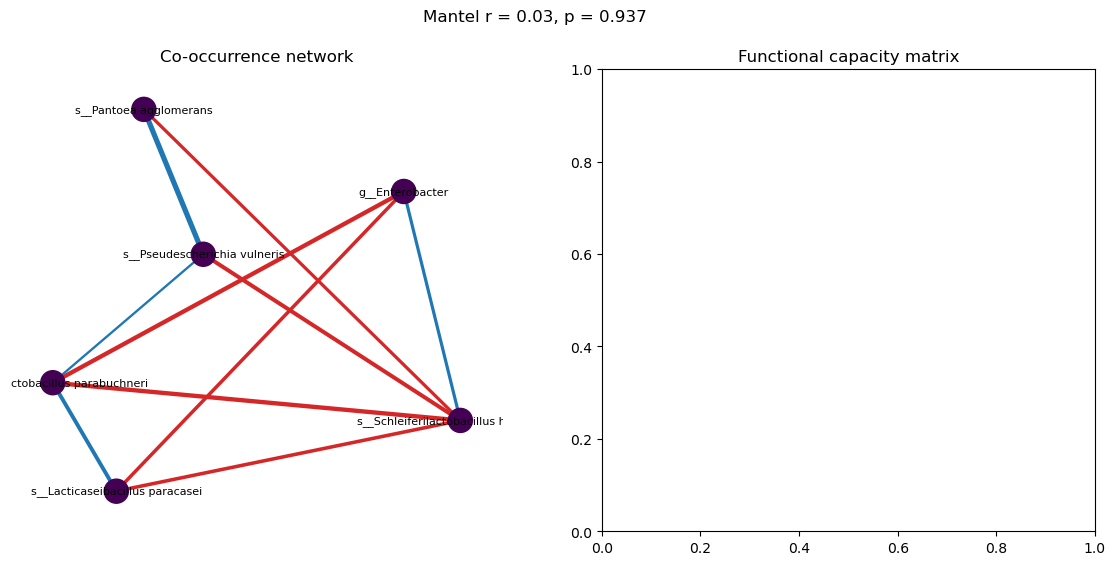

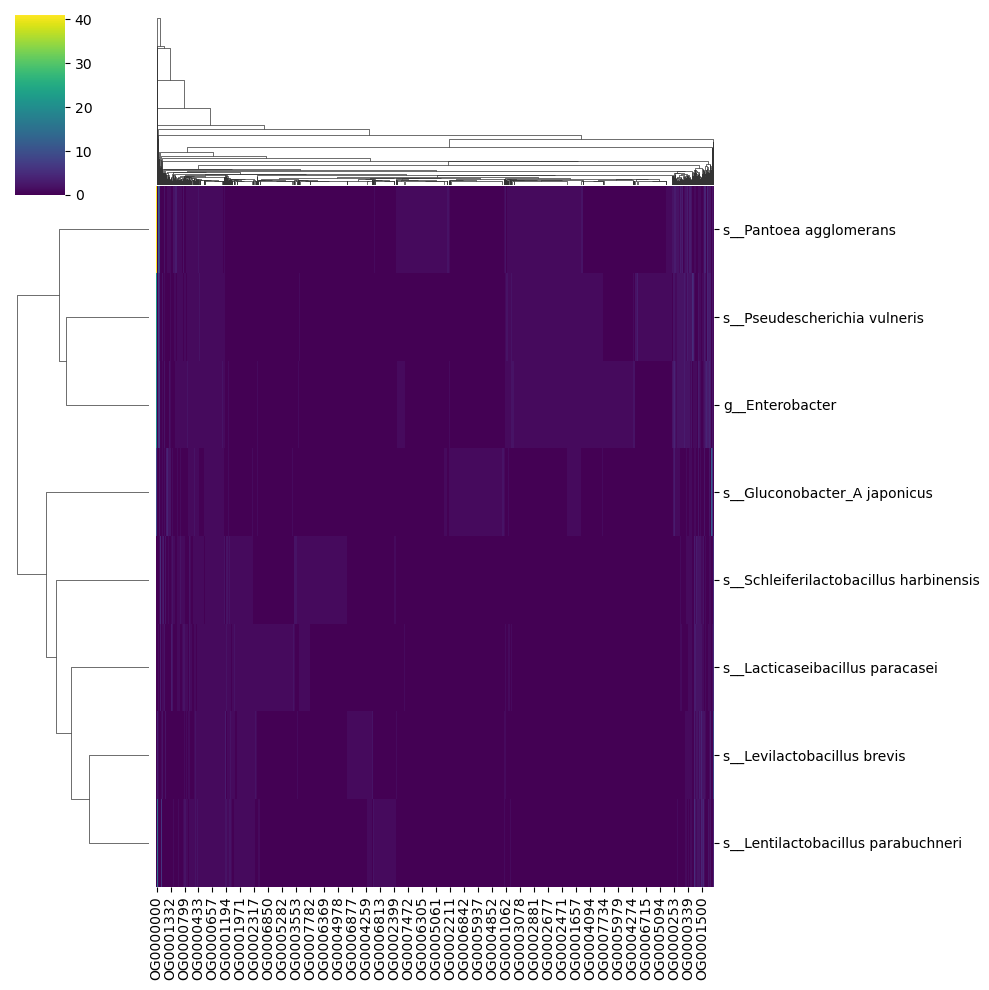

In [1338]:
functional_df = orthogroup_counts.rename(columns=mag2species).fillna(0).T

functional_dm = functional_distance_matrix(functional_df, metric="jaccard")

mantel_r, mantel_p, n = run_mantel_test(functional_dm, cooccurrence_dm)


# abundance_df = pd.read_csv("species_abundance.tsv", sep="\t", index_col=0)
# clr_df = clr_transform_abundance(abundance_df)


plot_niche_overlap_figure(cooccurrence_graph, functional_df, species_family_map,
                           mantel_r, mantel_p)

In [1335]:
functional_dm.shape

(7806, 7806)

In [925]:
['rea_map[rea_map['ec'].eq('EC-3.2.1.20')]['id'].unique()

array(['|RXN-14282|', '|RXN-15910|', '|RXN0-5183|', '|RXN-14283|',
       '|RXN-14281|', '|MALTODEXGLUCOSID-RXN|'], dtype=object)

In [920]:
rea_map

,id,name,altname,ec,kegg,pwy,enzymatic,gibbs,direction
0,|DEOXYNUCLEOTIDE-3-PHOSPHATASE-RXN|,NaN,NaN,EC-3.1.3.34,"R02751,R10770",NaN,True,-3.054138,>
1,|RXN-20295|,NaN,NaN,EC-1.14.15,NaN,PWY-8036,True,NaN,>
2,|RXN-11130|,NaN,NaN,EC-2.3.1,R11672,PWY-7577,True,-23.010010,>
3,|HYPONITRITE-REDUCTASE-RXN|,NaN,NaN,EC-1.7.1.5,"R00023,R10634",NaN,False,-17.956360,?
4,|RXN-19187|,NaN,NaN,EC-2.7.1.M16,NaN,PWY-7948,True,-19.808838,>
...,...,...,...,...,...,...,...,...,...
15764,|O-ACETYLHOMOSERINE-THIOL-LYASE-RXN|,NaN,NaN,EC-2.5.1.49,"R00651,R95634","PWY-7174,PWY-8132",True,-9.964119,>
15765,|RXN-14071|,NaN,NaN,NaN,R11850,PWY-7186,False,-111.060030,>
15766,|RXN-12229|,NaN,NaN,EC-2.4.1.275,"R05977,R96174",PWY-7841,True,-95.813480,>
15767,|RXN-7589|,NaN,NaN,EC-1.14.11,R12196,PWY-5036,True,-107.810000,>


In [935]:
reactions_for_species(gapseq_tables['s__Schleiferilactobacillus harbinensis'], ['GLYCOCAT-PWY'])

{}

In [936]:
pd.read_csv(gapseq_tables['s__Schleiferilactobacillus harbinensis']

'./../mag_pipeline/derep_mags/gapseq_test/HO2-3_MAG_04_protein-all-Pathways.tbl'

In [933]:
pway_name2id.loc['glycogen degradation I']

'|GLYCOCAT-PWY|'

In [924]:
all_pathway_data[all_pathway_data['ReactionsFound'].str.contains('MALTODEXGLUCOSID-RXN').fillna(False)]

,ID,Name,Prediction,Completeness,VagueReactions,KeyReactions,KeyReactionsFound,ReactionsFound,mag_id


# Tree

In [910]:
tree_table = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/de_novo_wf/gtdbtk.bac120.decorated.tree-table', sep='\t')

In [914]:
tree_table[tree_table['Taxon'].str.contains('HO')]

,Taxon,No. Expected in Tree,F-measure,Precision,Recall,No. Genomes from Taxon,No. Genome In Lineage,Rogue out,Rogue in
1624,g__CABHOJ01,1,1.0,1.0,1.0,1,1,NaN,NaN
1625,g__CABHON01,1,1.0,1.0,1.0,1,1,NaN,NaN
1639,g__CACHHO01,1,1.0,1.0,1.0,1,1,NaN,NaN
1806,g__CAJCHO01,1,1.0,1.0,1.0,1,1,NaN,NaN
2494,g__HIGHO2-12-38-15,2,1.0,1.0,1.0,2,2,NaN,NaN
2803,g__JABHOV01,1,1.0,1.0,1.0,1,1,NaN,NaN
2948,g__JADHOX01,3,1.0,1.0,1.0,3,3,NaN,NaN
2949,g__JADHOZ01,1,1.0,1.0,1.0,1,1,NaN,NaN
8526,s__CABHOJ01 sp902168195,1,1.0,1.0,1.0,1,1,NaN,NaN
8527,s__CABHON01 sp902168255,1,1.0,1.0,1.0,1,1,NaN,NaN


In [1430]:
interpro_plotdf, _, _ = clustermap_reorder(mag2interpro.T)

<Axes: xlabel='interpro_accession', ylabel='genome'>

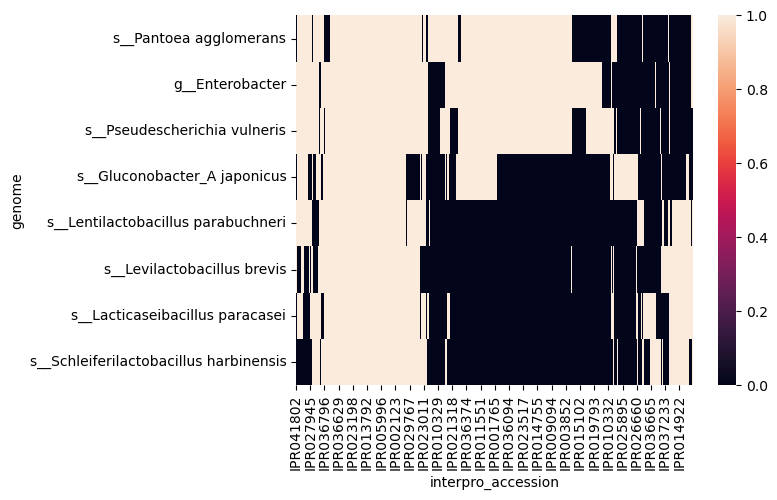

In [1431]:
sns.heatmap(interpro_plotdf)

In [1432]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                           g__Enterobacter
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

<Axes: xlabel='interpro_accession', ylabel='genome'>

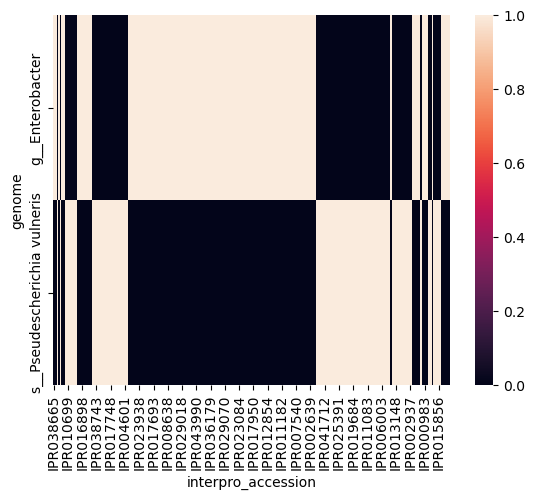

In [1441]:
temp = interpro_plotdf.loc[['g__Enterobacter', 's__Pseudescherichia vulneris'], :]
sns.heatmap(temp.loc[:, temp.sum().eq(1)])

In [1445]:
summarize_interpro()

' C-terminal'

In [1454]:
orthogroup_counts

,UO2-1_MAG_03,UO5-1_MAG_01,UO5-1_MAG_02,HI4-3_MAG_04,UO2-3_MAG_03,HO2-3_MAG_04,UO6-3_MAG_03,HO2-3_MAG_03
OG0000000,41.0,22.0,20.0,9.0,NaN,NaN,NaN,NaN
OG0000001,20.0,13.0,24.0,4.0,3.0,2.0,NaN,NaN
OG0000002,12.0,10.0,11.0,1.0,10.0,6.0,8.0,6.0
OG0000003,25.0,15.0,19.0,2.0,NaN,1.0,NaN,NaN
OG0000004,25.0,14.0,15.0,3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
OG0007801,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
OG0007802,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
OG0007803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
OG0007804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [1481]:
# # for cluster_id in [65]: # cluster_desc in cluster2desc.items():
# for og in get_unique_orthos(orthogroup_counts.rename(columns=mag2species), 'g__Enterobacter', 's__Pseudescherichia vulneris'):
# #     print(cluster_desc)
#     # get ortho groups of a cluster
#     # cluster_id = 65
#     # cluster_og_ids = og2cluster.loc[:, cluster_id].reindex(unique_orthos)
#     # cluster_og_ids[cluster_og_ids > 0]

#     # get all annotations of these interpro groups
#     interpros = og2interpro.loc[:, [og]].apply(lambda x: x[x > 0].index.to_series().unique(), axis=0) #.explode().unique()

#     # summarize descriptions
#     print(interpros.apply(lambda x: summarize_interpro(interpro2desc.loc[x].unique())).value_counts())

# Pathway diagrams

In [ ]:
for pathway_group in 